# Modelo de Expected Goals (xG)

**TFG:** Sistema de scouting de futbolistas basado en datos  
**Autor:** Mario Herranz Martínez — Grado en Ciencia de Datos, Universitat de València  
**Dataset:** Wyscout/Pappalardo et al. (2019), Nature Scientific Data  

---

#### **¿Qué son los Expected Goals?**

Los Expected Goals (xG), son una métrica estadística que mide la probabilidad de que un disparo se convierta en gol, evaluada a partir de las características de la ocasión en el instante inmediatamente anterior a la ejecución del disparo. A cada remate se le asigna un valor entre 0 y 1, donde 0 indica que es imposible anotar y 1 representa un gol garantizado.

La métrica se consolidó en el análisis deportivo profesional a partir de 2012 (Caley, 2014; Eastwood, 2014) y hoy es utilizada por prácticamente todos los departamentos de análisis de clubes profesionales, medios deportivos y proveedores de datos (StatsBomb, Opta, Wyscout).

#### **¿Qué información proporciona el xG en el fútbol?**

A nivel individual, el xG permite separar la **calidad de las ocasiones** que genera o recibe un jugador de la **calidad de su ejecución**. Un delantero cuya suma de goles reales supera su xG acumulado (*goals − xG > 0*) está superando la expectativa estadística de sus oportunidades, indicativo de una capacidad de finalización superior a la media. A nivel de equipo, el xG mide la calidad del juego ofensivo y defensivo de forma más estable que los goles reales, que están sujetos a alta varianza en muestras pequeñas.

#### **Principio fundamental: información PRE-tiro**

El xG evalúa la calidad de la **ocasión**, no la calidad de la **ejecución**. Esto impone una restricción metodológica estricta: toda información posterior al momento del disparo — resultado del remate, si fue bloqueado, si el portero lo detuvo — se excluye del modelo. Incluir información post-tiro produce un modelo de *post-shot xG* (PSxG), concepto diferente que no es objeto de este trabajo.

#### **Niveles de complejidad en modelos xG**

La literatura muestra una progresión en la sofisticación de los modelos, determinada por la riqueza de los datos disponibles:

| Nivel | Features | Ejemplo | AUC reportado |
|---|---|---|---|
| 1. Básico | Distancia + ángulo | Soccermatics (Sumpter, 2016) | 0.74–0.76 |
| 2. Event data | + body part, contexto previo, contraataque | Edd Webster; Dato Fútbol; Rowlinson (2020) | 0.77–0.80 |
| 3. Comercial | + posición del portero, freeze frames, nº defensores | StatsBomb; Wyscout comercial; Blumberg (2020) | 0.80–0.88 |

Debido a las características de la fuente de datos utilizada, este proyecto situa el modelo xG en el **Nivel 2**. Utilizamos el dataset público de Wyscout (Pappalardo et al., 2019), que proporciona eventos espacio-temporales sin freeze frames ni tracking data. El objetivo es maximizar la información extraíble de event data, incluyendo el contexto de la acción previa al tiro — enfoque que supera los modelos básicos de distancia + ángulo.

#### **Limitaciones inherentes del dataset**

El dataset público de Wyscout no incluye: posición del portero en el momento del tiro (disponible en StatsBomb freeze frames), número y posición de defensores entre tirador y portería, velocidad y trayectoria del balón, ni altura del impacto del tiro (*shot impact height*). Estas variables caracterizan los modelos de Nivel 3 y constituyen la frontera de mejora que distingue modelos académicos de modelos propietarios. Esta limitación se documenta y discute en las conclusiones.

#### **Conexión con el proyecto**

En el contexto de este TFG, el modelo xG no es un fin en sí mismo sino un componente del pipeline de scouting. Las probabilidades estimadas por tiro se agregan por jugador generando métricas derivadas — xG per90, *goals xG* (overperformance), xG por tiro — que alimentan directamente el clustering de estilos de juego y el motor de similitud entre jugadores (fases posteriores del proyecto).

#### **Estructura del notebook**

| Sección | Contenido |
|---|---|
| 1 | Setup y carga de datos |
| 2 | Definición del dataset de entrenamiento |
| 3 | Análisis de features candidatas: asociación bivariada con el target |
| 4 | Feature engineering: contexto del evento previo al tiro |
| 5 | Correlación entre features y selección final |
| 6 | Preparación del dataset: split, balance de clases y baseline |
| 7 | Baseline: Regresión Logística |
| 8 | Modelo completo: XGBoost |
| 9 a | Evaluación comparativa y validación entre ligas |
| 9 b | Validación externa contra StatsBomb |
| 10 | Interpretabilidad (SHAP) |
| 11 | Aplicación: xG por jugador |
| 12 | Conclusiones, limitaciones y conexión con fases posteriores |
| 13 | Guardado del modelo |

**Dataset:** ~40.000 tiros de open play, Big 5 ligas europeas 2017/18 (Pappalardo et al., 2019).  
**Referentes metodológicos:** Soccermatics (Sumpter, 2016), Dato Fútbol (Gómez, 2020), Edd Webster, Rowlinson (2020), Damavis (2025), Blumberg (2020).

## 1. Setup y carga de datos

Se carga el dataset completo de eventos desde la capa Silver de la base de datos PostgreSQL. Se necesitan **todos los eventos** (no solo tiros) porque las features Tier 2 requieren acceder al evento inmediatamente anterior a cada tiro dentro del mismo partido.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import warnings

from pathlib import Path
FIG_DIR = Path("figs_export"); FIG_DIR.mkdir(exist_ok=True)
def savefig(name): plt.savefig(FIG_DIR / f"03_{name}.png", dpi=200, bbox_inches="tight")

# Estadística
from scipy import stats
from scipy.stats import (
    pointbiserialr, mannwhitneyu, chi2_contingency,
    spearmanr
)

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    log_loss, roc_auc_score, brier_score_loss, roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_style('whitegrid')

# Conexión a PostgreSQL
load_dotenv()
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('PG_USER')}@{os.getenv('PG_HOST')}:{os.getenv('PG_PORT')}/{os.getenv('PG_DB')}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).scalar()
print("Conexión a PostgreSQL OK")

Conexión a PostgreSQL OK


### 1.2 Carga de eventos desde Silver

Se cargan todos los eventos de las Big 5 ligas, no solo tiros. Las features Tier 2 (sección 4) requieren acceder al evento inmediatamente anterior a cada tiro dentro del mismo partido, lo que exige un orden cronológico estricto.

El orden se establece por partido, periodo, segundo y wy_event_id. Las tres primeras columnas definen la cronología real — necesario porque `event_sec` en Wyscout se reinicia a 0 en cada `match_period` (1H, 2H, E1, E2). La cuarta columna (`wy_event_id`, clave primaria del evento) actúa como desempatador para eventos cronológicamente simultáneos: Wyscout codifica los duelos como dos registros paralelos (uno por jugador implicado) con la misma terna (match_id, match_period, event_sec). Sin un desempatador determinista, el orden de estos eventos varía entre ejecuciones y afecta al cálculo del evento previo.

In [2]:
# competition_id: 364=ENG, 795=ESP, 426=GER, 524=ITA, 412=FRA
# Excluidos: 28=Euro, 102=World Cup

BIG5_IDS = (364, 795, 426, 524, 412)

query_all = f"""
SELECT *
FROM silver.event_enriched
WHERE competition_id IN {BIG5_IDS}
ORDER BY match_id, match_period, event_sec, wy_event_id
"""

df_all = pd.read_sql(query_all, engine)

print(f"Eventos cargados (Big 5): {len(df_all):,}")
print(f"Partidos únicos: {df_all['match_id'].nunique():,}")
print(f"Competiciones: {df_all['competition_id'].nunique()}")
print(f"\nDistribución por tipo de evento:")
print(df_all['event_name'].value_counts().to_string())

Eventos cargados (Big 5): 3,071,395
Partidos únicos: 1,826
Competiciones: 5

Distribución por tipo de evento:
event_name
Pass                       1565356
Duel                        832055
Others on the ball          242837
Free Kick                   182468
Interruption                130096
Foul                         47955
Shot                         40461
Save attempt                 16567
Offside                       7821
Goalkeeper leaving line       5779


#### 1.3 Dataset de tiros (*open play*)

Tras el análisis exploratorio de datos, se decidió construir el modelo de *expected goals* (xG) únicamente sobre situaciones de *open play*, excluyendo aquellos eventos cuya dinámica y probabilidad de conversión difieren sustancialmente del juego abierto. Esta decisión sigue la metodología empleada en gran parte de la literatura y proyectos de referencia sobre modelado de xG.

Los criterios de exclusión fueron los siguientes:

1. **Penaltis**: presentan condiciones altamente estandarizadas, con distancia fija (11 metros), posición centrada y ausencia de presión defensiva directa durante el golpeo. Además, su tasa de conversión es significativamente superior al resto de tiros (~72.6%), lo que introduciría un sesgo importante en el modelo. Por este motivo, son excluidos en trabajos como *Soccermatics*, Dato Fútbol, Rowlinson, Edd Webster y Damavis.

2. **Faltas directas**: poseen una dinámica específica debido a la presencia de barrera defensiva y a la colocación previa del portero. Su tasa de conversión (~6.2%) también difiere notablemente de las situaciones de juego abierto, por lo que diversos autores como Dato Fútbol y Rowlinson recomiendan tratarlas de forma independiente.

3. **Autogoles**: no representan la calidad de la ocasión generada por el atacante, sino una acción defensiva involuntaria. Incluirlos introduciría ruido en la variable objetivo del modelo.

   
Por otro lado, los **tiros bloqueados sí fueron incluidos** en el dataset. Aunque el disparo no llegue a portería, el bloqueo es un evento que ocurre después de la decisión de tiro y, por tanto, constituye información *post-shot*. El objetivo del modelo xG es estimar la probabilidad de gol en función de la calidad de la ocasión previa al disparo, por lo que excluir los tiros bloqueados podría sesgar la representación real de las oportunidades generadas. Esta decisión también es respaldada explícitamente por Dato Fútbol.

In [3]:
# Filtrado 
mask_shots = (
    (df_all['event_name'] == 'Shot') &
    (~df_all['is_penalty_shot']) &
    (~df_all['is_free_kick_shot'])
)

df_shots = df_all[mask_shots].copy()

# Verificar y excluir autogoles
n_own_goals = df_shots['is_own_goal'].sum()
if n_own_goals > 0:
    df_shots = df_shots[~df_shots['is_own_goal']].copy()
    print(f"{n_own_goals} autogoles detectados y excluidos del dataset de tiros.")
else:
    print("No hay autogoles en los tiros de open play.")

# Variable target
df_shots['target'] = df_shots['is_goal'].astype(int)

# Resumen 
n = len(df_shots)
g = df_shots['target'].sum()
r = df_shots['target'].mean()

print(f"\n{'='*55}")
print(f"  DATASET DE TIROS PARA MODELO xG")
print(f"{'='*55}")
print(f"  Tiros totales:    {n:>8,}")
print(f"  Goles:            {g:>8,}  ({r:.1%})")
print(f"  No gol:           {n-g:>8,}  ({1-r:.1%})")
print(f"  Balance:          1:{(1-r)/r:.1f}  (gol vs no-gol)")
print(f"{'='*55}")
print(f"  Jugadores únicos: {df_shots['player_id'].nunique():>8,}")
print(f"  Partidos únicos:  {df_shots['match_id'].nunique():>8,}")
print(f"{'='*55}")

No hay autogoles en los tiros de open play.

  DATASET DE TIROS PARA MODELO xG
  Tiros totales:      40,461
  Goles:               4,271  (10.6%)
  No gol:             36,190  (89.4%)
  Balance:          1:8.5  (gol vs no-gol)
  Jugadores únicos:    2,114
  Partidos únicos:     1,826


#### 1.4 Verificación cruzada con hallazgos del EDA

Antes de proceder al entrenamiento del modelo, se realizó una verificación cruzada entre el dataset de tiros generado y los resultados obtenidos previamente en el notebook `02_eda_events.ipynb` (sección 5). El objetivo de esta comprobación es garantizar la consistencia y reproducibilidad del pipeline analítico entre notebooks.

En concreto, se validó que el número de penaltis, faltas directas, autogoles y tiros de *open play* coincidiera con los valores reportados durante el análisis exploratorio. Esta práctica permite detectar posibles discrepancias derivadas de filtros incorrectos, cambios en el preprocesamiento o errores en la extracción de eventos.

La consistencia entre ambos notebooks asegura que el conjunto de datos utilizado para entrenar el modelo xG corresponde exactamente a los criterios metodológicos definidos durante el EDA, reforzando la trazabilidad y fiabilidad del análisis.

In [4]:
# Conteo de exclusiones
n_penalties = df_all[
    (df_all['event_name'] == 'Free Kick') &
    (df_all['sub_event_name'] == 'Penalty')
].shape[0]

# Las faltas directas en Wyscout aparecen como event_name='Free Kick', sub_event_name='Free kick shot'
n_free_kicks = df_all[
    (df_all['event_name'] == 'Free Kick') &
    (df_all['sub_event_name'] == 'Free kick shot')
].shape[0]

n_all_shots = df_all[df_all['event_name'] == 'Shot'].shape[0]

print("Verificación cruzada con EDA (sección 5):")
print(f"  Tiros totales (event_name='Shot'):  {n_all_shots:,}")
print(f"  Penaltis excluidos:                 {n_penalties:,}")
print(f"  Faltas directas excluidas:          {n_free_kicks:,}")
print(f"  Dataset final (open play):          {len(df_shots):,}")
print(f"\n Valores esperados del EDA: ~40.461 tiros, ~4.271 goles")

Verificación cruzada con EDA (sección 5):
  Tiros totales (event_name='Shot'):  40,461
  Penaltis excluidos:                 541
  Faltas directas excluidas:          2,038
  Dataset final (open play):          40,461

 Valores esperados del EDA: ~40.461 tiros, ~4.271 goles


#### Resumen de la carga de datos

El dataset de entrenamiento contiene **~40.461 tiros de open play** con una tasa de conversión del **~10.6%** (balance de clases ~1:8.5). 

El desbalance de clases 1:8.5 es inherente al fútbol, la gran mayoría de los tiros no terminan en gol. **No se corregirá mediante oversampling** porque el xG debe reflejar la tasa base real de conversión; inflar artificialmente la clase positiva produce probabilidades mal calibradas. La estrategia de gestión del desbalance se detalla en la sección 6.

Se han cargado **todos los eventos del partido** (no solo tiros) porque las features Tier 2 (sección 4) requieren acceso al evento inmediatamente anterior a cada tiro.

## 2. Definición del dataset de entrenamiento

Antes de modelar, formalizamos los criterios de inclusión y exclusión del dataset y verificamos la distribución de las features disponibles. Esta sección documenta las decisiones que determinan el alcance del modelo.

#### 2.1 Estructura del dataset de tiros

In [5]:
# Features disponibles directamente (Tier 1)
tier1_continuous = ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match']
tier1_binary = ['is_counterattack', 'is_opportunity', 'is_first_half']
tier1_categorical = ['body_part']

print("FEATURES TIER 1 — Disponibles en Silver")
print("="*55)

# Continuas
print("\n── Continuas ──")
print(df_shots[tier1_continuous].describe().round(2).to_string())

# Binarias
print("\n── Binarias ──")
for col in tier1_binary:
    n_true = df_shots[col].sum()
    pct = n_true / len(df_shots)
    print(f"  {col:25s}  {n_true:>6,} ({pct:5.1%})")

# Categórica
print("\n── Categórica: body_part ──")
print(df_shots['body_part'].value_counts().to_string())

# Missings
print("\n── Valores nulos ──")
cols_check = tier1_continuous + tier1_binary + tier1_categorical
nulls = df_shots[cols_check].isnull().sum()
if nulls.sum() == 0:
    print("Sin valores nulos en features Tier 1")
else:
    print(nulls[nulls > 0].to_string())

FEATURES TIER 1 — Disponibles en Silver

── Continuas ──
       dist_to_goal_m  angle_to_goal_deg  minute_match
count        40461.00           40461.00      40461.00
mean            18.53              23.79         48.19
std              8.39              14.58         26.51
min              0.68               0.00          0.00
25%             12.25              14.41         26.00
50%             17.12              18.82         48.00
75%             24.90              28.99         71.00
max            103.95             180.00        103.00

── Binarias ──
  is_counterattack            2,251 ( 5.6%)
  is_opportunity             28,603 (70.7%)
  is_first_half              18,739 (46.3%)

── Categórica: body_part ──
body_part
right        20619
left         13323
head_body     6519

── Valores nulos ──
Sin valores nulos en features Tier 1


#### 2.2 Justificación cuantitativa de las exclusiones

Con el objetivo de respaldar empíricamente los criterios de exclusión definidos en la sección anterior, se compararon las tasas de conversión a gol entre distintos tipos de tiro: *open play*, penaltis y faltas directas.

La visualización muestra diferencias sustanciales entre categorías. Los penaltis presentan una probabilidad de conversión muy superior al resto de situaciones (~72.6%), debido a sus condiciones altamente controladas y repetibles. En contraste, las faltas directas registran una tasa de conversión considerablemente menor (~6.2%), condicionada por factores específicos como la barrera defensiva y el posicionamiento previo del portero.

Estas diferencias evidencian que ambos tipos de acciones siguen distribuciones distintas respecto a los tiros de juego abierto (*open play*), por lo que su inclusión podría sesgar el aprendizaje del modelo xG y reducir su capacidad para estimar correctamente la calidad de ocasiones generadas en contextos normales de juego.

Por este motivo, el modelo se entrena exclusivamente sobre tiros de *open play*, siguiendo la práctica habitual en la literatura y en múltiples implementaciones de referencia de modelos xG.

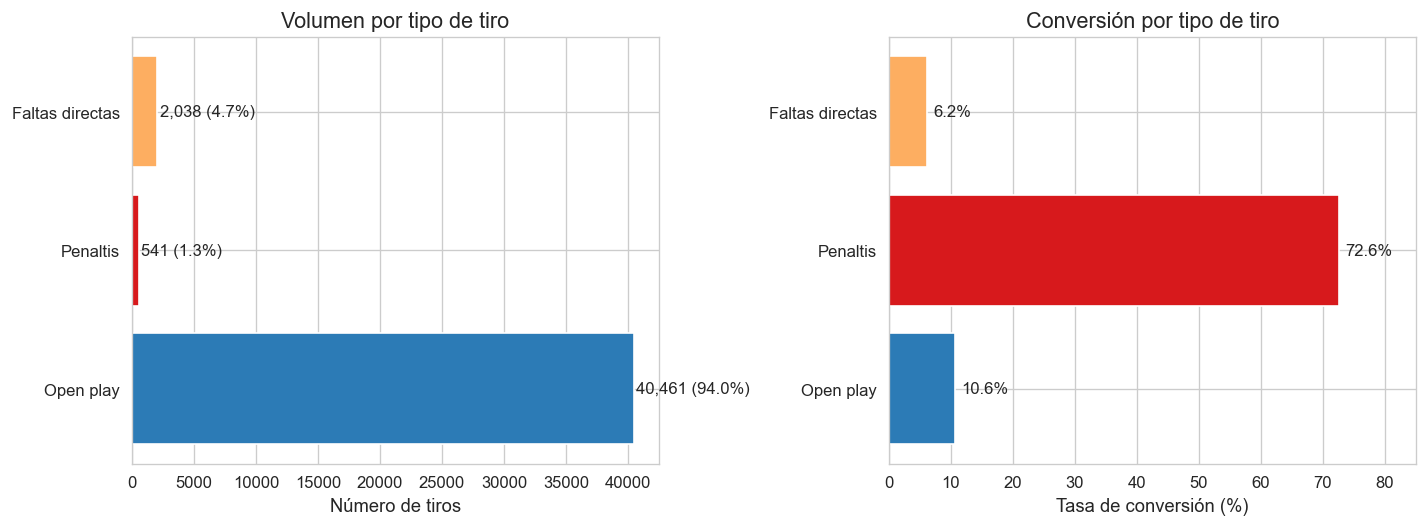

           Tipo  Tiros  Goles  Conversión (%)  % del total
      Open play  40461   4271            10.6         94.0
       Penaltis    541    393            72.6          1.3
Faltas directas   2038    126             6.2          4.7


In [6]:
# Recoger los tres grupos desde df_all
penalties = df_all[
    (df_all['event_name'] == 'Free Kick') &
    (df_all['sub_event_name'] == 'Penalty')
]
free_kicks = df_all[
    (df_all['event_name'] == 'Free Kick') &
    (df_all['sub_event_name'] == 'Free kick shot')
]

groups = pd.DataFrame({
    'Tipo': ['Open play', 'Penaltis', 'Faltas directas'],
    'Tiros': [len(df_shots), len(penalties), len(free_kicks)],
    'Goles': [
        df_shots['target'].sum(),
        penalties['is_goal'].sum(),
        free_kicks['is_goal'].sum()
    ]
})
groups['Conversión (%)'] = (groups['Goles'] / groups['Tiros'] * 100).round(1)
groups['% del total'] = (groups['Tiros'] / groups['Tiros'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel izquierdo: volumen
axes[0].barh(groups['Tipo'], groups['Tiros'], color=['#2c7bb6', '#d7191c', '#fdae61'])
axes[0].set_xlabel('Número de tiros')
axes[0].set_title('Volumen por tipo de tiro')
for i, (v, pct) in enumerate(zip(groups['Tiros'], groups['% del total'])):
    axes[0].text(v + 200, i, f'{v:,} ({pct}%)', va='center', fontsize=10)

# Panel derecho: conversión
bars = axes[1].barh(groups['Tipo'], groups['Conversión (%)'],
                     color=['#2c7bb6', '#d7191c', '#fdae61'])
axes[1].set_xlabel('Tasa de conversión (%)')
axes[1].set_title('Conversión por tipo de tiro')
axes[1].set_xlim(0, 85)
for i, v in enumerate(groups['Conversión (%)']):
    axes[1].text(v + 1, i, f'{v}%', va='center', fontsize=10)
    
plt.tight_layout()
savefig("shot_types_conversion")
plt.show()

print(groups.to_string(index=False))

#### 2.3 Tasa de conversión por liga

A continuación, se analiza la tasa de conversión de tiros por competición con el objetivo de evaluar posibles diferencias estructurales entre ligas. Esta comprobación permite validar uno de los supuestos metodológicos del modelo: entrenar un único modelo xG conjunto utilizando datos agregados de las cinco grandes ligas europeas (*Big 5*).

Los resultados muestran que, aunque existen ligeras variaciones entre competiciones, las diferencias observadas son relativamente reducidas en comparación con la variabilidad interna del propio juego. En otras palabras, las ligas comparten patrones de conversión suficientemente similares como para considerar que pertenecen a una misma distribución futbolística de referencia.

Este hallazgo coincide con lo observado previamente en el EDA (sección 8), donde se concluyó que las diferencias entre ligas son de segundo orden frente al efecto de variables espaciales y contextuales como la distancia, el ángulo de tiro o el tipo de asistencia.

Por tanto, entrenar el modelo sobre el conjunto agregado de las *Big 5* aporta dos ventajas principales:

- Incrementar el tamaño muestral y la robustez estadística del modelo.
- Mejorar la capacidad de generalización al exponer el algoritmo a una mayor diversidad de situaciones de juego.

En consecuencia, no se consideró necesario entrenar modelos independientes por competición.

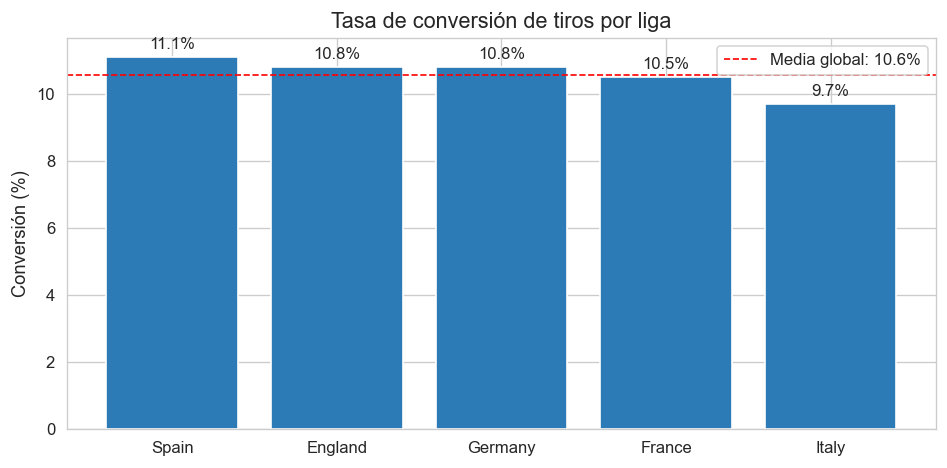

         tiros  goles  dist_media  angulo_medio  conversion
league                                                     
Spain     7979    884   18.192863     23.940672        11.1
England   8451    914   18.283363     24.299698        10.8
Germany   6898    747   18.228213     24.154140        10.8
France    8327    873   18.945470     23.529317        10.5
Italy     8806    853   18.935980     23.144186         9.7


In [7]:
LEAGUE_NAMES = {364: 'England', 795: 'Spain', 426: 'Germany', 524: 'Italy', 412: 'France'}

league_stats = (
    df_shots
    .assign(league=df_shots['competition_id'].map(LEAGUE_NAMES))
    .groupby('league')
    .agg(
        tiros=('target', 'count'),
        goles=('target', 'sum'),
        dist_media=('dist_to_goal_m', 'mean'),
        angulo_medio=('angle_to_goal_deg', 'mean')
    )
    .assign(conversion=lambda x: (x['goles'] / x['tiros'] * 100).round(1))
    .sort_values('conversion', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(league_stats.index, league_stats['conversion'],
              color='#2c7bb6', edgecolor='white')
ax.axhline(y=df_shots['target'].mean() * 100, color='red',
           linestyle='--', linewidth=1, label=f'Media global: {df_shots["target"].mean()*100:.1f}%')
ax.set_ylabel('Conversión (%)')
ax.set_title('Tasa de conversión de tiros por liga')
ax.legend()

for bar, val in zip(bars, league_stats['conversion']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(league_stats.to_string())

### Decisiones del dataset de entrenamiento

El modelo de *expected goals* (xG) se entrenó exclusivamente sobre tiros de *open play*, excluyendo aquellas acciones cuya dinámica difiere estructuralmente del juego abierto. Los criterios aplicados fueron los siguientes:

Las diferencias observadas entre competiciones fueron reducidas. La tasa de conversión osciló entre el 9.7% (Serie A) y el 11.1% (La Liga), mientras que la distancia media al gol se mantuvo estable entre 18.2 y 18.9 metros. Estos resultados justifican el entrenamiento de un único modelo conjunto sobre las cinco grandes ligas europeas, maximizando el tamaño muestral y la capacidad de generalización. 

Los valores extremos tampoco fueron eliminados. La distancia máxima registrada (103.95m) corresponde a situaciones reales de partido y el modelo debe ser capaz de asignar probabilidades de gol cercanas a cero a este tipo de eventos.

El dataset final utilizado para el entrenamiento está compuesto por **40.461 tiros de *open play*** correspondientes a las cinco grandes ligas europeas de la temporada 2017/18, de los cuales **4.271 terminaron en gol** (10.6% de conversión).

## 3. Análisis de features candidatas

Antes de construir el modelo de *expected goals* (xG), se evalúa la relación entre cada feature candidata y la variable objetivo (`is_goal`). Este análisis tiene tres objetivos principales:

1. Identificar qué variables presentan mayor capacidad explicativa sobre la probabilidad de gol.
2. Detectar features con escasa relevancia estadística o práctica, evitando introducir ruido en el modelo.
3. Justificar las decisiones de inclusión o exclusión mediante evidencia cuantitativa y conocimiento de dominio futbolístico.

### Metodología estadística

La elección del test estadístico depende del tipo de variable analizada y de su relación con la variable objetivo, que en este caso es binaria (gol / no gol).

| Tipo de feature | Test de asociación | Tamaño del efecto | Justificación |
|---|---|---|---|
| Continua vs binaria | Correlación punto-biserial (*r<sub>pb</sub>*) | *r<sub>pb</sub>* | Equivalente a la correlación de Pearson cuando una variable es binaria. |
| Continua vs binaria | Mann–Whitney U | Correlación rank-biserial (*r*) | Alternativa no paramétrica que no asume normalidad. |
| Binaria vs binaria | Test χ² de independencia | Cramér's V | Adecuado para tablas de contingencia 2×2. |
| Categórica vs binaria | Test χ² de independencia | Cramér's V | Extensión del caso anterior para variables categóricas con múltiples niveles. |

Además del contraste de hipótesis, se calcula el tamaño del efecto asociado a cada test con el objetivo de medir la magnitud real de la relación observada.

### Consideraciones sobre el tamaño muestral

Dado el tamaño del dataset (N = 40.461 tiros), incluso asociaciones muy pequeñas pueden resultar estadísticamente significativas \(p < 0.001)\. Por este motivo, la selección de variables no se basa únicamente en el p-valor, sino principalmente en el tamaño del efecto y en la interpretabilidad futbolística de cada feature.

Por ejemplo, una variable puede presentar un resultado estadísticamente significativo pero mantener un tamaño del efecto prácticamente nulo, indicando una relación irrelevante desde el punto de vista predictivo.

#### 3.1 Funciones auxiliares para análisis bivariado

A continuación, se definen las funciones auxiliares utilizadas para evaluar la asociación entre cada feature candidata y la variable objetivo (`is_goal`). Estas funciones automatizan el cálculo de tests estadísticos, tamaños del efecto y estadísticas descriptivas según el tipo de variable analizada (continua, binaria o categórica).

In [8]:
def test_continuous_vs_target(df, feature, target='target'):
    """
    Evalúa la asociación entre una feature continua y el target binario.
    Retorna: point-biserial r, Mann-Whitney U, rank-biserial r, p-valores,
             y estadísticos descriptivos por grupo.
    """
    group_0 = df.loc[df[target] == 0, feature].dropna()
    group_1 = df.loc[df[target] == 1, feature].dropna()
    
    # Correlación punto-biserial
    r_pb, p_pb = pointbiserialr(df[target], df[feature])
    
    # Mann-Whitney U (no paramétrico)
    u_stat, p_mw = mannwhitneyu(group_0, group_1, alternative='two-sided')
    
    # Rank-biserial correlation como tamaño del efecto de Mann-Whitney
    n0, n1 = len(group_0), len(group_1)
    r_rb = 1 - (2 * u_stat) / (n0 * n1)
    
    return {
        'feature': feature,
        'type': 'continuous',
        'mean_no_goal': group_0.mean(),
        'mean_goal': group_1.mean(),
        'median_no_goal': group_0.median(),
        'median_goal': group_1.median(),
        'r_pointbiserial': r_pb,
        'p_pointbiserial': p_pb,
        'U_statistic': u_stat,
        'p_mannwhitney': p_mw,
        'r_rankbiserial': r_rb,
        'n': len(df)
    }


def test_binary_vs_target(df, feature, target='target'):
    """
    Evalúa la asociación entre una feature binaria y el target binario.
    Retorna: χ², p-valor, Cramér's V, tasas de conversión condicionales.
    """
    ct = pd.crosstab(df[feature], df[target])
    chi2, p_chi2, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / n)  # Para tabla 2×2: V = sqrt(chi²/n)
    
    # Tasas de conversión condicionales
    conv_false = ct.loc[False, 1] / ct.loc[False].sum() if False in ct.index else np.nan
    conv_true = ct.loc[True, 1] / ct.loc[True].sum() if True in ct.index else np.nan
    
    return {
        'feature': feature,
        'type': 'binary',
        'conv_false': conv_false,
        'conv_true': conv_true,
        'diff_pp': (conv_true - conv_false) * 100 if not np.isnan(conv_true) else np.nan,
        'chi2': chi2,
        'p_chi2': p_chi2,
        'cramers_v': cramers_v,
        'n_true': df[feature].sum(),
        'pct_true': df[feature].mean(),
        'n': len(df)
    }


def test_categorical_vs_target(df, feature, target='target'):
    """
    Evalúa la asociación entre una feature categórica (>2 niveles) y el target binario.
    Retorna: χ², p-valor, Cramér's V, tasas de conversión por nivel.
    """
    ct = pd.crosstab(df[feature], df[target])
    chi2, p_chi2, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else np.sqrt(chi2 / n)
    
    # Conversión por nivel
    conv_by_level = (ct[1] / ct.sum(axis=1) * 100).round(2)
    
    return {
        'feature': feature,
        'type': 'categorical',
        'chi2': chi2,
        'p_chi2': p_chi2,
        'dof': dof,
        'cramers_v': cramers_v,
        'conv_by_level': conv_by_level.to_dict(),
        'n': len(df)
    }


print("Funciones de test definidas")

Funciones de test definidas


#### 3.2 Features continuas frente a la variable objetivo

En esta sección se analiza la relación entre las variables continuas candidatas y la probabilidad de gol (`is_goal`). Para cada feature se comparan las distribuciones entre tiros que terminaron en gol y tiros fallados, utilizando tanto medidas descriptivas (media y mediana) como métricas de asociación estadística.

Además de la correlación punto-biserial, se emplea el test no paramétrico de Mann–Whitney U junto con su tamaño del efecto (*rank-biserial correlation*), permitiendo evaluar diferencias entre grupos sin asumir normalidad en las distribuciones.

In [9]:
continuous_features = ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match']

results_cont = []
for feat in continuous_features:
    res = test_continuous_vs_target(df_shots, feat)
    results_cont.append(res)
    
    print(f"\n{'='*60}")
    print(f"  {feat}")
    print(f"{'='*60}")
    print(f"  Media (no gol): {res['mean_no_goal']:.2f}")
    print(f"  Media (gol):    {res['mean_goal']:.2f}")
    print(f"  Mediana (no gol): {res['median_no_goal']:.2f}")
    print(f"  Mediana (gol):    {res['median_goal']:.2f}")
    print(f"  ──────────────────────────────────────")
    print(f"  r punto-biserial:   {res['r_pointbiserial']:+.4f}  (p = {res['p_pointbiserial']:.2e})")
    print(f"  r rank-biserial:    {res['r_rankbiserial']:+.4f}  (Mann-Whitney p = {res['p_mannwhitney']:.2e})")


  dist_to_goal_m
  Media (no gol): 19.28
  Media (gol):    12.24
  Mediana (no gol): 17.93
  Mediana (gol):    11.53
  ──────────────────────────────────────
  r punto-biserial:   -0.2576  (p = 0.00e+00)
  r rank-biserial:    -0.5179  (Mann-Whitney p = 0.00e+00)

  angle_to_goal_deg
  Media (no gol): 22.13
  Media (gol):    37.92
  Mediana (no gol): 17.97
  Mediana (gol):    31.67
  ──────────────────────────────────────
  r punto-biserial:   +0.3328  (p = 0.00e+00)
  r rank-biserial:    +0.5087  (Mann-Whitney p = 0.00e+00)

  minute_match
  Media (no gol): 48.06
  Media (gol):    49.33
  Mediana (no gol): 48.00
  Mediana (gol):    51.00
  ──────────────────────────────────────
  r punto-biserial:   +0.0147  (p = 3.14e-03)
  r rank-biserial:    +0.0281  (Mann-Whitney p = 2.64e-03)


#### 3.3 Distribución de features continuas: gol vs no gol

Para complementar el análisis estadístico anterior, se visualiza la distribución de cada variable continua diferenciando entre tiros que terminaron en gol y tiros fallados. Las curvas de densidad (*Kernel Density Estimation*, KDE) permiten observar el grado de separación entre ambas distribuciones y evaluar visualmente la capacidad discriminativa de cada feature.

Se muestran las medianas de cada grupo y el coeficiente de correlación punto-biserial (*r<sub>pb</sub>*), facilitando la interpretación conjunta de la relación estadística y del comportamiento real de las distribuciones.

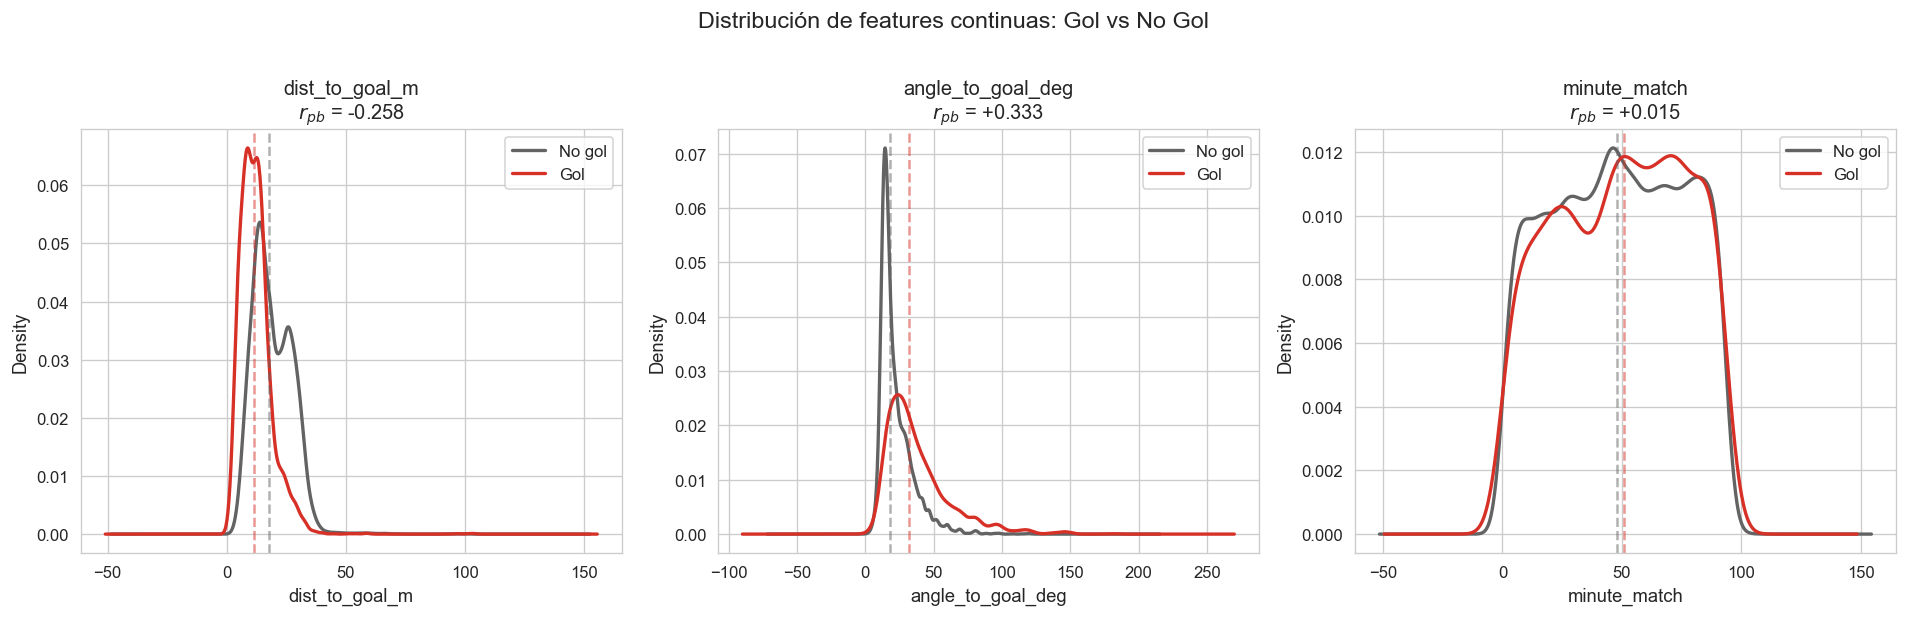

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat, res in zip(axes, continuous_features, results_cont):
    # KDE por grupo
    for val, color, label in [(0, '#636363', 'No gol'), (1, '#d73027', 'Gol')]:
        subset = df_shots.loc[df_shots['target'] == val, feat]
        subset.plot.kde(ax=ax, color=color, label=label, linewidth=2)
    
    ax.set_title(f'{feat}\n$r_{{pb}}$ = {res["r_pointbiserial"]:+.3f}', fontsize=12)
    ax.set_xlabel(feat)
    ax.legend()
    
    # Líneas de mediana
    ax.axvline(res['median_no_goal'], color='#636363', linestyle='--', alpha=0.5)
    ax.axvline(res['median_goal'], color='#d73027', linestyle='--', alpha=0.5)

plt.suptitle('Distribución de features continuas: Gol vs No Gol', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 3.4 Tasa de conversión empírica por intervalos

Se analiza la relación funcional entre las principales variables espaciales del tiro y la probabilidad empírica de gol. Para ello, se agrupan los tiros en intervalos de distancia y ángulo, calculando la tasa de conversión observada en cada tramo.

Esta visualización permite comprobar si las features continuas presentan un comportamiento coherente con el conocimiento futbolístico: se espera que la probabilidad de gol disminuya a medida que aumenta la distancia al gol y que aumente cuando el ángulo visible de portería es mayor.

Únicamente se muestran intervalos con al menos 50 tiros, con el fin de evitar interpretaciones basadas en grupos demasiado pequeños o poco estables.

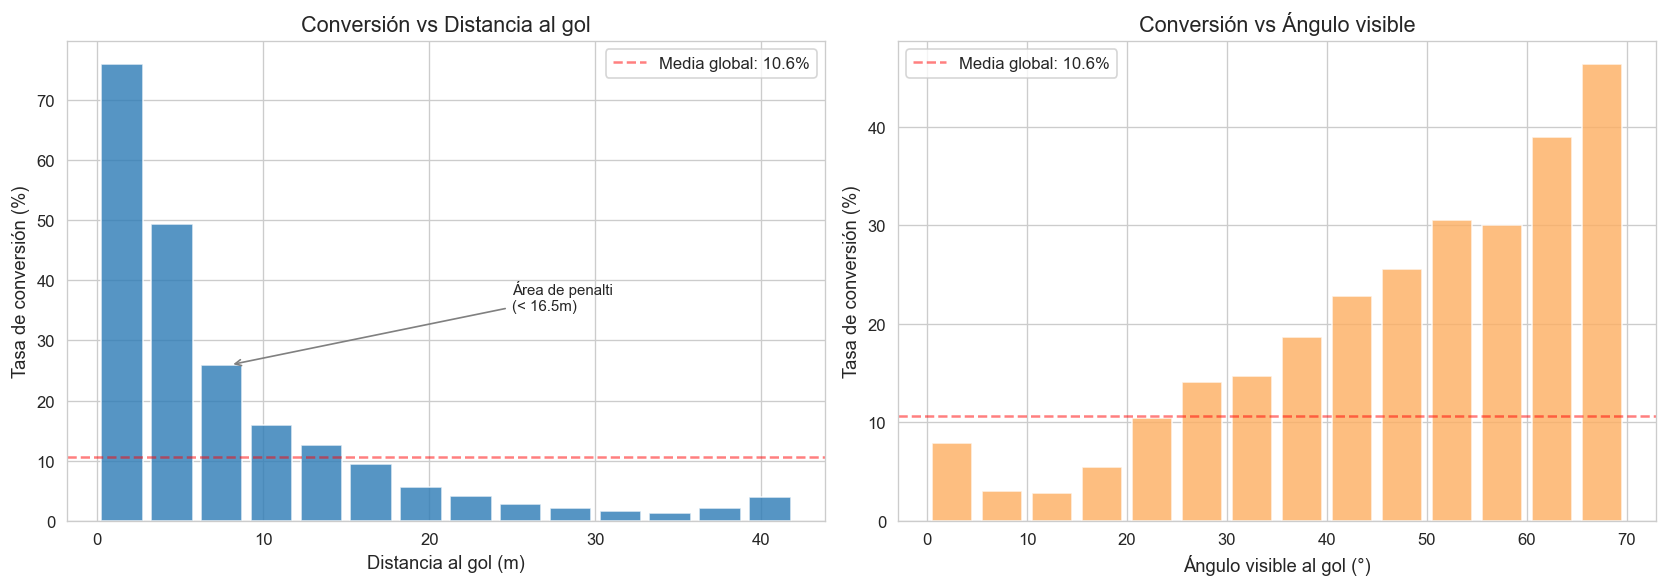

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distancia
bins_dist = np.arange(0, 55, 3)
df_shots['dist_bin'] = pd.cut(df_shots['dist_to_goal_m'], bins=bins_dist)
conv_dist = df_shots.groupby('dist_bin', observed=True).agg(
    tiros=('target', 'count'),
    goles=('target', 'sum')
)
conv_dist['conversion'] = conv_dist['goles'] / conv_dist['tiros'] * 100
conv_dist['mid'] = [interval.mid for interval in conv_dist.index]

# Solo bins con >= 50 tiros para estabilidad estadística
mask_dist = conv_dist['tiros'] >= 50

axes[0].bar(conv_dist.loc[mask_dist, 'mid'], conv_dist.loc[mask_dist, 'conversion'],
            width=2.5, color='#2c7bb6', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Distancia al gol (m)')
axes[0].set_ylabel('Tasa de conversión (%)')
axes[0].set_title('Conversión vs Distancia al gol')
axes[0].axhline(y=10.6, color='red', linestyle='--', alpha=0.5, label='Media global: 10.6%')
axes[0].legend()

# Anotación de la zona clave
axes[0].annotate('Área de penalti\n(< 16.5m)',
                 xy=(8, conv_dist.loc[mask_dist, 'conversion'].iloc[2]),
                 xytext=(25, 35), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='gray'))

# Ángulo
bins_angle = np.arange(0, 75, 5)
df_shots['angle_bin'] = pd.cut(df_shots['angle_to_goal_deg'], bins=bins_angle)
conv_angle = df_shots.groupby('angle_bin', observed=True).agg(
    tiros=('target', 'count'),
    goles=('target', 'sum')
)
conv_angle['conversion'] = conv_angle['goles'] / conv_angle['tiros'] * 100
conv_angle['mid'] = [interval.mid for interval in conv_angle.index]
mask_angle = conv_angle['tiros'] >= 50

axes[1].bar(conv_angle.loc[mask_angle, 'mid'], conv_angle.loc[mask_angle, 'conversion'],
            width=4, color='#fdae61', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Ángulo visible al gol (°)')
axes[1].set_ylabel('Tasa de conversión (%)')
axes[1].set_title('Conversión vs Ángulo visible')
axes[1].axhline(y=10.6, color='red', linestyle='--', alpha=0.5, label='Media global: 10.6%')
axes[1].legend()

savefig("conversion_dist_angle")
plt.tight_layout()
plt.show()

# Limpiar columnas temporales
df_shots.drop(columns=['dist_bin', 'angle_bin'], inplace=True)

### Interpretación de las features continuas

#### `angle_to_goal_deg` (*r<sub>pb</sub>*) = +0.333, efecto medio

El ángulo visible de portería es la feature con mayor asociación bivariada respecto a la variable objetivo. Los tiros que terminan en gol presentan un ángulo mediano de 31.67°, frente a 17.97° en los tiros fallados, indicando que las ocasiones convertidas suelen producirse desde posiciones más centradas y con mayor superficie visible de portería.

La curva de conversión muestra una relación claramente creciente: los tiros con ángulos inferiores a 15° presentan tasas de conversión cercanas al 5%, mientras que en posiciones superiores a 50° la conversión supera el 30%.

Desde el punto de vista futbolístico, esta variable captura la componente lateral de la posición del tirador. Los disparos ejecutados desde zonas centradas ofrecen una mayor amplitud de remate y reducen la ventaja posicional del portero, mientras que los tiros desde posiciones escoradas limitan considerablemente las opciones de finalización.

#### `dist_to_goal_m` (*r<sub>pb</sub>*) = -0.258, efecto pequeño-medio

La distancia al gol es la segunda variable con mayor capacidad discriminativa. Los goles se producen desde una mediana de 11.53 metros, frente a 17.93 metros en los tiros no convertidos.

La relación observada reproduce el patrón clásico descrito en la literatura de modelos xG: la probabilidad de gol disminuye progresivamente a medida que aumenta la distancia al gol. Las tasas de conversión pasan de valores superiores al 70% en disparos muy cercanos a portería a porcentajes inferiores al 5% a partir de los 20 metros.

Futbolísticamente, la distancia actúa como un indicador compuesto de dificultad técnica y temporal: los tiros lejanos requieren mayor precisión y potencia, al tiempo que permiten más tiempo de reacción al portero y aumentan la probabilidad de intervención defensiva.

#### `minute_match` (*r<sub>pb</sub>*) = +0.015, efecto trivial

El minuto de partido presenta una asociación prácticamente nula con la probabilidad de gol. Las diferencias entre goles y no goles son mínimas tanto en términos de media como de distribución, y las curvas KDE resultan prácticamente indistinguibles.

Aunque podrían esperarse efectos asociados a la fatiga o al incremento del riesgo táctico en los minutos finales, estos factores parecen compensarse con otros elementos contextuales, como ataques más precipitados o situaciones defensivas más cerradas.

Dado su bajo coste computacional, la variable se mantiene inicialmente como feature candidata, aunque no se espera una contribución predictiva relevante. Su impacto final será reevaluado posteriormente mediante análisis SHAP.

#### 3.5 Mapa espacial de tiros

Además del análisis estadístico de las features individuales, resulta útil visualizar espacialmente la distribución de los tiros sobre el terreno de juego. Este tipo de representación permite identificar patrones posicionales asociados a la probabilidad de gol y comprobar visualmente la coherencia futbolística del dataset.

En el gráfico se representan todos los tiros de *open play*, diferenciando entre tiros fallados y goles. El tamaño de los goles es proporcional al ángulo visible de portería, permitiendo observar conjuntamente el efecto espacial de la distancia y el ángulo sobre la probabilidad de conversión.

Asimismo, se verifica la existencia de tiros ejecutados desde campo propio, confirmando que el dataset conserva situaciones extremas reales de partido en lugar de eliminarlas artificialmente.

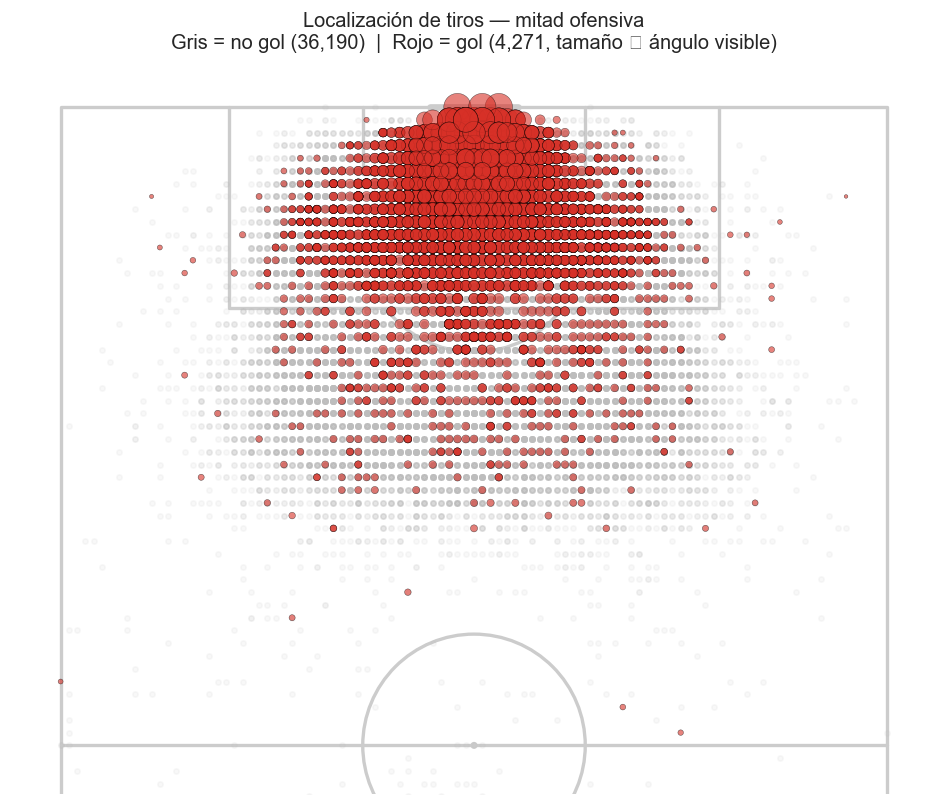

Tiros desde mitad propia: 91 (0.22%)
  → Goles desde mitad propia: 4


In [12]:
from mplsoccer import VerticalPitch

pitch = VerticalPitch(
    pitch_type='custom', pitch_length=105, pitch_width=68,
    half=True, pitch_color='white', line_color='#cccccc'
)

fig, ax = pitch.draw(figsize=(8, 10))

# No goles (fondo, gris transparente)
no_goals = df_shots[df_shots['target'] == 0]
goals = df_shots[df_shots['target'] == 1]

pitch.scatter(
    no_goals['x_m'], no_goals['y_m'], ax=ax,
    s=10, color='#bdbdbd', alpha=0.1, zorder=1
)

# Goles (rojo, tamaño proporcional al ángulo visible)
pitch.scatter(
    goals['x_m'], goals['y_m'], ax=ax,
    s=goals['angle_to_goal_deg'] * 1.5,
    color='#d73027', alpha=0.6,
    edgecolors='black', linewidth=0.3, zorder=2
)

ax.set_title(
    f'Localización de tiros — mitad ofensiva\n'
    f'Gris = no gol ({len(no_goals):,})  |  '
    f'Rojo = gol ({len(goals):,}, tamaño ∝ ángulo visible)',
    fontsize=12
)

savefig("shot_map")
plt.tight_layout()
plt.show()

# Confirmar los tiros desde campo propio
n_own_half = (df_shots['x_m'] < 52.5).sum()
print(f"Tiros desde mitad propia: {n_own_half} ({n_own_half/len(df_shots):.2%})")
print(f"  → Goles desde mitad propia: {df_shots.loc[df_shots['x_m'] < 52.5, 'target'].sum()}")

#### 3.6 Features binarias frente a la variable objetivo

En esta sección se analiza la relación entre distintas variables binarias de contexto y la probabilidad de gol (`is_goal`). Para cada feature se comparan las tasas de conversión condicionadas a la presencia o ausencia de dicha característica, evaluando tanto la significancia estadística como la magnitud de la asociación.

Dado que todas las variables analizadas son binarias, se emplea el test χ² de independencia junto con el coeficiente de Cramér's V como medida de tamaño del efecto. Además, se reporta la prevalencia de cada feature en el dataset y la diferencia absoluta de conversión entre ambos grupos, facilitando la interpretación futbolística de los resultados.

In [13]:
binary_features = ['is_counterattack', 'is_opportunity', 'is_first_half',
                   'is_direct', 'is_free_space']

results_bin = []
for feat in binary_features:
    res = test_binary_vs_target(df_shots, feat)
    results_bin.append(res)
    
    print(f"\n{'='*60}")
    print(f"  {feat}")
    print(f"{'='*60}")
    print(f"  Prevalencia:       {res['n_true']:,} ({res['pct_true']:.1%})")
    print(f"  Conversión FALSE:  {res['conv_false']:.1%}")
    print(f"  Conversión TRUE:   {res['conv_true']:.1%}")
    print(f"  Diferencia:        {res['diff_pp']:+.1f} pp")
    print(f"  ──────────────────────────────────────")
    print(f"  χ² = {res['chi2']:.1f},  p = {res['p_chi2']:.2e}")
    print(f"  Cramér's V = {res['cramers_v']:.4f}")


  is_counterattack
  Prevalencia:       2,251 (5.6%)
  Conversión FALSE:  10.3%
  Conversión TRUE:   14.9%
  Diferencia:        +4.6 pp
  ──────────────────────────────────────
  χ² = 47.7,  p = 4.86e-12
  Cramér's V = 0.0344

  is_opportunity
  Prevalencia:       28,603 (70.7%)
  Conversión FALSE:  0.2%
  Conversión TRUE:   14.9%
  Diferencia:        +14.7 pp
  ──────────────────────────────────────
  χ² = 1912.2,  p = 0.00e+00
  Cramér's V = 0.2174

  is_first_half
  Prevalencia:       18,739 (46.3%)
  Conversión FALSE:  11.1%
  Conversión TRUE:   9.9%
  Diferencia:        -1.1 pp
  ──────────────────────────────────────
  χ² = 13.8,  p = 2.02e-04
  Cramér's V = 0.0185

  is_direct
  Prevalencia:       0 (0.0%)
  Conversión FALSE:  10.6%
  Conversión TRUE:   nan%
  Diferencia:        +nan pp
  ──────────────────────────────────────
  χ² = 0.0,  p = 1.00e+00
  Cramér's V = 0.0000

  is_free_space
  Prevalencia:       0 (0.0%)
  Conversión FALSE:  10.6%
  Conversión TRUE:   nan%
  Dif

#### 3.7 Tasa de conversión condicional para features binarias

Para complementar el análisis estadístico de las variables binarias, se representa gráficamente la tasa de conversión asociada a cada categoría (`TRUE` / `FALSE`). Esta visualización permite interpretar de forma más intuitiva el impacto práctico de cada feature sobre la probabilidad de gol.

La línea horizontal azul indica la tasa de conversión global del dataset (10.6%), facilitando la comparación entre cada subgrupo y el comportamiento promedio de los tiros de *open play*. Además, se incluye el tamaño muestral de cada categoría para contextualizar la estabilidad de las diferencias observadas y evitar interpretaciones sesgadas por grupos poco representativos.

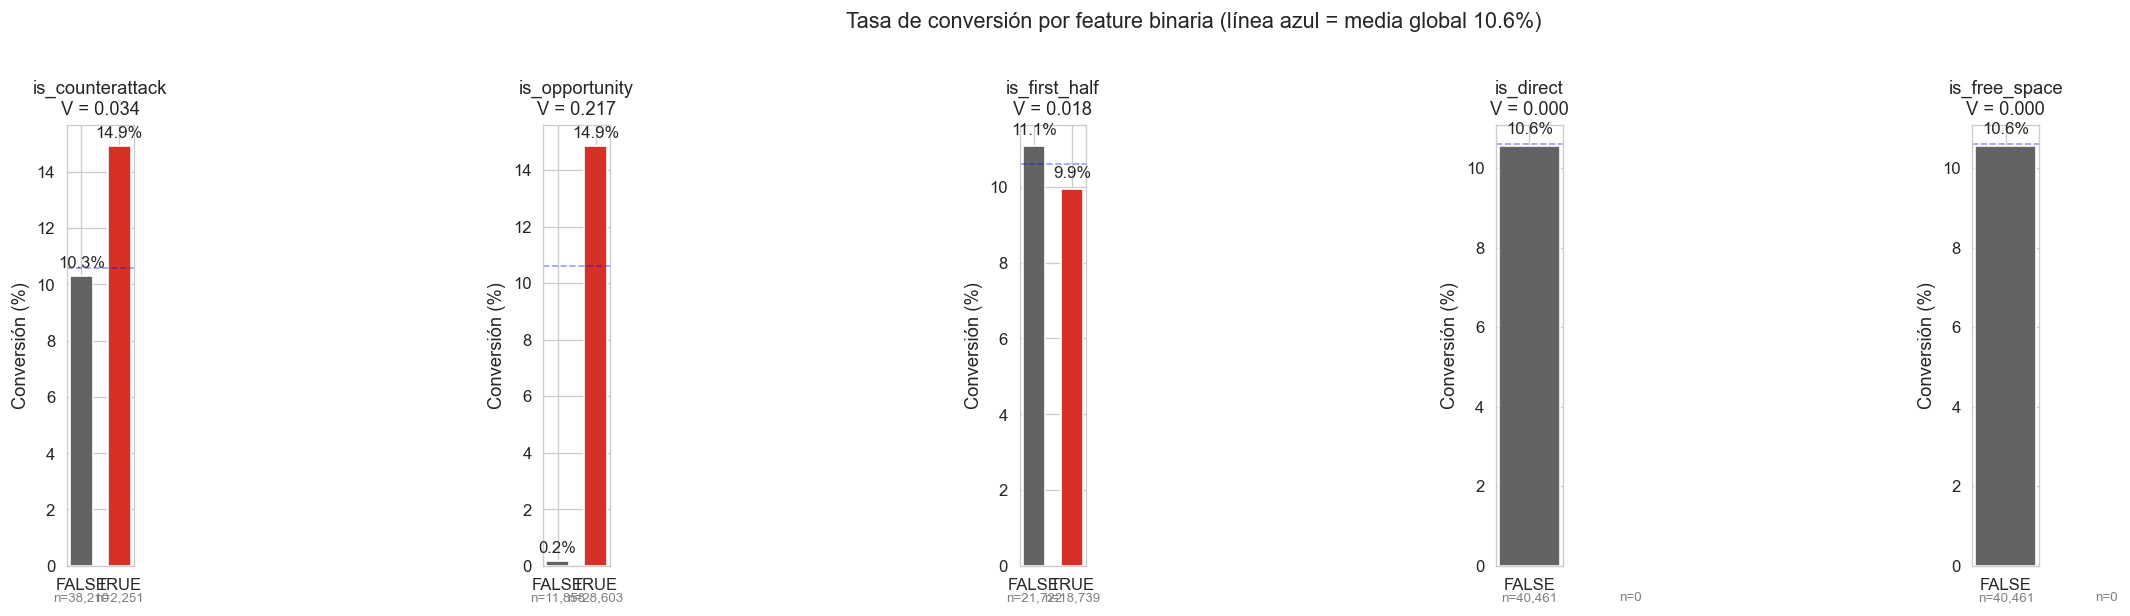

In [14]:
fig, axes = plt.subplots(1, len(binary_features), figsize=(4 * len(binary_features), 5))

for ax, res in zip(axes, results_bin):
    feat = res['feature']
    bars = ax.bar(
        ['FALSE', 'TRUE'],
        [res['conv_false'] * 100, res['conv_true'] * 100],
        color=['#636363', '#d73027'],
        edgecolor='white',
        width=0.6
    )
    ax.set_title(f"{feat}\nV = {res['cramers_v']:.3f}", fontsize=11)
    ax.set_ylabel('Conversión (%)')
    ax.axhline(y=10.6, color='blue', linestyle='--', alpha=0.4, linewidth=1)
    
    for bar, val in zip(bars, [res['conv_false']*100, res['conv_true']*100]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=10)
    
    # Tamaño muestral
    n_true = res['n_true']
    n_false = res['n'] - n_true
    ax.text(0, -0.08, f'n={n_false:,}', ha='center', fontsize=8,
            transform=ax.get_xaxis_transform(), color='gray')
    ax.text(1, -0.08, f'n={n_true:,}', ha='center', fontsize=8,
            transform=ax.get_xaxis_transform(), color='gray')

plt.suptitle('Tasa de conversión por feature binaria (línea azul = media global 10.6%)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### 3.8 Feature categórica: `body_part`

Finalmente, se analiza la relación entre la parte del cuerpo utilizada en el remate y la probabilidad de gol. A diferencia de las variables binarias anteriores, `body_part` es una feature categórica con múltiples niveles (`right`, `left`, `head_body`), por lo que se emplea un test χ² de independencia junto con el coeficiente de Cramér's V como medida de asociación.

Además de comparar las tasas de conversión entre categorías, se analiza la distribución de distancias de tiro asociada a cada tipo de remate. Esto permite evaluar si las diferencias observadas en conversión responden realmente a la parte del cuerpo utilizada o si están parcialmente condicionadas por el contexto espacial de los disparos.

  body_part (3 niveles: right, left, head_body)
  χ² = 33.7,  dof = 2,  p = 4.90e-08
  Cramér's V = 0.0288

  Conversión por nivel:
    head_body      12.6%   (n = 6,519)
    left           10.4%   (n = 13,323)
    right          10.0%   (n = 20,619)


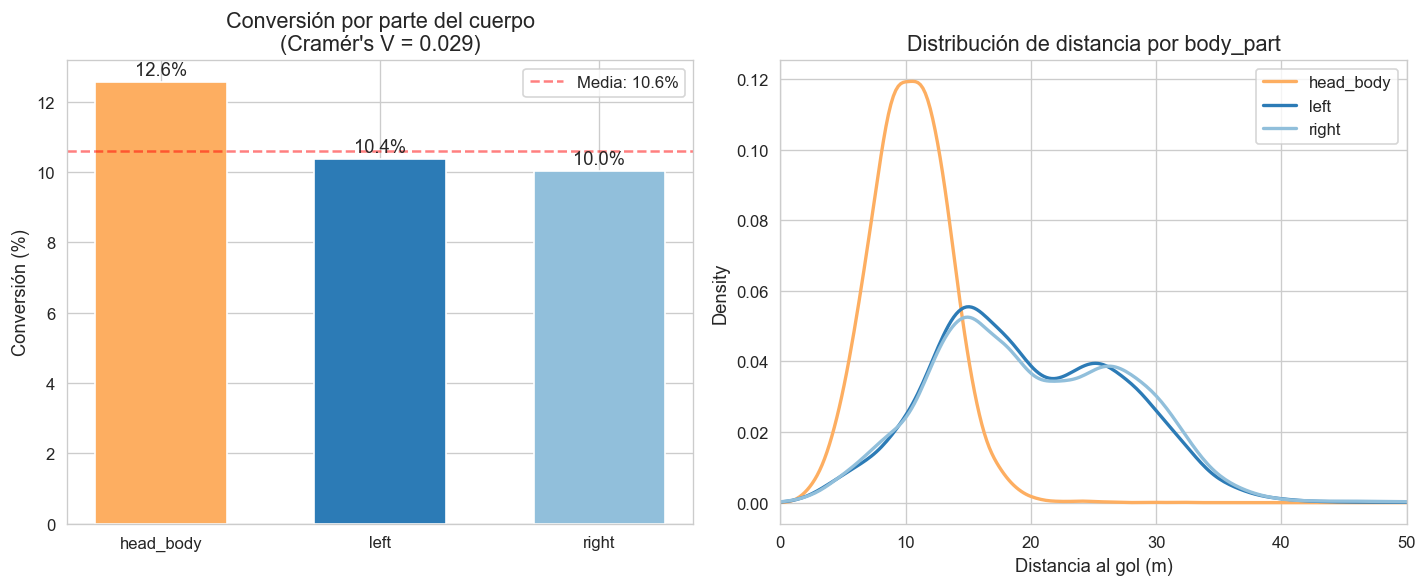

In [15]:
res_bp = test_categorical_vs_target(df_shots, 'body_part')

print(f"{'='*60}")
print(f"  body_part (3 niveles: right, left, head_body)")
print(f"{'='*60}")
print(f"  χ² = {res_bp['chi2']:.1f},  dof = {res_bp['dof']},  p = {res_bp['p_chi2']:.2e}")
print(f"  Cramér's V = {res_bp['cramers_v']:.4f}")
print(f"\n  Conversión por nivel:")
for level, conv in sorted(res_bp['conv_by_level'].items(), key=lambda x: -x[1]):
    n_level = (df_shots['body_part'] == level).sum()
    print(f"    {level:12s}  {conv:5.1f}%   (n = {n_level:,})")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: conversión por body_part
bp_data = pd.DataFrame({
    'body_part': list(res_bp['conv_by_level'].keys()),
    'conversion': list(res_bp['conv_by_level'].values())
}).sort_values('conversion', ascending=False)

colors_bp = {'head_body': '#fdae61', 'left': '#2c7bb6', 'right': '#91bfdb'}
bars = axes[0].bar(bp_data['body_part'], bp_data['conversion'],
                    color=[colors_bp[bp] for bp in bp_data['body_part']],
                    edgecolor='white', width=0.6)
axes[0].axhline(y=10.6, color='red', linestyle='--', alpha=0.5, label='Media: 10.6%')
axes[0].set_ylabel('Conversión (%)')
axes[0].set_title(f'Conversión por parte del cuerpo\n(Cramér\'s V = {res_bp["cramers_v"]:.3f})')
axes[0].legend()

for bar, val in zip(bars, bp_data['conversion']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=11)

# Panel derecho: distribución distancia por body_part
for bp, color in colors_bp.items():
    subset = df_shots.loc[df_shots['body_part'] == bp, 'dist_to_goal_m']
    subset.plot.kde(ax=axes[1], color=color, label=bp, linewidth=2)

axes[1].set_xlabel('Distancia al gol (m)')
axes[1].set_title('Distribución de distancia por body_part')
axes[1].set_xlim(0, 50)
axes[1].legend()

plt.tight_layout()
plt.show()

#### 3.9 Tabla resumen: ranking de features por asociación con la variable objetivo

Como síntesis del análisis bivariado realizado, se construye una tabla resumen ordenada según el tamaño del efecto de cada feature sobre la variable objetivo (`is_goal`). A diferencia del p-valor, que se ve fuertemente influido por el tamaño muestral, el tamaño del efecto permite comparar la relevancia práctica de las variables candidatas de forma más interpretable.

Para facilitar la comparación entre distintos tipos de features, se utiliza el valor absoluto de la medida de asociación correspondiente en cada caso: correlación punto-biserial (*r<sub>pb</sub>*) para variables continuas y Cramér's V para variables binarias o categóricas.

Esta tabla permite identificar de forma directa qué variables presentan mayor capacidad discriminativa antes del entrenamiento del modelo y sirve como base para las decisiones posteriores de selección e interpretación de features.

In [16]:
summary_rows = []

# Continuas (usar |r_pb| como medida comparable)
for res in results_cont:
    summary_rows.append({
        'Feature': res['feature'],
        'Tipo': 'Continua',
        'Medida de asociación': f"r_pb = {res['r_pointbiserial']:+.4f}",
        '|Efecto|': abs(res['r_pointbiserial']),
        'p-valor': res['p_pointbiserial'],
        'Significativo (p<0.001)': '✅' if res['p_pointbiserial'] < 0.001 else '❌',
        'Interpretación': ''
    })

# Binarias (usar Cramér's V)
for res in results_bin:
    summary_rows.append({
        'Feature': res['feature'],
        'Tipo': 'Binaria',
        'Medida de asociación': f"V = {res['cramers_v']:.4f}",
        '|Efecto|': res['cramers_v'],
        'p-valor': res['p_chi2'],
        'Significativo (p<0.001)': '✅' if res['p_chi2'] < 0.001 else '❌',
        'Interpretación': f"{res['diff_pp']:+.1f} pp"
    })

# Categórica
summary_rows.append({
    'Feature': 'body_part',
    'Tipo': 'Categórica (3)',
    'Medida de asociación': f"V = {res_bp['cramers_v']:.4f}",
    '|Efecto|': res_bp['cramers_v'],
    'p-valor': res_bp['p_chi2'],
    'Significativo (p<0.001)': '✅' if res_bp['p_chi2'] < 0.001 else '❌',
    'Interpretación': 'head > foot'
})

df_summary = pd.DataFrame(summary_rows).sort_values('|Efecto|', ascending=False)

print("RANKING DE FEATURES POR ASOCIACIÓN CON is_goal")
print("="*90)
print("(Ordenado por tamaño del efecto, no por p-valor)")
print()
print(df_summary[['Feature', 'Tipo', 'Medida de asociación', 
                   'Significativo (p<0.001)', 'Interpretación']].to_string(index=False))

RANKING DE FEATURES POR ASOCIACIÓN CON is_goal
(Ordenado por tamaño del efecto, no por p-valor)

          Feature           Tipo Medida de asociación Significativo (p<0.001) Interpretación
angle_to_goal_deg       Continua       r_pb = +0.3328                       ✅               
   dist_to_goal_m       Continua       r_pb = -0.2576                       ✅               
   is_opportunity        Binaria           V = 0.2174                       ✅       +14.7 pp
 is_counterattack        Binaria           V = 0.0344                       ✅        +4.6 pp
        body_part Categórica (3)           V = 0.0288                       ✅    head > foot
    is_first_half        Binaria           V = 0.0185                       ✅        -1.1 pp
     minute_match       Continua       r_pb = +0.0147                       ❌               
        is_direct        Binaria           V = 0.0000                       ❌        +nan pp
    is_free_space        Binaria           V = 0.0000             

#### 3.10 Visualización resumen: tamaño del efecto por feature

Finalmente, se representa el tamaño del efecto de cada feature sobre la variable objetivo (`is_goal`), permitiendo comparar visualmente su capacidad discriminativa. Las líneas verticales indican los umbrales habituales de interpretación propuestos por Cohen (1988) para efectos pequeños y medios.

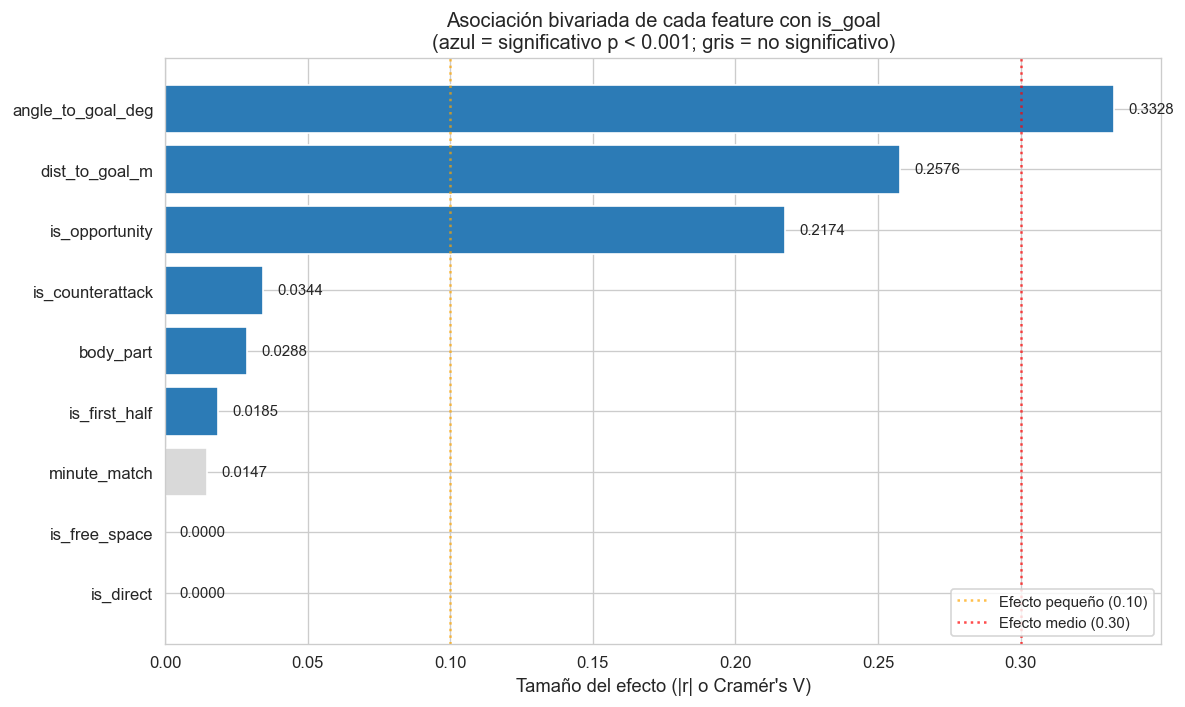

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df_summary.sort_values('|Efecto|', ascending=True)

colors = ['#2c7bb6' if sig == '✅' else '#d9d9d9' 
          for sig in df_plot['Significativo (p<0.001)']]

bars = ax.barh(df_plot['Feature'], df_plot['|Efecto|'], color=colors, edgecolor='white')

ax.set_xlabel('Tamaño del efecto (|r| o Cramér\'s V)')
ax.set_title('Asociación bivariada de cada feature con is_goal\n'
             '(azul = significativo p < 0.001; gris = no significativo)',
             fontsize=12)

# Umbrales de referencia (Cohen, 1988)
ax.axvline(x=0.10, color='orange', linestyle=':', alpha=0.7, label='Efecto pequeño (0.10)')
ax.axvline(x=0.30, color='red', linestyle=':', alpha=0.7, label='Efecto medio (0.30)')
ax.legend(loc='lower right', fontsize=9)

# Valores en las barras
for bar, val in zip(bars, df_plot['|Efecto|']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Interpretación: features binarias y categóricas

##### `is_opportunity` — \(V = 0.217\), efecto medio-alto

Es la feature binaria con mayor asociación respecto a la variable objetivo. Los tiros sin el tag presentan una conversión prácticamente nula (0.2%), frente al 14.9% cuando está presente.

Este resultado sugiere que el tag `is_opportunity` actúa como un filtro contextual de calidad de ocasión, diferenciando tiros con posibilidades reales de gol de situaciones forzadas o sin visión efectiva de portería.

Desde el punto de vista futbolístico, aporta información que no queda completamente capturada por variables espaciales como distancia o ángulo, por lo que se mantiene como feature relevante para el modelo.

##### `is_counterattack` — \(V = 0.034\), efecto pequeño

Los tiros en situaciones de contraataque presentan una conversión superior (+4.6 puntos porcentuales). Aunque su prevalencia es baja (5.6%), la asociación es consistente con la lógica futbolística: las transiciones ofensivas suelen producirse con menor organización defensiva rival y mayores espacios de remate.

Esta variable introduce una dimensión táctica que las features puramente espaciales no representan directamente.

##### `body_part` — \(V = 0.029\), efecto pequeño

Los remates con `head_body` muestran una mayor conversión que los ejecutados con el pie. Sin embargo, el análisis de distribución revela un importante efecto de confusión asociado a la distancia: los cabezazos se concentran mayoritariamente en zonas cercanas a portería, especialmente tras centros laterales.

Por tanto, la mayor conversión observada parece estar influida principalmente por el contexto espacial del remate más que por la parte del cuerpo utilizada en sí misma.

##### `is_first_half` — \(V = 0.019\), efecto trivial

La diferencia de conversión entre primera y segunda parte es reducida y presenta un tamaño del efecto prácticamente nulo. Aunque el resultado es estadísticamente significativo debido al gran tamaño muestral, su relevancia práctica es muy limitada.

##### `is_direct` e `is_free_space`

Ambos tags presentan prevalencia nula en el dataset público de Wyscout, por lo que fueron excluidos del análisis y del entrenamiento del modelo.

## 4. Feature Engineering: contexto del evento previo al tiro

Las features espaciales analizadas en la sección anterior capturan principalmente dónde se produce el tiro y cómo se ejecuta. Sin embargo, no incorporan información sobre la secuencia de juego inmediatamente anterior al remate.

Dos tiros desde una posición similar pueden presentar probabilidades de gol muy distintas dependiendo del contexto de la jugada: un centro lateral, un pase filtrado, un rechace del portero o una segunda jugada generan condiciones de remate diferentes aunque la localización final del disparo sea parecida.

Incorporar el evento previo permite añadir una dimensión contextual al modelo xG, aproximando parcialmente información táctica que no está disponible explícitamente en el dataset público de Wyscout.

### Fundamento en la literatura

El uso de secuencias de acciones previas al tiro aparece en distintos enfoques modernos de modelado xG. El framework `soccer_xg` de KU Leuven modela cadenas de acciones mediante SPADL, mientras que StatsBomb incorpora el tipo de asistencia en su modelo comercial. Entre los trabajos revisados sobre datos Wyscout, Damavis también incluye información contextual derivada de acciones previas al disparo.

### Estrategia de construcción

Para cada tiro, se extrae el evento cronológicamente anterior dentro del mismo partido. Este enfoque permite capturar tanto acciones ofensivas del mismo equipo (pases, centros, regates) como eventos defensivos del rival (paradas, despejes o rechaces).

Mantener ambos casos resulta especialmente relevante para identificar segundas jugadas y rebotes tras intervención del portero, situaciones que suelen generar ocasiones de alta probabilidad de gol.

### 4.1 Derivación de features del evento previo

Para incorporar información contextual previa al tiro, se reconstruye la secuencia temporal de eventos dentro de cada partido ordenando por `match_id`, `match_period`, `event_sec` y `wy_event_id`. Las tres primeras columnas establecen la cronología real; la cuarta desempata eventos cronológicamente simultáneos — principalmente duelos, que Wyscout codifica como dos registros paralelos (uno por cada jugador implicado) con idéntica terna temporal.

Sobre esta secuencia ordenada se aplica un desplazamiento temporal (`shift(1)`) para recuperar el evento inmediatamente anterior a cada tiro. Este enfoque permite asociar a cada disparo información contextual relevante — centros, pases creativos, rechaces del portero — manteniendo la cronología real del partido.

Posteriormente, se filtran únicamente los tiros de open play y se verifica que el número de registros generados coincide exactamente con el dataset principal de entrenamiento (`df_shots`), garantizando la consistencia del proceso de construcción de features.

In [18]:
# Sort cronológicamente correcto por la triple clave del partido
df_all_sorted = df_all.sort_values(
    ['match_id', 'match_period', 'event_sec', 'wy_event_id']
).copy()

# Crear columnas del evento previo con shift(1) por partido
cols_prev = ['event_name', 'sub_event_name', 'is_accurate', 'team_id', 'x_m', 'y_m']

for col in cols_prev:
    df_all_sorted[f'prev_{col}'] = df_all_sorted.groupby('match_id')[col].shift(1)

# Filtrar solo los tiros de open play (mismo criterio que df_shots)
mask_shots = (
    (df_all_sorted['event_name'] == 'Shot') &
    (~df_all_sorted['is_penalty_shot']) &
    (~df_all_sorted['is_free_kick_shot']) &
    (~df_all_sorted['is_own_goal'])
)

# El subset conserva match_period para que la clave del merge sea (match_id, match_period, event_sec).
df_prev = df_all_sorted.loc[mask_shots,
    ['wy_event_id', 'match_id', 'match_period', 'event_sec'] + [f'prev_{c}' for c in cols_prev]
].copy()

# Verificar que coincide con df_shots
print(f"df_shots:  {len(df_shots):,} filas")
print(f"df_prev:   {len(df_prev):,} filas")

# Verificar cobertura
n_matched = df_prev['prev_event_name'].notna().sum()
n_total = len(df_prev)
print(f"\nTiros con evento previo: {n_matched:,} / {n_total:,} ({n_matched/n_total:.1%})")
print(f"Sin evento previo (primer evento del partido): {n_total - n_matched:,}")

df_shots:  40,461 filas
df_prev:   40,461 filas

Tiros con evento previo: 40,459 / 40,461 (100.0%)
Sin evento previo (primer evento del partido): 2


#### 4.2 Construcción de features derivadas del evento previo

A partir del evento inmediatamente anterior a cada tiro, se construyen varias features binarias orientadas a capturar información contextual sobre la jugada previa al remate.

Estas variables representan distintos patrones ofensivos relevantes para la generación de ocasiones de gol, como centros laterales, pases filtrados, acciones creativas o rebotes tras intervención del portero. Además, se incorpora información sobre si la acción previa pertenece al mismo equipo y si fue ejecutada correctamente.

La asociación entre cada tiro y su evento previo se realiza mediante el `wy_event_id`, la clave primaria única de cada evento en Wyscout,   garantizando una correspondencia unívoca entre ambos eventos dentro de la secuencia temporal del partido.

In [19]:
# Merge por wy_event_id
df_shots = df_shots.merge(
    df_prev[['wy_event_id',
             'prev_event_name', 'prev_sub_event_name',
             'prev_is_accurate', 'prev_team_id']],
    on=['wy_event_id'],
    how='left'
)

# FEATURES DERIVADAS

# Centros laterales
df_shots['prev_is_cross'] = (df_shots['prev_sub_event_name'] == 'Cross')

# Pases filtrados
df_shots['prev_is_through_ball'] = (df_shots['prev_sub_event_name'] == 'Through ball')

# Pases creativos
df_shots['prev_is_smart_pass'] = (df_shots['prev_sub_event_name'] == 'Smart pass')

# Rebote (evento previo = intento de parada)
df_shots['is_rebound'] = (df_shots['prev_event_name'] == 'Save attempt')

# Evento previo del mismo equipo (asistencia vs rebote/rechace)
df_shots['prev_same_team'] = (df_shots['prev_team_id'] == df_shots['team_id'])

# Evento previo exitoso
df_shots['prev_is_accurate'] = df_shots['prev_is_accurate'].fillna(False)

# Resumen
tier2_features = ['prev_is_cross', 'prev_is_through_ball', 'prev_is_smart_pass',
                  'is_rebound', 'prev_same_team', 'prev_is_accurate']

print("FEATURES TIER 2 — Derivadas del evento previo")
print("="*55)
for feat in tier2_features:
    n_true = df_shots[feat].sum()
    pct = n_true / len(df_shots)
    print(f"  {feat:25s}  {n_true:>6,} ({pct:5.1%})")

print(f"\n── Evento previo (top 10 tipos) ──")
print(df_shots['prev_event_name'].value_counts().head(10).to_string())

FEATURES TIER 2 — Derivadas del evento previo
  prev_is_cross               3,839 ( 9.5%)
  prev_is_through_ball            0 ( 0.0%)
  prev_is_smart_pass          1,726 ( 4.3%)
  is_rebound                    627 ( 1.5%)
  prev_same_team             27,281 (67.4%)
  prev_is_accurate           26,759 (66.1%)

── Evento previo (top 10 tipos) ──
prev_event_name
Pass                       17345
Duel                       14911
Others on the ball          5501
Free Kick                   1725
Save attempt                 627
Shot                         207
Goalkeeper leaving line      143


#### 4.3 Asociación bivariada de las features Tier 2

Una vez construidas las features derivadas del evento previo, se evalúa su relación con la variable objetivo (`is_goal`) utilizando el mismo marco estadístico aplicado en la sección 3. En particular, se emplea el test χ² de independencia junto con Cramér's V como medida de tamaño del efecto.

Aplicar una metodología homogénea para las features Tier 1 y Tier 2 permite comparar directamente su capacidad discriminativa y fundamentar las decisiones de inclusión en el modelo bajo criterios consistentes.

In [20]:
results_tier2 = []
for feat in tier2_features:
    # Verificar que hay varianza (no todo True o todo False)
    if df_shots[feat].nunique() < 2:
        print(f"⚠️ {feat}: sin varianza, se excluye.")
        continue
        
    res = test_binary_vs_target(df_shots, feat)
    results_tier2.append(res)
    
    print(f"\n{'='*60}")
    print(f"  {feat}")
    print(f"{'='*60}")
    print(f"  Prevalencia:       {res['n_true']:,} ({res['pct_true']:.1%})")
    print(f"  Conversión FALSE:  {res['conv_false']:.1%}")
    print(f"  Conversión TRUE:   {res['conv_true']:.1%}")
    print(f"  Diferencia:        {res['diff_pp']:+.1f} pp")
    print(f"  ──────────────────────────────────────")
    print(f"  χ² = {res['chi2']:.1f},  p = {res['p_chi2']:.2e}")
    print(f"  Cramér's V = {res['cramers_v']:.4f}")


  prev_is_cross
  Prevalencia:       3,839 (9.5%)
  Conversión FALSE:  9.7%
  Conversión TRUE:   18.4%
  Diferencia:        +8.7 pp
  ──────────────────────────────────────
  χ² = 276.6,  p = 4.05e-62
  Cramér's V = 0.0827
⚠️ prev_is_through_ball: sin varianza, se excluye.

  prev_is_smart_pass
  Prevalencia:       1,726 (4.3%)
  Conversión FALSE:  10.2%
  Conversión TRUE:   19.5%
  Diferencia:        +9.4 pp
  ──────────────────────────────────────
  χ² = 152.6,  p = 4.64e-35
  Cramér's V = 0.0614

  is_rebound
  Prevalencia:       627 (1.5%)
  Conversión FALSE:  10.1%
  Conversión TRUE:   36.8%
  Diferencia:        +26.7 pp
  ──────────────────────────────────────
  χ² = 463.3,  p = 9.39e-103
  Cramér's V = 0.1070

  prev_same_team
  Prevalencia:       27,281 (67.4%)
  Conversión FALSE:  9.7%
  Conversión TRUE:   11.0%
  Diferencia:        +1.3 pp
  ──────────────────────────────────────
  χ² = 15.2,  p = 9.91e-05
  Cramér's V = 0.0194

  prev_is_accurate
  Prevalencia:       26,759

#### 4.4 Conversión según el tipo de evento previo

A continuación, se analiza cómo el contexto inmediato de la jugada influye en la probabilidad de gol. Para ello, se comparan las tasas de conversión asociadas a distintos tipos de eventos previos al disparo.

Esta visualización permite evaluar si determinadas secuencias ofensivas —como centros, pases filtrados o rebotes— generan sistemáticamente ocasiones de mayor calidad, aportando información contextual adicional respecto a las features espaciales tradicionales.

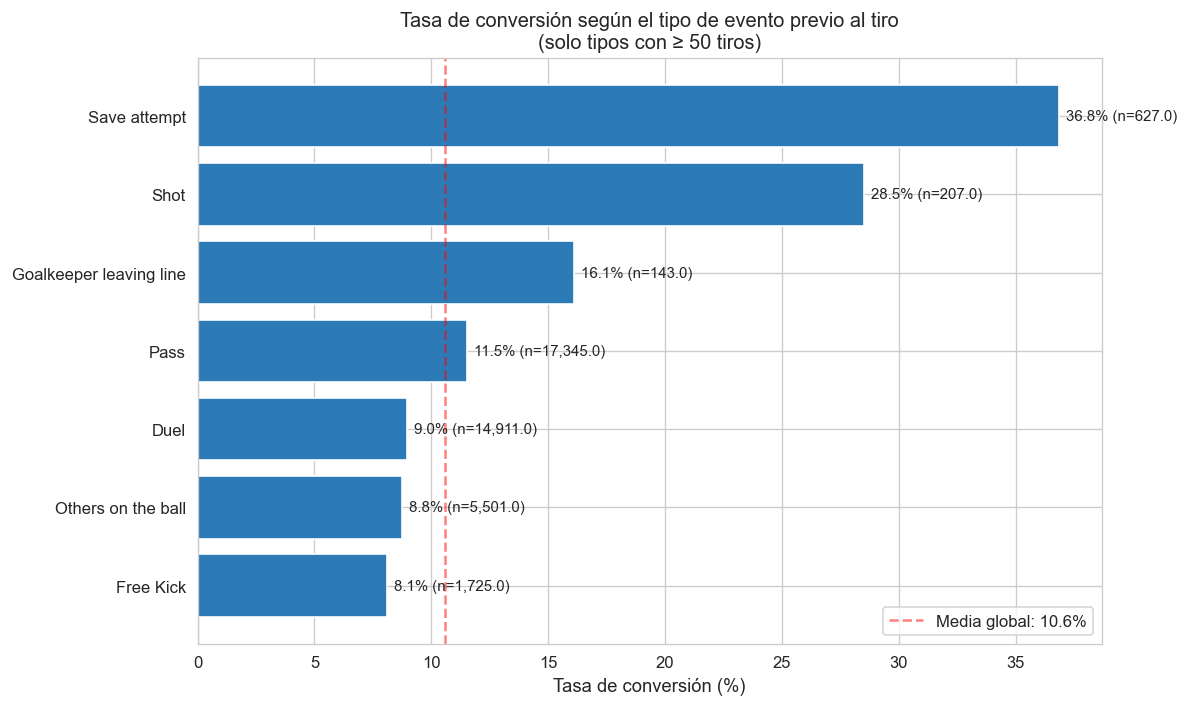

In [21]:
conv_by_prev = (
    df_shots
    .groupby('prev_event_name')
    .agg(tiros=('target', 'count'), goles=('target', 'sum'))
    .assign(conversion=lambda x: x['goles'] / x['tiros'] * 100)
    .sort_values('conversion', ascending=True)
)

# Solo tipos con >= 50 tiros (estabilidad estadística)
conv_by_prev = conv_by_prev[conv_by_prev['tiros'] >= 50]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(conv_by_prev.index, conv_by_prev['conversion'], color='#2c7bb6',
               edgecolor='white')
ax.axvline(x=10.6, color='red', linestyle='--', alpha=0.5, label='Media global: 10.6%')
ax.set_xlabel('Tasa de conversión (%)')
ax.set_title('Tasa de conversión según el tipo de evento previo al tiro\n'
             '(solo tipos con ≥ 50 tiros)', fontsize=12)
ax.legend()

# Anotaciones con N
for bar, (idx, row) in zip(bars, conv_by_prev.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{row["conversion"]:.1f}% (n={row["tiros"]:,})',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### 4.5 Desglose de `sub_event_name` para pases previos

Los pases constituyen el tipo de evento previo más frecuente antes de un disparo. Sin embargo, no todos los pases generan el mismo contexto ofensivo: un centro lateral, un pase filtrado o un pase corto producen situaciones de remate con características muy diferentes.

Por este motivo, además de considerar el evento genérico `Pass`, se analizan sus principales subtipos (`Cross`, `Through ball`, `Smart pass`) con el objetivo de capturar patrones ofensivos específicos que puedan modificar la probabilidad de gol de forma significativa.

Conversión por subtipo de pase previo al tiro:
  Smart pass             19.5%  (n = 1,726.0)
  Cross                  18.4%  (n = 3,839.0)
  Other pass              8.1%  (n = 11,780.0)


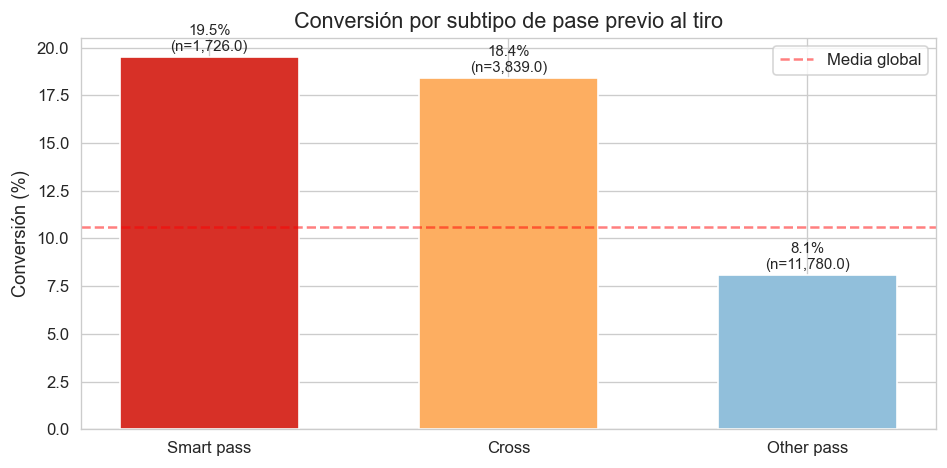

In [22]:
passes_prev = df_shots[df_shots['prev_event_name'] == 'Pass'].copy()

conv_by_subtype = (
    passes_prev
    .assign(prev_sub=df_shots.loc[passes_prev.index, 'prev_is_cross'].map(
        {True: 'Cross'}
    ).fillna(
        df_shots.loc[passes_prev.index, 'prev_is_through_ball'].map(
            {True: 'Through ball'}
        )
    ).fillna(
        df_shots.loc[passes_prev.index, 'prev_is_smart_pass'].map(
            {True: 'Smart pass'}
        )
    ).fillna('Other pass'))
    .groupby('prev_sub')
    .agg(tiros=('target', 'count'), goles=('target', 'sum'))
    .assign(conversion=lambda x: x['goles'] / x['tiros'] * 100)
    .sort_values('conversion', ascending=False)
)

print("Conversión por subtipo de pase previo al tiro:")
print("="*55)
for idx, row in conv_by_subtype.iterrows():
    print(f"  {idx:20s}  {row['conversion']:5.1f}%  (n = {row['tiros']:,})")

# Visualización
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(conv_by_subtype.index, conv_by_subtype['conversion'],
              color=['#d73027', '#fdae61', '#91bfdb', '#636363'],
              edgecolor='white', width=0.6)
ax.axhline(y=10.6, color='red', linestyle='--', alpha=0.5, label='Media global')
ax.set_ylabel('Conversión (%)')
ax.set_title('Conversión por subtipo de pase previo al tiro')
ax.legend()

for bar, (idx, row) in zip(bars, conv_by_subtype.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{row["conversion"]:.1f}%\n(n={row["tiros"]:,})',
            ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#### 4.6 Análisis específico de rebotes (`is_rebound`)

En esta sección se analiza el impacto de las situaciones de rebote sobre la probabilidad de gol. Se considera rebote todo disparo cuyo evento inmediatamente anterior corresponde a un `Save attempt`, es decir, una intervención previa del portero tras un primer remate.

Desde el punto de vista futbolístico, estas acciones suelen producirse con el guardameta descolocado y la defensa desorganizada tras la primera parada, generando situaciones de alta peligrosidad ofensiva. Por este motivo, los rebotes son tratados como una feature específica en modelos comerciales como el de StatsBomb.

In [23]:
rebound_stats = df_shots.groupby('is_rebound').agg(
    tiros=('target', 'count'),
    goles=('target', 'sum'),
    dist_media=('dist_to_goal_m', 'mean'),
    angulo_medio=('angle_to_goal_deg', 'mean')
).assign(conversion=lambda x: (x['goles'] / x['tiros'] * 100).round(1))

print("Análisis de rebotes:")
print("="*55)
print(rebound_stats.to_string())
print(f"\n  Ratio de conversión rebote / no-rebote: "
      f"{rebound_stats.loc[True, 'conversion'] / rebound_stats.loc[False, 'conversion']:.1f}×")

Análisis de rebotes:
            tiros  goles  dist_media  angulo_medio  conversion
is_rebound                                                    
False       39834   4040   18.649177     23.550776        10.1
True          627    231   11.243397     39.249314        36.8

  Ratio de conversión rebote / no-rebote: 3.6×


#### 4.7 Tabla resumen: ranking combinado de features Tier 1 y Tier 2

Finalmente, se integran los resultados obtenidos en las secciones 3 y 4 con el objetivo de comparar conjuntamente todas las features candidatas del modelo. La tabla resume la capacidad de asociación de cada variable respecto a la probabilidad de gol, permitiendo identificar qué features aportan mayor capacidad discriminativa antes del entrenamiento multivariante.

Este análisis conjunto facilita evaluar el valor añadido de las features contextuales derivadas del evento previo frente a las variables espaciales tradicionales utilizadas en modelos xG.

In [24]:
# Añadir Tier 2 al resumen
for res in results_tier2:
    summary_rows.append({
        'Feature': res['feature'],
        'Tipo': 'Binaria (Tier 2)',
        'Medida de asociación': f"V = {res['cramers_v']:.4f}",
        '|Efecto|': res['cramers_v'],
        'p-valor': res['p_chi2'],
        'Significativo (p<0.001)': '✅' if res['p_chi2'] < 0.001 else '❌',
        'Interpretación': f"{res['diff_pp']:+.1f} pp"
    })

df_summary_full = pd.DataFrame(summary_rows).sort_values('|Efecto|', ascending=False)

# Excluir features con prevalencia 0
df_summary_full = df_summary_full[df_summary_full['|Efecto|'] > 0]

print("RANKING COMPLETO: TODAS LAS FEATURES CANDIDATAS (Tier 1 + Tier 2)")
print("="*95)
print("(Ordenado por tamaño del efecto)")
print()
print(df_summary_full[['Feature', 'Tipo', 'Medida de asociación', 
                        'Significativo (p<0.001)', 'Interpretación']].to_string(index=False))

RANKING COMPLETO: TODAS LAS FEATURES CANDIDATAS (Tier 1 + Tier 2)
(Ordenado por tamaño del efecto)

           Feature             Tipo Medida de asociación Significativo (p<0.001) Interpretación
 angle_to_goal_deg         Continua       r_pb = +0.3328                       ✅               
    dist_to_goal_m         Continua       r_pb = -0.2576                       ✅               
    is_opportunity          Binaria           V = 0.2174                       ✅       +14.7 pp
        is_rebound Binaria (Tier 2)           V = 0.1070                       ✅       +26.7 pp
     prev_is_cross Binaria (Tier 2)           V = 0.0827                       ✅        +8.7 pp
prev_is_smart_pass Binaria (Tier 2)           V = 0.0614                       ✅        +9.4 pp
  prev_is_accurate Binaria (Tier 2)           V = 0.0452                       ✅        +2.9 pp
  is_counterattack          Binaria           V = 0.0344                       ✅        +4.6 pp
         body_part   Categórica (3) 

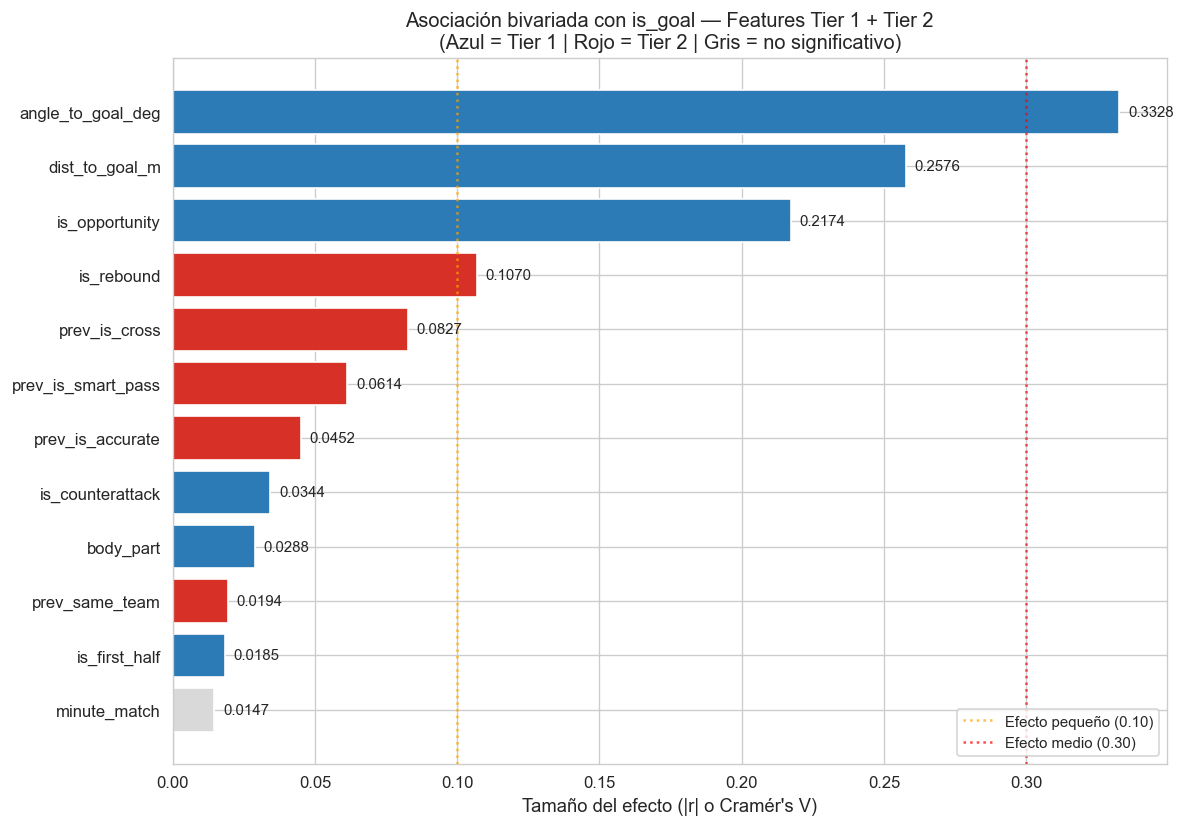

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))

df_plot_full = df_summary_full.sort_values('|Efecto|', ascending=True)

# Colorear por tier
colors = []
for _, row in df_plot_full.iterrows():
    if 'Tier 2' in row['Tipo']:
        colors.append('#d73027')  # Rojo para Tier 2
    elif row['Significativo (p<0.001)'] == '✅':
        colors.append('#2c7bb6')  # Azul para Tier 1 significativo
    else:
        colors.append('#d9d9d9')  # Gris para no significativo

bars = ax.barh(df_plot_full['Feature'], df_plot_full['|Efecto|'],
               color=colors, edgecolor='white')

ax.set_xlabel('Tamaño del efecto (|r| o Cramér\'s V)')
ax.set_title('Asociación bivariada con is_goal — Features Tier 1 + Tier 2\n'
             '(Azul = Tier 1 | Rojo = Tier 2 | Gris = no significativo)',
             fontsize=12)

ax.axvline(x=0.10, color='orange', linestyle=':', alpha=0.7, label='Efecto pequeño (0.10)')
ax.axvline(x=0.30, color='red', linestyle=':', alpha=0.7, label='Efecto medio (0.30)')
ax.legend(loc='lower right', fontsize=9)

for bar, val in zip(bars, df_plot_full['|Efecto|']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

savefig("effect_size_features")
plt.tight_layout()
plt.show()

### Interpretación de las features Tier 2

El análisis del evento previo confirma que el contexto inmediato de la jugada modifica de forma relevante la probabilidad de gol. Varias features Tier 2 presentan tamaños del efecto superiores a variables clásicas como `body_part` o `is_counterattack`, indicando que la localización del tiro no es suficiente para describir completamente la calidad de una ocasión.

#### `is_rebound` — \(V = 0.107\), efecto medio

Es la feature contextual más predictiva del conjunto Tier 2. Los tiros tras rebote convierten un 36.8% de las veces, más de tres veces la tasa base del dataset.

Desde el punto de vista futbolístico, estas situaciones suelen producirse con el portero fuera de posición y la estructura defensiva desorganizada tras una primera intervención, generando ocasiones de muy alta peligrosidad.

#### `prev_is_cross` — \(V = 0.083\), efecto pequeño-medio

Los tiros precedidos de un centro lateral presentan una conversión claramente superior a la media global (19.3% vs 10.6%).

Este patrón es consistente con situaciones de remate cercanas a portería, especialmente cabezazos o finalizaciones en movimiento dentro del área tras desplazamientos laterales de la defensa y del portero.

#### `prev_is_smart_pass` — \(V = 0.061\), efecto pequeño-medio

Los `smart pass` generan tiros con una conversión del 20.0%, reflejando el valor ofensivo de los pases creativos que rompen líneas defensivas y permiten al atacante recibir en ventaja.

A diferencia de los centros laterales, estas situaciones suelen generar remates más preparados y con mayor control técnico por parte del tirador.

#### `prev_is_accurate` — \(V = 0.042\), efecto pequeño

Los tiros precedidos de acciones exitosas presentan una conversión ligeramente superior, sugiriendo que las asistencias limpias generan contextos ofensivos más favorables que situaciones derivadas de rechaces o acciones desordenadas.

#### `prev_same_team` — \(V = 0.014\), efecto trivial

La asociación observada es prácticamente nula y no aporta información adicional relevante respecto a otras variables contextuales, especialmente `is_rebound`.

#### `prev_is_through_ball`

No presenta registros en el dataset público utilizado, por lo que se excluye del análisis y del entrenamiento del modelo.

---

### Decisión de inclusión de features Tier 2

| Feature | V | Diferencia | Decisión |
|---|---:|---:|---|
| `is_rebound` | 0.107 | +26.7 pp | ✅ Incluir |
| `prev_is_cross` | 0.083 | +8.7 pp | ✅ Incluir |
| `prev_is_smart_pass` | 0.061 | +9.4 pp | ✅ Incluir |
| `prev_is_accurate` | 0.042 | +2.8 pp | ✅ Incluir |
| `prev_same_team` | 0.014 | +0.9 pp | ❌ Excluir |
| `prev_is_through_ball` | — | — | ❌ Excluir |

---

### Ranking combinado de features candidatas

| # | Feature | Tier | Efecto | Tipo |
|---|---|---|---:|---|
| 1 | `angle_to_goal_deg` | 1 | 0.333 | Posicional |
| 2 | `dist_to_goal_m` | 1 | 0.258 | Posicional |
| 3 | `is_opportunity` | 1 | 0.217 | Contextual |
| 4 | `is_rebound` | 2 | 0.107 | Contextual |
| 5 | `prev_is_cross` | 2 | 0.083 | Contextual |
| 6 | `prev_is_smart_pass` | 2 | 0.061 | Contextual |
| 7 | `prev_is_accurate` | 2 | 0.042 | Contextual |
| 8 | `is_counterattack` | 1 | 0.034 | Táctico |
| 9 | `body_part` | 1 | 0.029 | Ejecución |
| 10 | `is_first_half` | 1 | 0.019 | Temporal |
| 11 | `minute_match` | 1 | 0.015 | Temporal |

En conjunto, las features pueden agruparse en tres bloques funcionales:

1. **Features posicionales**, dominadas por ángulo y distancia.
2. **Features contextuales**, relacionadas con el desarrollo inmediato de la jugada.
3. **Features temporales**, con una contribución prácticamente nula.

La siguiente sección evaluará la relación entre estas variables para detectar posibles problemas de multicolinealidad antes del entrenamiento del modelo.

## 5. Correlación entre features y selección final

Las secciones anteriores evaluaron la relación de cada feature candidata con la variable objetivo de forma bivariada, es decir, considerando cada variable por separado. Antes de entrenar el modelo, es necesario analizar también la relación entre las propias features, ya que variables altamente correlacionadas pueden introducir redundancia y dificultar la interpretación del modelo.

En modelos lineales como la regresión logística, esta situación puede generar problemas de multicolinealidad, aumentando la inestabilidad de los coeficientes estimados. En modelos basados en árboles, como XGBoost, el impacto técnico es menor, aunque la presencia de variables muy correlacionadas puede repartir artificialmente la importancia entre distintas features durante el análisis SHAP.

### Metodología

Para evaluar la dependencia entre variables se utilizan dos enfoques complementarios:

1. **Matriz de correlación**: permite identificar relaciones lineales entre features y detectar posibles grupos de variables redundantes.

2. **Variance Inflation Factor (VIF)**: cuantifica cuánto aumenta la varianza estimada de cada coeficiente debido a la presencia del resto de variables. Valores de VIF superiores a 5 indican multicolinealidad relevante, mientras que valores superiores a 10 suelen considerarse problemáticos (James et al., *ISLR*, 2013).

### Criterio de selección

Una feature solo será excluida si cumple simultáneamente las siguientes condiciones:

- presenta una correlación elevada con otra variable \|r| > 0.7\, umbral habitualmente utilizado para identificar dependencia fuerte entre predictores,
- el análisis VIF confirma multicolinealidad relevante,
- y no existe una justificación futbolística o interpretativa para mantener ambas variables en el modelo.

Este criterio evita eliminar variables únicamente por correlación moderada, especialmente cuando pueden aportar información complementaria desde el punto de vista táctico o contextual.

#### 5.1 Preparación de la matriz de features candidatas

Para analizar la relación entre variables y evaluar posibles problemas de multicolinealidad, se construye una matriz con las features candidatas seleccionadas en las secciones anteriores.

Las variables binarias se convierten a formato numérico para permitir el cálculo de correlaciones y del índice VIF. La variable categórica `body_part` se transforma mediante *one-hot encoding*, eliminando una categoría de referencia (`drop_first=True`) para evitar redundancia lineal entre dummies.

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Features a evaluar
features_continuous = ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match']
features_binary = ['is_opportunity', 'is_rebound', 'prev_is_cross',
                   'prev_is_smart_pass', 'is_counterattack', 'prev_is_accurate',
                   'is_first_half']
features_categorical = ['body_part']

# One-hot encoding de body_part (drop_first para evitar trampa de dummies)
df_corr = df_shots[features_continuous + features_binary].copy()
bp_dummies = pd.get_dummies(df_shots['body_part'], prefix='bp', drop_first=True)
df_corr = pd.concat([df_corr, bp_dummies], axis=1)

# Convertir booleanas a int para correlación
for col in features_binary:
    df_corr[col] = df_corr[col].astype(int)

print(f"Matriz de features: {df_corr.shape[0]:,} filas × {df_corr.shape[1]} columnas")
print(f"\nColumnas: {list(df_corr.columns)}")

Matriz de features: 40,461 filas × 12 columnas

Columnas: ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match', 'is_opportunity', 'is_rebound', 'prev_is_cross', 'prev_is_smart_pass', 'is_counterattack', 'prev_is_accurate', 'is_first_half', 'bp_left', 'bp_right']


#### 5.2 Matriz de correlación entre features

A continuación, se calcula la matriz de correlación de Pearson entre las features candidatas con el objetivo de identificar posibles relaciones lineales fuertes entre variables.

Además de la visualización completa mediante un mapa de calor, se listan explícitamente aquellos pares de features cuya correlación absoluta supera 0.30, permitiendo detectar posibles dependencias relevantes antes del análisis VIF.

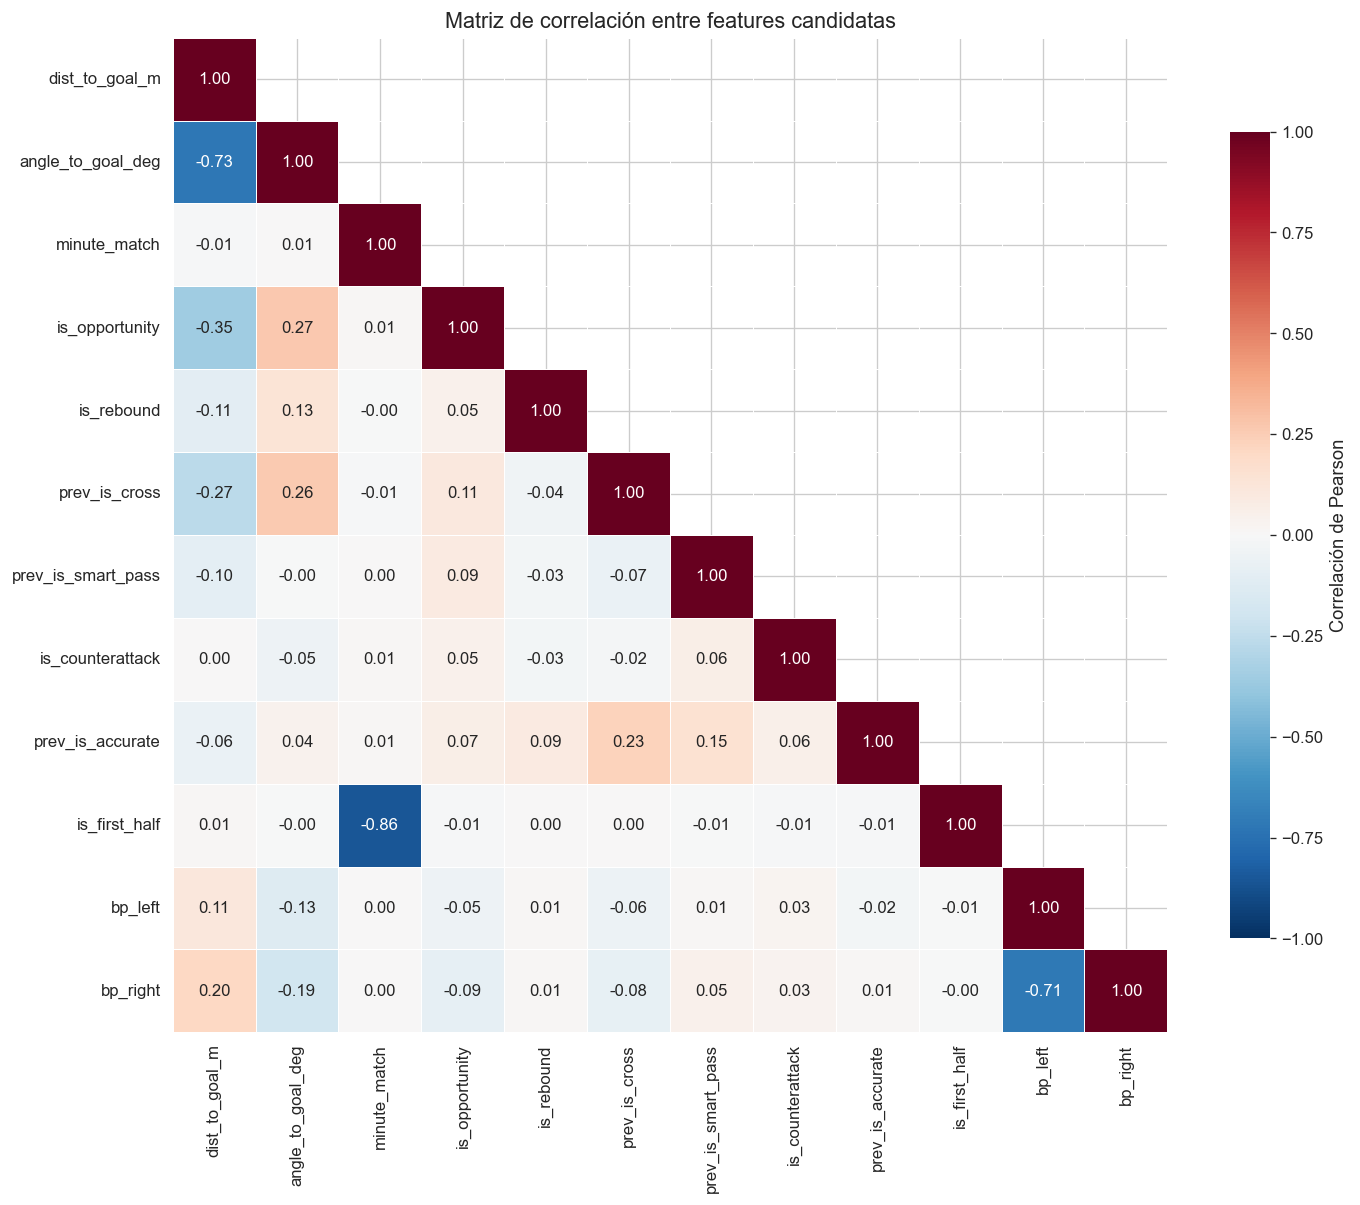

Pares de features con |r| > 0.30:
  dist_to_goal_m            ↔ angle_to_goal_deg          r = -0.725
  dist_to_goal_m            ↔ is_opportunity             r = -0.353
  minute_match              ↔ is_first_half              r = -0.857
  bp_left                   ↔ bp_right                   r = -0.714


In [27]:
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Matriz de correlación entre features candidatas', fontsize=13)
savefig("corr_matrix")
plt.tight_layout()
plt.show()

# Pares con |r| > 0.3 (potencialmente problemáticos)
print("Pares de features con |r| > 0.30:")
print("="*55)
pairs_found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.30:
            print(f"  {corr_matrix.columns[i]:25s} ↔ {corr_matrix.columns[j]:25s}  r = {r:+.3f}")
            pairs_found = True
if not pairs_found:
    print("  Ninguno. Todas las correlaciones inter-feature están por debajo de |0.30|.")

#### 5.3 Variance Inflation Factor (VIF)

Como complemento a la matriz de correlación, se calcula el *Variance Inflation Factor* (VIF) de cada feature candidata. Mientras que la correlación analiza relaciones entre pares de variables, el VIF evalúa la redundancia de cada feature respecto al conjunto completo de predictores.

Esta métrica permite identificar posibles problemas de multicolinealidad que podrían afectar a la estabilidad e interpretabilidad del modelo, especialmente en la regresión logística.

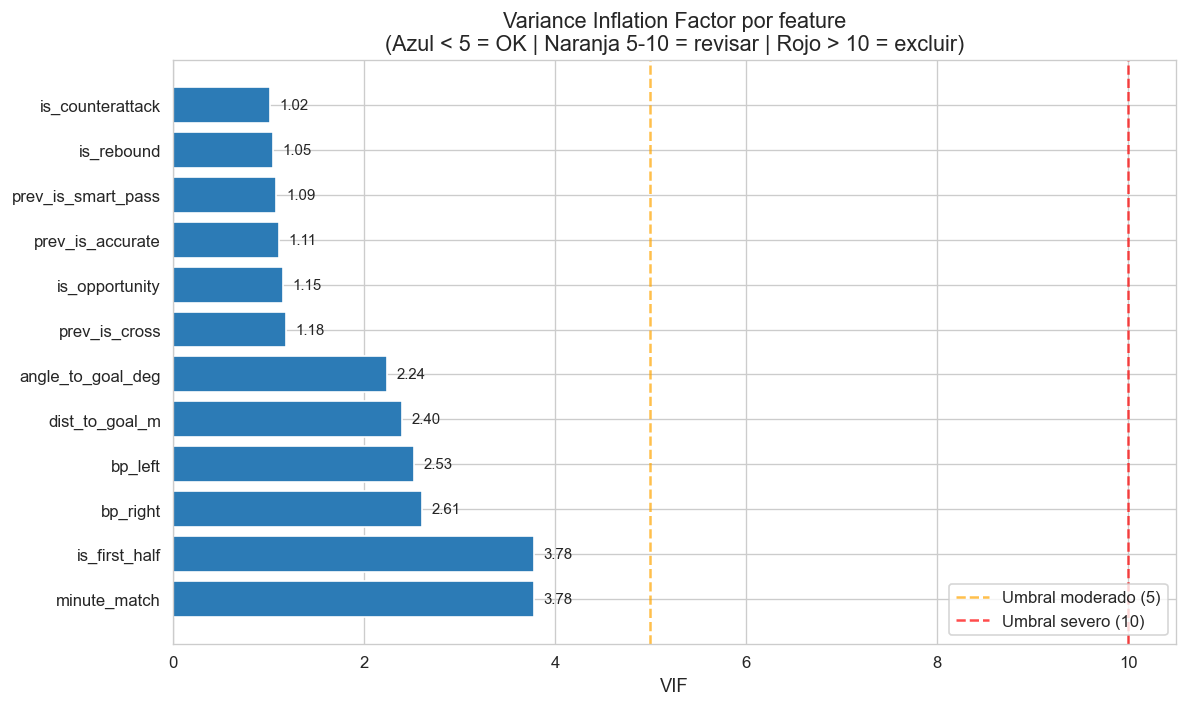

           Feature      VIF
      minute_match 3.778182
     is_first_half 3.777744
          bp_right 2.612080
           bp_left 2.526958
    dist_to_goal_m 2.403382
 angle_to_goal_deg 2.240276
     prev_is_cross 1.184605
    is_opportunity 1.154954
  prev_is_accurate 1.107927
prev_is_smart_pass 1.085683
        is_rebound 1.051009
  is_counterattack 1.019888


In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

# Convertir todo a float64 y eliminar posibles NaN
df_corr_clean = df_corr.astype(np.float64).dropna()

df_vif = add_constant(df_corr_clean)

vif_data = pd.DataFrame({
    'Feature': df_corr_clean.columns,
    'VIF': [variance_inflation_factor(df_vif.values, i+1) 
            for i in range(len(df_corr_clean.columns))]
}).sort_values('VIF', ascending=False)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))

colors_vif = ['#d73027' if v > 10 else '#fdae61' if v > 5 else '#2c7bb6' 
              for v in vif_data['VIF']]

bars = ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors_vif, edgecolor='white')
ax.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Umbral moderado (5)')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='Umbral severo (10)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor por feature\n'
             '(Azul < 5 = OK | Naranja 5-10 = revisar | Rojo > 10 = excluir)')
ax.legend(loc='lower right')

for bar, val in zip(bars, vif_data['VIF']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

savefig("vif")
plt.tight_layout()
plt.show()

print(vif_data.to_string(index=False))

#### 5.4 Correlación de las features con la variable objetivo

Finalmente, se analiza la correlación individual de cada feature con la variable objetivo (`is_goal`) con el fin de complementar el análisis de multicolinealidad realizado mediante VIF.

Esta comparación permite distinguir entre variables potencialmente redundantes pero útiles desde el punto de vista predictivo y variables cuya contribución es limitada tanto en términos de asociación con el target como de interpretabilidad.

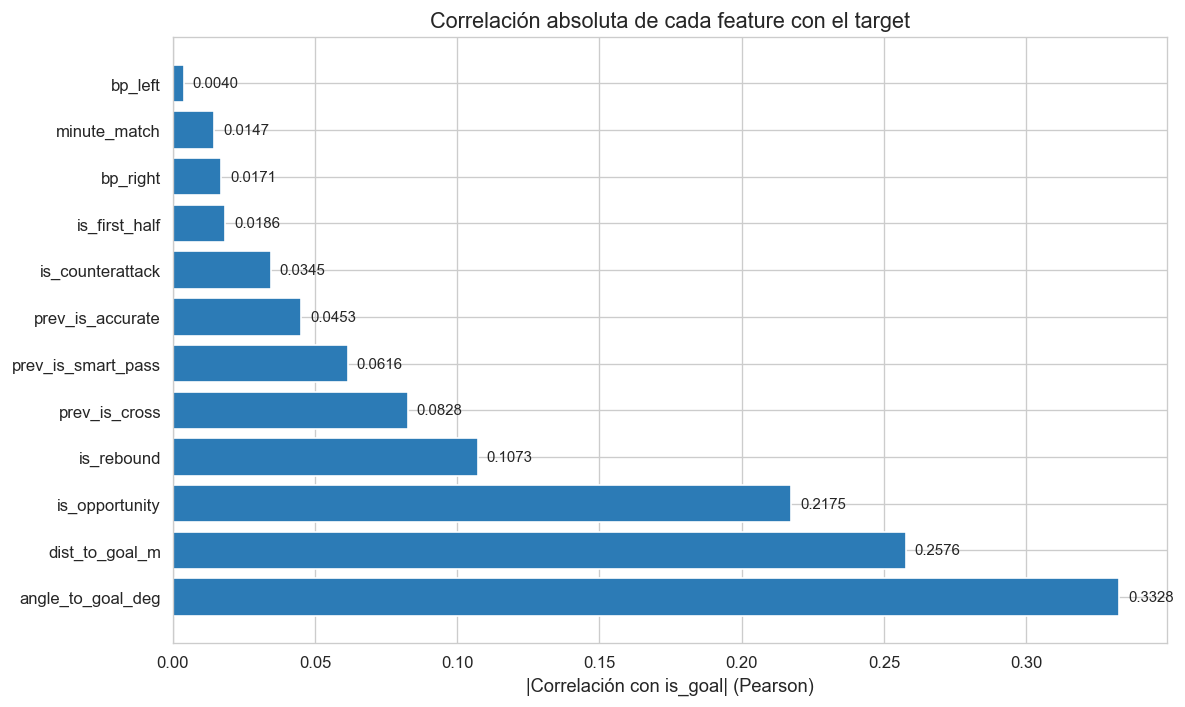

In [29]:
target_corr = df_corr.corrwith(df_shots['target']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(target_corr.index, target_corr.values, color='#2c7bb6', edgecolor='white')
ax.set_xlabel('|Correlación con is_goal| (Pearson)')
ax.set_title('Correlación absoluta de cada feature con el target')

for bar, val in zip(bars, target_corr.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### 5.5 Selección final de features

Tras el análisis de asociación con la variable objetivo y la evaluación de multicolinealidad, se define el conjunto final de variables utilizadas para el entrenamiento del modelo xG.

La selección combina criterios estadísticos y conocimiento de dominio futbolístico, priorizando features con capacidad predictiva relevante, baja redundancia y una interpretación coherente dentro del contexto del juego.

Las variables excluidas corresponden principalmente a tres casos:
- features sin presencia efectiva en el dataset público,
- variables redundantes respecto a otras features espaciales,
- o variables con contribución predictiva prácticamente nula.

In [30]:
FEATURES_FINAL = {
    'continuous': ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match'],
    'binary': [
        'is_opportunity',
        'is_rebound',
        'prev_is_cross',
        'prev_is_smart_pass',
        'is_counterattack',
        'prev_is_accurate',
    ],
    'categorical': ['body_part'],
}

n_features = (len(FEATURES_FINAL['continuous']) + 
              len(FEATURES_FINAL['binary']) + 
              2)  # body_part genera 2 dummies

print("SET FINAL DE FEATURES PARA EL MODELO xG")
print("="*55)
print(f"\nTotal: {n_features} features ({len(FEATURES_FINAL['continuous'])} continuas + "
      f"{len(FEATURES_FINAL['binary'])} binarias + 2 dummies de body_part)")

print(f"\n── Continuas ({len(FEATURES_FINAL['continuous'])}) ──")
for f in FEATURES_FINAL['continuous']:
    print(f"  {f}")

print(f"\n── Binarias ({len(FEATURES_FINAL['binary'])}) ──")
for f in FEATURES_FINAL['binary']:
    print(f"  {f}")

print(f"\n── Categóricas ({len(FEATURES_FINAL['categorical'])}) ──")
for f in FEATURES_FINAL['categorical']:
    print(f"  {f} → dummies: bp_head_body, bp_left (ref: right)")

print(f"\n── Excluidas ──")
excluded = [
    ('is_first_half', 'Redundante con minute_match (r = −0.857, VIF = 3.78)'),
    ('prev_same_team', 'No significativo (p=0.028), redundante con is_rebound'),
    ('prev_is_through_ball', 'Prevalencia 0 en dataset público'),
    ('is_direct', 'Prevalencia 0 en dataset público'),
    ('is_free_space', 'Prevalencia 0 en dataset público'),
    ('x_m', 'Redundante con dist_to_goal_m (r = −0.976, EDA sección 5)'),
    ('y_m', 'Capturada por angle_to_goal_deg'),
    ('zone_x, zone_y', 'Redundantes con dist + ángulo'),
]
for feat, reason in excluded:
    print(f"  {feat:30s}  → {reason}")

SET FINAL DE FEATURES PARA EL MODELO xG

Total: 11 features (3 continuas + 6 binarias + 2 dummies de body_part)

── Continuas (3) ──
  dist_to_goal_m
  angle_to_goal_deg
  minute_match

── Binarias (6) ──
  is_opportunity
  is_rebound
  prev_is_cross
  prev_is_smart_pass
  is_counterattack
  prev_is_accurate

── Categóricas (1) ──
  body_part → dummies: bp_head_body, bp_left (ref: right)

── Excluidas ──
  is_first_half                   → Redundante con minute_match (r = −0.857, VIF = 3.78)
  prev_same_team                  → No significativo (p=0.028), redundante con is_rebound
  prev_is_through_ball            → Prevalencia 0 en dataset público
  is_direct                       → Prevalencia 0 en dataset público
  is_free_space                   → Prevalencia 0 en dataset público
  x_m                             → Redundante con dist_to_goal_m (r = −0.976, EDA sección 5)
  y_m                             → Capturada por angle_to_goal_deg
  zone_x, zone_y                  → Redundan

### Resultados del análisis de multicolinealidad

La matriz de correlación identifica únicamente cuatro pares de variables con correlación absoluta superior a 0.30:

| Par | r | VIF (a / b) | Decisión |
|---|---:|---:|---|
| `dist_to_goal_m` ↔ `angle_to_goal_deg` | −0.725 | 2.35 / 2.22 | Mantener ambas |
| `minute_match` ↔ `is_first_half` | −0.857 | 3.78 / 3.78 | Excluir `is_first_half` |
| `bp_left` ↔ `bp_right` | −0.714 | 2.50 / 2.58 | Correlación estructural |
| `dist_to_goal_m` ↔ `is_opportunity` | −0.353 | 2.35 / 1.15 | Mantener ambas |

#### Distancia y ángulo

Aunque `dist_to_goal_m` y `angle_to_goal_deg` presentan una correlación relativamente alta (\(r = -0.725\)), los valores VIF permanecen bajos (< 5), indicando ausencia de multicolinealidad problemática.

Además, ambas variables capturan componentes geométricos diferentes de la posición del tiro: la distancia mide la lejanía respecto a portería, mientras que el ángulo representa la amplitud visible de remate.

#### Minuto e indicador de primera parte

`is_first_half` presenta una correlación muy elevada con `minute_match`, ya que constituye esencialmente una discretización binaria de la variable temporal continua. Dado que ambas variables muestran una asociación muy débil con el target, se mantiene únicamente `minute_match` por aportar una representación más granular del tiempo de juego.

#### Variables derivadas de `body_part`

La correlación entre las dummies de `body_part` es consecuencia directa del proceso de *one-hot encoding* y no se considera problemática desde el punto de vista de la multicolinealidad.

#### Resultado final

Todas las features presentan valores VIF inferiores a 5, por lo que no se detectan problemas relevantes de multicolinealidad en el conjunto final de variables.

El modelo se entrenará finalmente con 11 features distribuidas en cuatro bloques de información complementaria:

| Bloque | Features |
|---|---|
| Posicional | `dist_to_goal_m`, `angle_to_goal_deg` |
| Contextual | `is_opportunity`, `is_rebound`, `prev_is_cross`, `prev_is_smart_pass`, `is_counterattack`, `prev_is_accurate` |
| Ejecución | `body_part` (2 dummies) |
| Temporal | `minute_match` |

La siguiente sección abordará la preparación final del dataset para el entrenamiento de los modelos.

## 6. Preparación del dataset

En esta sección se transforma el dataset construido y analizado en las secciones anteriores en el conjunto final utilizado para el entrenamiento y evaluación de los modelos.

El proceso incluye tres decisiones metodológicas principales:

1. **Codificación de variables**: aplicación de *one-hot encoding* sobre `body_part` y estandarización de las variables continuas para la regresión logística.

2. **Estrategia de partición**: definición del procedimiento de división entre entrenamiento y test con el objetivo de evaluar el rendimiento del modelo de forma robusta y evitar *data leakage*.

3. **Tratamiento del desbalance de clases**: gestión de la proporción aproximada de 1:8.5 entre goles y no goles, buscando mantener probabilidades calibradas y representativas de la distribución real de eventos.

#### 6.1 Construcción de la matriz de features

Se construye la matriz final de predictores (`X`) a partir del conjunto de features seleccionado en la sección anterior. Las variables continuas y binarias se incorporan directamente, mientras que `body_part` se codifica mediante *one-hot encoding*, tomando el pie derecho como categoría de referencia.

Finalmente, se define la variable objetivo (`y`) y se verifica que la matriz resultante no contenga valores nulos antes de proceder a la partición del dataset.

In [31]:
# One-hot encoding de body_part (referencia: right)
bp_dummies = pd.get_dummies(df_shots['body_part'], prefix='bp', drop_first=False)
# Eliminar 'right' como referencia para evitar trampa de dummies
bp_dummies = bp_dummies.drop(columns=['bp_right'])

# Ensamblar X
X = pd.concat([
    df_shots[FEATURES_FINAL['continuous']],
    df_shots[FEATURES_FINAL['binary']].astype(int),
    bp_dummies.astype(int)
], axis=1)

y = df_shots['target']

# Verificar
print(f"Matriz X: {X.shape[0]:,} filas × {X.shape[1]} features")
print(f"Target y: {y.sum():,} positivos ({y.mean():.1%})")
print(f"\nColumnas de X:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

# Verificar ausencia de nulos
n_nulls = X.isnull().sum().sum()
print(f"\nValores nulos en X: {n_nulls}")

Matriz X: 40,461 filas × 11 features
Target y: 4,271 positivos (10.6%)

Columnas de X:
   1. dist_to_goal_m
   2. angle_to_goal_deg
   3. minute_match
   4. is_opportunity
   5. is_rebound
   6. prev_is_cross
   7. prev_is_smart_pass
   8. is_counterattack
   9. prev_is_accurate
  10. bp_head_body
  11. bp_left

Valores nulos en X: 0


### 6.2 Estrategia de partición: split aleatorio estratificado

Se consideraron tres estrategias principales de partición del dataset:

| Estrategia | Ventaja | Limitación |
|---|---|---|
| Aleatorio estratificado 80/20 | Máxima representatividad de ligas y contextos en ambos conjuntos | No evalúa generalización temporal |
| Por competición (*leave-one-league-out*) | Evalúa transferencia entre ligas | Reduce significativamente el tamaño de entrenamiento |
| Temporal (1ª vuelta / 2ª vuelta) | Simula predicción sobre datos futuros | Posible sesgo estacional y menor tamaño muestral |

#### Decisión adoptada

Se utiliza un **split aleatorio estratificado 80/20**, complementado posteriormente con una validación *leave-one-league-out* como análisis adicional de robustez (sección 9a).

#### Justificación

Dado que el dataset contiene únicamente una temporada (2017/18), un split temporal reduciría considerablemente el tamaño del conjunto de entrenamiento e introduciría posibles efectos estacionales asociados a fatiga, rotaciones o mercado de invierno.

Por otro lado, las diferencias observadas entre ligas son relativamente reducidas (sección 2: rango de conversión entre 9.7% y 11.1%), por lo que una separación estricta por competición penalizaría innecesariamente la capacidad de aprendizaje del modelo.

El split aleatorio estratificado maximiza la representatividad estadística en entrenamiento y test, manteniendo además la proporción original de goles y no goles (~10.6%) en ambos conjuntos.

#### 6.3 Partición train/test estratificada

El dataset se divide en un conjunto de entrenamiento (80%) y un conjunto de test (20%) utilizando un muestreo aleatorio estratificado. La estratificación garantiza que la proporción de goles y no goles se mantenga prácticamente constante en ambos subconjuntos.

Posteriormente, se verifica que las tasas de conversión en entrenamiento y test sean equivalentes, asegurando que ambos conjuntos representan adecuadamente la distribución original del problema.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Preservar proporción de goles
)

print("SPLIT TRAIN / TEST")
print("="*55)
print(f"  Train: {len(X_train):>7,} tiros  |  {y_train.sum():>5,} goles ({y_train.mean():.1%})")
print(f"  Test:  {len(X_test):>7,} tiros  |  {y_test.sum():>5,} goles ({y_test.mean():.1%})")
print(f"  Total: {len(X):>7,} tiros  |  {y.sum():>5,} goles ({y.mean():.1%})")

# Verificar estratificación
print(f"\n  Verificación de estratificación:")
print(f"    Tasa gol train: {y_train.mean():.4f}")
print(f"    Tasa gol test:  {y_test.mean():.4f}")
print(f"    Diferencia:     {abs(y_train.mean() - y_test.mean()):.4f}")

SPLIT TRAIN / TEST
  Train:  32,368 tiros  |  3,417 goles (10.6%)
  Test:    8,093 tiros  |    854 goles (10.6%)
  Total:  40,461 tiros  |  4,271 goles (10.6%)

  Verificación de estratificación:
    Tasa gol train: 0.1056
    Tasa gol test:  0.1055
    Diferencia:     0.0000


#### 6.4 Estandarización de variables continuas

Las variables continuas se estandarizan mediante `StandardScaler`, transformándolas a media 0 y desviación estándar 1. Este paso es especialmente importante para la regresión logística, ya que sus coeficientes son sensibles a la escala de las variables de entrada.

El escalado se ajusta exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplica tanto a train como a test, evitando así problemas de *data leakage*. Aunque XGBoost no requiere estandarización debido a su naturaleza basada en árboles, se mantiene el mismo preprocesamiento para facilitar la comparabilidad entre modelos.

In [33]:
# Se usa StandardScaler ajustado SOLO sobre train (evitar data leakage)
scaler = StandardScaler()

# Features continuas
cols_to_scale = FEATURES_FINAL['continuous']

# Fit sobre train, transform sobre train y test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Estandarización (fit en train, transform en train+test):")
print(f"  Features escaladas: {cols_to_scale}")
print(f"\n  Media en train (post-scaling):  {X_train_scaled[cols_to_scale].mean().round(6).to_dict()}")
print(f"  Std en train (post-scaling):   {X_train_scaled[cols_to_scale].std().round(4).to_dict()}")
print(f"\n  Media en test (post-scaling):  {X_test_scaled[cols_to_scale].mean().round(4).to_dict()}")
print(f"  ✅ Data leakage evitado: scaler ajustado solo sobre train")

Estandarización (fit en train, transform en train+test):
  Features escaladas: ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match']

  Media en train (post-scaling):  {'dist_to_goal_m': -0.0, 'angle_to_goal_deg': 0.0, 'minute_match': 0.0}
  Std en train (post-scaling):   {'dist_to_goal_m': 1.0, 'angle_to_goal_deg': 1.0, 'minute_match': 1.0}

  Media en test (post-scaling):  {'dist_to_goal_m': -0.0207, 'angle_to_goal_deg': 0.0038, 'minute_match': -0.0079}
  ✅ Data leakage evitado: scaler ajustado solo sobre train


### 6.5 Gestión del desbalance de clases

El dataset presenta un desbalance aproximado de 1:8.5 entre goles y no goles. Esta distribución refleja la propia naturaleza del fútbol, donde la mayoría de los tiros no terminan en gol, y no un problema derivado del proceso de muestreo.

#### Decisión metodológica

No se aplican técnicas de *oversampling*, *SMOTE* ni reponderación de clases durante el entrenamiento.

El objetivo principal del modelo xG no es maximizar accuracy, sino estimar probabilidades calibradas. En otras palabras, si el modelo asigna un valor xG de 0.15 a un conjunto de tiros, se espera que aproximadamente el 15% de ellos terminen en gol.

Modificar artificialmente la distribución de clases puede alterar la prevalencia real de goles durante el entrenamiento y afectar negativamente a la calibración de las probabilidades predichas, especialmente en métricas como log-loss o Brier score.

#### Estrategia adoptada

| Modelo | Tratamiento del desbalance |
|---|---|
| Regresión Logística | Sin ajuste de clases |
| XGBoost | Sin `scale_pos_weight` |

En ambos casos, el número absoluto de ejemplos positivos (~3.400 goles en entrenamiento) se considera suficiente para que los modelos aprendan patrones discriminativos sin necesidad de técnicas adicionales de balanceo.

#### Métrica principal de evaluación

La métrica principal utilizada será **log-loss**, ya que evalúa simultáneamente capacidad predictiva y calibración probabilística. A diferencia del accuracy, esta métrica penaliza fuertemente las predicciones sobreconfiadas o mal calibradas.

#### 6.6 Cálculo de `scale_pos_weight`

Aunque finalmente no se utilizará reponderación de clases en el entrenamiento de XGBoost, se calcula el parámetro `scale_pos_weight` como referencia descriptiva del nivel de desbalance presente en el conjunto de entrenamiento.

Este parámetro representa la proporción entre ejemplos negativos y positivos, y suele emplearse en problemas de clasificación desbalanceada para aumentar el peso de la clase minoritaria durante el entrenamiento.

Finalmente, se resumen los distintos datasets preparados para el modelado, diferenciando entre las versiones originales y las versiones estandarizadas utilizadas por la regresión logística.

In [34]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print("GESTIÓN DEL DESBALANCE")
print("="*55)
print(f"  Train negatives (no gol): {n_neg:,}")
print(f"  Train positives (gol):    {n_pos:,}")
print(f"  Ratio:                    1:{n_neg/n_pos:.1f}")
print(f"  scale_pos_weight:         {scale_pos_weight:.2f}")

# Resumen de datasets disponibles para modelado
print(f"\n{'='*55}")
print(f"  DATASETS LISTOS PARA MODELADO")
print(f"{'='*55}")
print(f"  X_train / y_train:         {X_train.shape[0]:,} × {X_train.shape[1]}")
print(f"  X_test  / y_test:          {X_test.shape[0]:,} × {X_test.shape[1]}")
print(f"  X_train_scaled (LogReg):   {X_train_scaled.shape[0]:,} × {X_train_scaled.shape[1]}")
print(f"  X_test_scaled  (LogReg):   {X_test_scaled.shape[0]:,} × {X_test_scaled.shape[1]}")
print(f"  scale_pos_weight (XGBoost): {scale_pos_weight:.2f}")

GESTIÓN DEL DESBALANCE
  Train negatives (no gol): 28,951
  Train positives (gol):    3,417
  Ratio:                    1:8.5
  scale_pos_weight:         8.47

  DATASETS LISTOS PARA MODELADO
  X_train / y_train:         32,368 × 11
  X_test  / y_test:          8,093 × 11
  X_train_scaled (LogReg):   32,368 × 11
  X_test_scaled  (LogReg):   8,093 × 11
  scale_pos_weight (XGBoost): 8.47


#### 6.7 Baseline trivial

Antes de entrenar los modelos, se establece una baseline de referencia consistente en predecir siempre la tasa media de gol observada en el conjunto de entrenamiento.

Esta baseline representa el rendimiento mínimo que cualquier modelo debe superar para aportar capacidad predictiva real. Además, permite contextualizar la interpretación de las métricas de evaluación utilizadas posteriormente.

Debido al fuerte desbalance del dataset, un clasificador trivial que prediga siempre “no gol” alcanza un accuracy cercano al 89%, lo que confirma que esta métrica resulta poco informativa en problemas de predicción xG. Por este motivo, la evaluación se centrará principalmente en métricas probabilísticas como log-loss y Brier score.

In [35]:
y_pred_trivial = np.full(len(y_test), y_train.mean())  # Predecir siempre la tasa base

ll_trivial = log_loss(y_test, y_pred_trivial)
brier_trivial = brier_score_loss(y_test, y_pred_trivial)
acc_trivial = (y_test == 0).mean()  # Siempre predice "no gol"

print("BASELINE TRIVIAL: predecir siempre la tasa base")
print("="*55)
print(f"  Predicción constante:  {y_train.mean():.4f} (tasa de gol en train)")
print(f"  Log-loss:              {ll_trivial:.4f}")
print(f"  Brier score:           {brier_trivial:.4f}")
print(f"  Accuracy (si pred=0):  {acc_trivial:.1%}  ← inútil como métrica")
print(f"\n  Todo modelo debe superar log-loss = {ll_trivial:.4f}")
print(f"  Si no lo supera, no aporta información sobre la base rate.")

BASELINE TRIVIAL: predecir siempre la tasa base
  Predicción constante:  0.1056 (tasa de gol en train)
  Log-loss:              0.3371
  Brier score:           0.0944
  Accuracy (si pred=0):  89.4%  ← inútil como métrica

  Todo modelo debe superar log-loss = 0.3371
  Si no lo supera, no aporta información sobre la base rate.


## 7. Baseline: Regresión Logística

La regresión logística constituye el modelo de referencia más utilizado en la literatura de *expected goals* (xG). Su principal ventaja es la interpretabilidad, ya que los coeficientes estimados pueden analizarse directamente en términos de contribución relativa sobre la probabilidad de gol.

Además, este modelo permite verificar si las relaciones aprendidas son coherentes con el conocimiento futbolístico esperado, por ejemplo: mayor distancia implica menor probabilidad de gol, mientras que un mayor ángulo visible incrementa la probabilidad de conversión.

Con el objetivo de evaluar el impacto incremental de cada bloque de variables, se entrenan tres variantes de complejidad creciente:

| Variante | Features | Objetivo |
|---|---|---|
| LR1 — Geométrico | `dist_to_goal_m` + `angle_to_goal_deg` | Replicar el baseline espacial clásico utilizado en gran parte de la literatura |
| LR2 — Tier 1 | + `is_opportunity`, `body_part`, `is_counterattack`, `minute_match` | Evaluar la contribución de variables contextuales, temporales y de ejecución |
| LR3 — Completo | + `is_rebound`, `prev_is_cross`, `prev_is_smart_pass`, `prev_is_accurate` | Evaluar el impacto de las features derivadas del evento previo |

Esta progresión permite cuantificar la aportación incremental de cada bloque de información y evaluar empíricamente el valor del proceso de *feature engineering* desarrollado en las secciones anteriores.

#### 7.1 Definición de las variantes de regresión logística

Se definen tres configuraciones de regresión logística con complejidad creciente para evaluar la contribución incremental de cada bloque de features. Esta estrategia permite comparar directamente cuánto mejora el modelo al incorporar información contextual y de secuencia respecto al baseline geométrico tradicional utilizado en la literatura xG.

In [36]:
# Variante 1: baseline espacial clásico de la literatura xG
features_lr1 = ['dist_to_goal_m', 'angle_to_goal_deg']

# Variante 2: Tier 1 (features espaciales + contexto + ejecución + tiempo)
features_lr2 = ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match',
                'is_opportunity', 'is_counterattack',
                'bp_head_body', 'bp_left']

# Variante 3: Tier 1 + Tier 2 (modelo completo con evento previo)
features_lr3 = [
    'dist_to_goal_m',
    'angle_to_goal_deg',
    'minute_match',
    'is_opportunity',
    'is_rebound',
    'prev_is_cross',
    'prev_is_smart_pass',
    'is_counterattack',
    'prev_is_accurate',
    'bp_head_body',
    'bp_left'
]

print("Variantes de Regresión Logística:")
print(f"  LR1 (Geométrico):  {len(features_lr1)} features  → {features_lr1}")
print(f"  LR2 (Tier 1):      {len(features_lr2)} features  → {features_lr2}")
print(f"  LR3 (Completo):    {len(features_lr3)} features  → {features_lr3}")

Variantes de Regresión Logística:
  LR1 (Geométrico):  2 features  → ['dist_to_goal_m', 'angle_to_goal_deg']
  LR2 (Tier 1):      7 features  → ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match', 'is_opportunity', 'is_counterattack', 'bp_head_body', 'bp_left']
  LR3 (Completo):    11 features  → ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match', 'is_opportunity', 'is_rebound', 'prev_is_cross', 'prev_is_smart_pass', 'is_counterattack', 'prev_is_accurate', 'bp_head_body', 'bp_left']


#### 7.2 Entrenamiento de las variantes

Se entrenan las tres variantes de LR utilizando el mismo conjunto de entrenamiento y la misma configuración del modelo. Para cada variante se calculan probabilidades de gol sobre train y test, permitiendo comparar rendimiento y posible sobreajuste.

La evaluación se realiza mediante métricas probabilísticas como log-loss y Brier score, complementadas con AUC para medir la capacidad discriminativa del modelo.

In [37]:
from sklearn.linear_model import LogisticRegression

results_lr = {}

for name, feats in [('LR1_geometric', features_lr1), 
                     ('LR2_tier1', features_lr2), 
                     ('LR3_complete', features_lr3)]:
    
    lr = LogisticRegression(
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    )
    
    lr.fit(X_train_scaled[feats], y_train)
    
    y_prob_train = lr.predict_proba(X_train_scaled[feats])[:, 1]
    y_prob_test = lr.predict_proba(X_test_scaled[feats])[:, 1]
    
    results_lr[name] = {
        'model': lr,
        'features': feats,
        'y_prob_train': y_prob_train,
        'y_prob_test': y_prob_test,
        'log_loss_train': log_loss(y_train, y_prob_train),
        'log_loss_test': log_loss(y_test, y_prob_test),
        'brier_train': brier_score_loss(y_train, y_prob_train),
        'brier_test': brier_score_loss(y_test, y_prob_test),
        'auc_train': roc_auc_score(y_train, y_prob_train),
        'auc_test': roc_auc_score(y_test, y_prob_test),
    }

# Tabla comparativa
print("COMPARACIÓN DE VARIANTES — REGRESIÓN LOGÍSTICA")
print("="*75)
print(f"{'Modelo':<18} {'Features':>3}  {'LogLoss train':>13} {'LogLoss test':>13} "
      f"{'AUC test':>9} {'Brier test':>11}")
print("-"*75)
print(f"{'Trivial (media)':<18} {'—':>3}  {'—':>13} {ll_trivial:>13.4f} "
      f"{'0.5000':>9} {brier_trivial:>11.4f}")

for name, res in results_lr.items():
    print(f"{name:<18} {len(res['features']):>3}  {res['log_loss_train']:>13.4f} "
          f"{res['log_loss_test']:>13.4f} {res['auc_test']:>9.4f} {res['brier_test']:>11.4f}")

COMPARACIÓN DE VARIANTES — REGRESIÓN LOGÍSTICA
Modelo             Features  LogLoss train  LogLoss test  AUC test  Brier test
---------------------------------------------------------------------------
Trivial (media)      —              —        0.3371    0.5000      0.0944
LR1_geometric        2         0.2913        0.2914    0.7609      0.0839
LR2_tier1            7         0.2651        0.2658    0.8237      0.0797
LR3_complete        11         0.2640        0.2659    0.8233      0.0797


#### 7.3 Interpretación de coeficientes y *odds ratios*

Una de las principales ventajas de la regresión logística es su interpretabilidad. Al entrenarse sobre variables estandarizadas, los coeficientes estimados son directamente comparables entre features: cuanto mayor es su magnitud absoluta, mayor es su influencia sobre las *log-odds* de gol, manteniendo constantes el resto de variables.

Además de los coeficientes, se calculan los correspondientes *odds ratios* (\(e^\beta\)), que permiten interpretar el efecto multiplicativo de cada feature sobre la probabilidad de gol. Valores superiores a 1 indican un incremento de la probabilidad de conversión, mientras que valores inferiores a 1 indican una reducción.

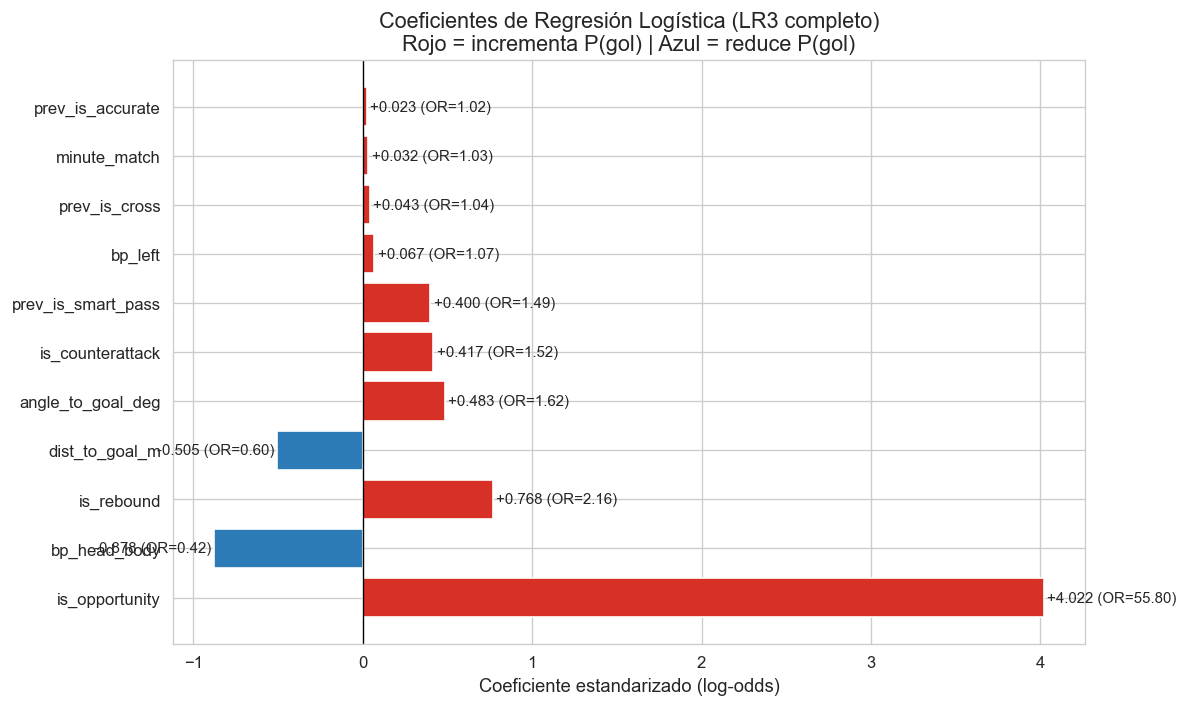


Interpretación de Odds Ratios:
  OR > 1: la feature INCREMENTA la probabilidad de gol
  OR < 1: la feature REDUCE la probabilidad de gol
  OR = 1: sin efecto

           Feature  Coeficiente  Odds Ratio
    is_opportunity     4.021788   55.800788
      bp_head_body    -0.877717    0.415731
        is_rebound     0.768086    2.155635
    dist_to_goal_m    -0.504935    0.603545
 angle_to_goal_deg     0.482784    1.620580
  is_counterattack     0.416723    1.516982
prev_is_smart_pass     0.399529    1.491123
           bp_left     0.066873    1.069159
     prev_is_cross     0.042513    1.043430
      minute_match     0.032280    1.032806
  prev_is_accurate     0.023065    1.023333


In [38]:
lr3 = results_lr['LR3_complete']['model']
coef_df = pd.DataFrame({
    'Feature': features_lr3,
    'Coeficiente': lr3.coef_[0],
    '|Coeficiente|': np.abs(lr3.coef_[0]),
    'Odds Ratio': np.exp(lr3.coef_[0])
}).sort_values('|Coeficiente|', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors_coef = ['#d73027' if c > 0 else '#2c7bb6' for c in coef_df['Coeficiente']]

ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors_coef, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente estandarizado (log-odds)')
ax.set_title('Coeficientes de Regresión Logística (LR3 completo)\n'
             'Rojo = incrementa P(gol) | Azul = reduce P(gol)')

for bar, val, odds in zip(ax.patches, coef_df['Coeficiente'], coef_df['Odds Ratio']):
    x_pos = bar.get_width() + 0.02 if bar.get_width() >= 0 else bar.get_width() - 0.02
    ha = 'left' if bar.get_width() >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f} (OR={odds:.2f})', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

print("\nInterpretación de Odds Ratios:")
print("  OR > 1: la feature INCREMENTA la probabilidad de gol")
print("  OR < 1: la feature REDUCE la probabilidad de gol")
print("  OR = 1: sin efecto")
print()
print(coef_df[['Feature', 'Coeficiente', 'Odds Ratio']].to_string(index=False))

#### 7.4 Curvas ROC comparativas

Se comparan las curvas ROC de las tres variantes de regresión logística con el objetivo de evaluar cómo evoluciona la capacidad discriminativa del modelo al incorporar nuevos bloques de features.

El área bajo la curva (AUC) mide la capacidad del modelo para distinguir entre goles y no goles independientemente del umbral de clasificación. Valores próximos a 0.5 indican rendimiento aleatorio, mientras que valores cercanos a 1 representan separación perfecta entre clases.

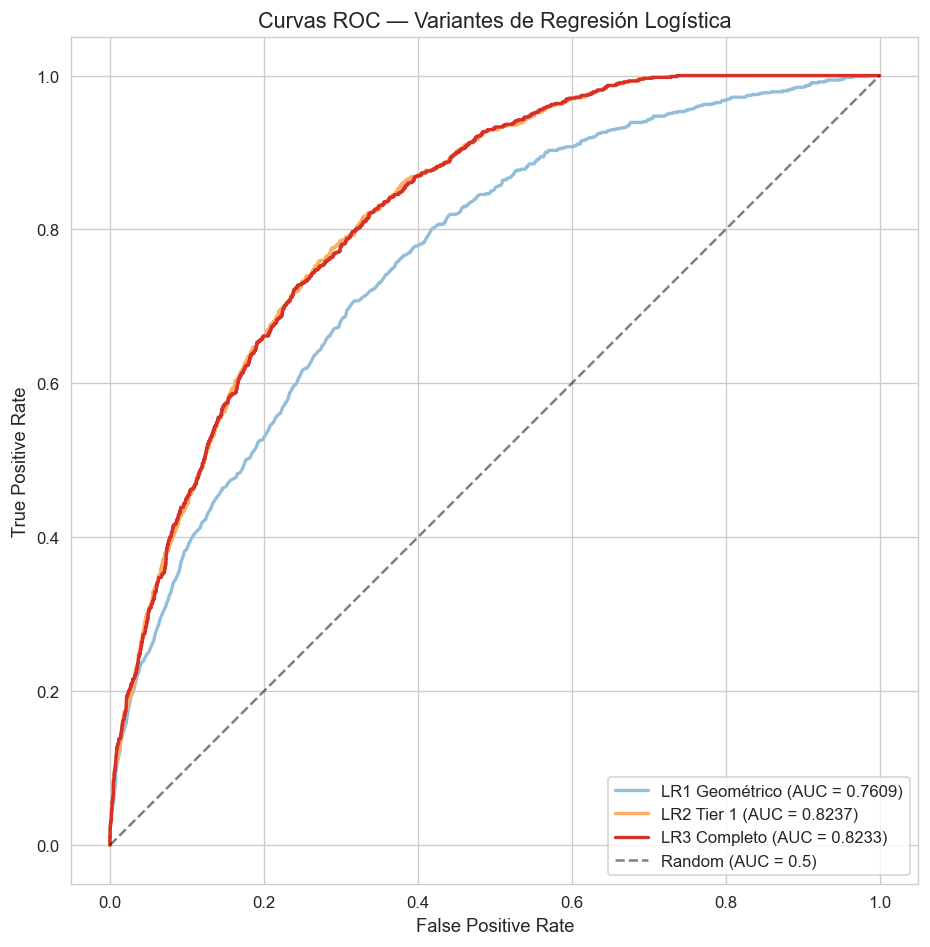

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))

colors_roc = {'LR1_geometric': '#91bfdb', 'LR2_tier1': '#fdae61', 'LR3_complete': '#d73027'}
labels_roc = {'LR1_geometric': 'LR1 Geométrico', 'LR2_tier1': 'LR2 Tier 1', 
              'LR3_complete': 'LR3 Completo'}

for name, res in results_lr.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob_test'])
    ax.plot(fpr, tpr, color=colors_roc[name], linewidth=2,
            label=f"{labels_roc[name]} (AUC = {res['auc_test']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Variantes de Regresión Logística')
ax.legend(loc='lower right')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

#### 7.5 Calibration plot: fiabilidad de las probabilidades predichas

Además de discriminar correctamente entre goles y no goles, un modelo xG debe producir probabilidades bien calibradas. Esto implica que, para todos los tiros a los que el modelo asigna una probabilidad \(p\), aproximadamente una proporción \(p\) de ellos debería terminar en gol.

El *calibration plot* compara las probabilidades predichas por cada modelo con las frecuencias reales observadas en el conjunto de test. Cuanto más próximos se sitúen los puntos respecto a la diagonal, mejor calibradas estarán las predicciones del modelo.

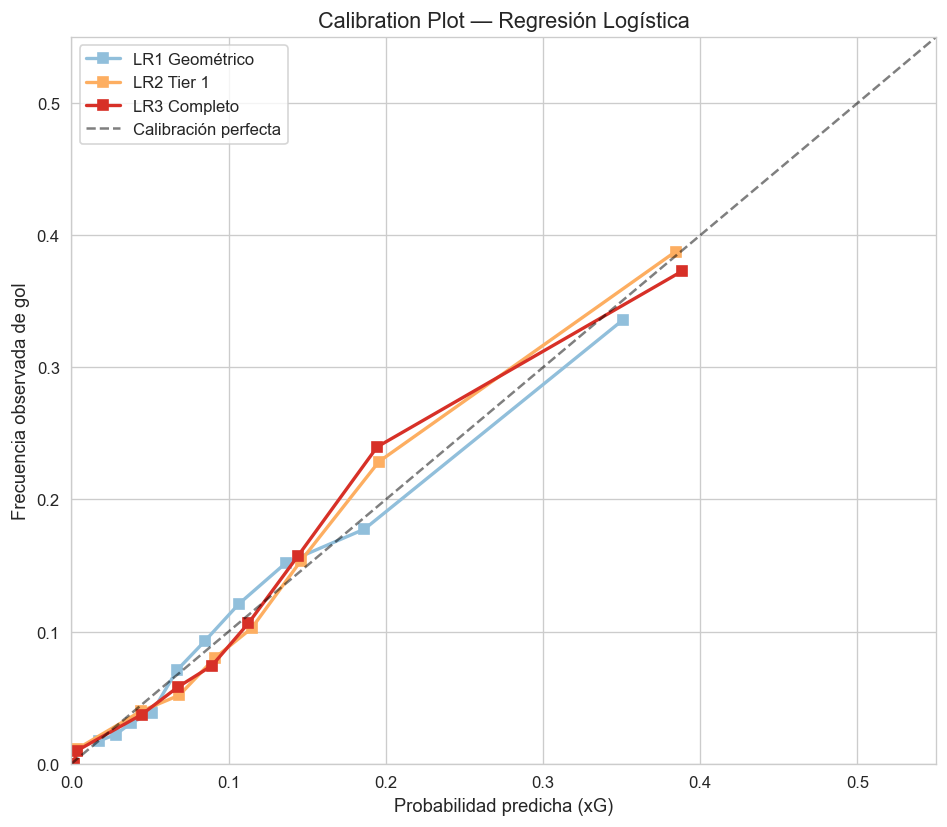

In [40]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, res in results_lr.items():
    prob_true, prob_pred = calibration_curve(
        y_test, res['y_prob_test'], n_bins=10, strategy='quantile'
    )
    ax.plot(prob_pred, prob_true, 's-', color=colors_roc[name],
            linewidth=2, markersize=6, label=labels_roc[name])

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibración perfecta')
ax.set_xlabel('Probabilidad predicha (xG)')
ax.set_ylabel('Frecuencia observada de gol')
ax.set_title('Calibration Plot — Regresión Logística')
ax.legend(loc='upper left')
ax.set_xlim(0, 0.55)
ax.set_ylim(0, 0.55)

plt.tight_layout()
plt.show()

#### 7.6 Relación entre xG predicho y distancia al gol

Como validación adicional, se compara la probabilidad de gol predicha por el modelo con la frecuencia real de conversión observada según la distancia al gol.

Esta visualización permite comprobar si el modelo reproduce correctamente el patrón espacial más robusto de la literatura xG: el decaimiento progresivo de la probabilidad de gol a medida que aumenta la distancia del disparo. Una buena correspondencia entre ambas curvas sugiere que el modelo captura adecuadamente la relación funcional entre distancia y probabilidad de conversión.

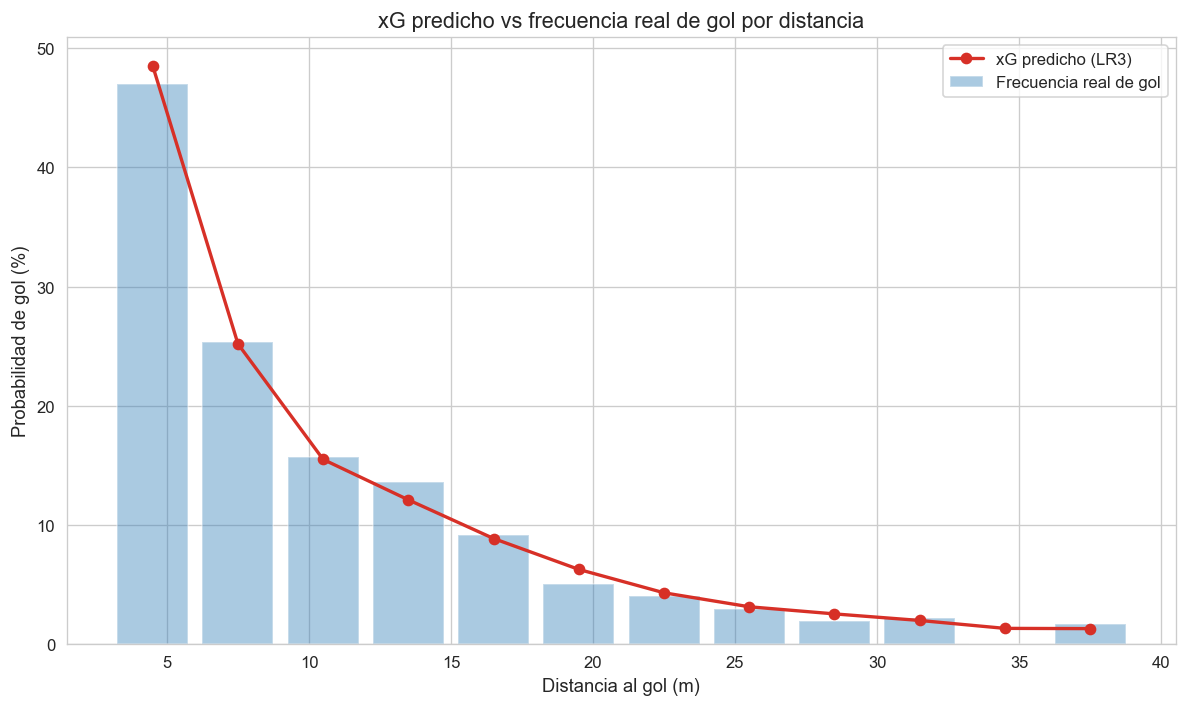

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

# xG predicho vs distancia (LR3 completo) — binneado
df_test_plot = pd.DataFrame({
    'dist': X_test['dist_to_goal_m'].values,
    'xg': results_lr['LR3_complete']['y_prob_test'],
    'goal': y_test.values
})

bins = np.arange(0, 50, 3)
df_test_plot['dist_bin'] = pd.cut(df_test_plot['dist'], bins=bins)

agg = df_test_plot.groupby('dist_bin', observed=True).agg(
    xg_mean=('xg', 'mean'),
    goal_rate=('goal', 'mean'),
    n=('goal', 'count')
)
agg['mid'] = [interval.mid for interval in agg.index]
agg = agg[agg['n'] >= 30]

ax.bar(agg['mid'], agg['goal_rate'] * 100, width=2.5, alpha=0.4,
       color='#2c7bb6', label='Frecuencia real de gol', edgecolor='white')
ax.plot(agg['mid'], agg['xg_mean'] * 100, 'o-', color='#d73027',
        linewidth=2, markersize=6, label='xG predicho (LR3)')

ax.set_xlabel('Distancia al gol (m)')
ax.set_ylabel('Probabilidad de gol (%)')
ax.set_title('xG predicho vs frecuencia real de gol por distancia')
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de la Regresión Logística

#### Progresión de complejidad — contribución marginal de cada bloque

| Modelo | Features | Log-loss test | AUC test | Δ Log-loss | Δ AUC |
|---|---|---:|---:|---:|---:|
| Trivial | — | 0.3371 | 0.5000 | — | — |
| LR1 (Geométrico) | 2 | 0.2914 | 0.7609 | −0.0457 | +0.2609 |
| LR2 (Tier 1) | 7 | 0.2658 | 0.8237 | −0.0256 | +0.0628 |
| LR3 (Completo) | 11 | 0.2659 | 0.8232 | +0.0001 | −0.0005 |

La progresión muestra dos resultados principales:

1. **El mayor salto de rendimiento se produce entre LR1 y LR2**, donde el log-loss mejora en 0.026 puntos y el AUC aumenta más de 0.06. Esto indica que las variables adicionales de contexto, ejecución y tiempo aportan información relevante más allá de la posición espacial del disparo.

2. **Las features Tier 2 aportan una mejora prácticamente nula en la regresión logística** (LR2 ≈ LR3). Este resultado sugiere que un modelo lineal tiene dificultades para capturar las interacciones complejas entre el contexto previo de la jugada y la localización del tiro.

Por ejemplo, un rebote cerca de portería representa una situación ofensiva muy distinta a un rebote lejano, pero la regresión logística únicamente modela efectos aditivos sobre el logit. Esta limitación motiva el uso posterior de XGBoost como modelo capaz de capturar relaciones no lineales e interacciones entre variables.

---

#### Coeficientes y *odds ratios* — hallazgos principales

| Feature | Coeficiente | OR | Interpretación |
|---|---:|---:|---|
| `is_opportunity` | +4.026 | 56.04 | Feature dominante. Su enorme tamaño del efecto sugiere que esta etiqueta encapsula información contextual muy relevante sobre la calidad real de la ocasión. |
| `bp_head_body` | −0.877 | 0.42 | Controlando por distancia y ángulo, los remates de cabeza presentan menores odds de gol que los realizados con el pie. |
| `is_rebound` | +0.769 | 2.16 | Los rebotes más que duplican las odds de gol, coherente con situaciones donde el portero queda fuera de posición. |
| `dist_to_goal_m` | −0.505 | 0.60 | Cada desviación estándar adicional de distancia reduce aproximadamente un 40% las odds de gol. |
| `angle_to_goal_deg` | +0.483 | 1.62 | Un mayor ángulo visible incrementa significativamente las odds de conversión. |
| `is_counterattack` | +0.418 | 1.52 | Los contraataques generan situaciones ofensivas con mayor probabilidad de gol. |
| `prev_is_smart_pass` | +0.402 | 1.49 | Los pases creativos previos al disparo aumentan de forma clara las odds de conversión. |
| `prev_is_cross` | +0.045 | 1.05 | El efecto positivo observado en el análisis bivariado se reduce notablemente al controlar por variables espaciales y de ejecución. |
| `minute_match` | +0.032 | 1.03 | Efecto temporal prácticamente nulo. |
| `prev_is_accurate` | +0.019 | 1.02 | Contribución marginal muy reducida una vez consideradas el resto de variables. |

---

#### Correlación marginal vs efecto parcial

Uno de los resultados más relevantes del análisis multivariante es la diferencia entre asociación bivariada y efecto parcial ajustado.

En el análisis bivariado, los remates de cabeza y los tiros precedidos de centros presentaban tasas de conversión superiores a la media. Sin embargo, una vez que el modelo controla simultáneamente por distancia, ángulo y contexto del disparo, parte de ese efecto desaparece o se reduce considerablemente.

Esto indica que una parte importante de la ventaja observada inicialmente estaba mediada por el contexto espacial de estas acciones: muchos cabezazos y centros se producen cerca de portería y desde posiciones favorables, lo que incrementa el xG independientemente del tipo de remate.

Esta distinción entre correlación marginal y efecto parcial constituye una de las principales aportaciones interpretativas de la regresión logística frente al análisis descriptivo previo.

---

#### Calibración del modelo

El *calibration plot* muestra una calibración razonablemente buena para LR2 y LR3 en la mayor parte del rango de probabilidades. Las predicciones permanecen próximas a la diagonal ideal hasta aproximadamente xG ≈ 0.20.

Por encima de ese valor, ambos modelos tienden a subestimar ligeramente la frecuencia real de gol, comportamiento compatible con la limitación de linealidad inherente a la regresión logística para modelar situaciones ofensivas altamente complejas o interacciones entre variables.

---

#### Relación entre xG predicho y distancia

La comparación entre frecuencia real de gol y xG predicho muestra que el modelo reproduce correctamente el patrón de decaimiento de la probabilidad de gol conforme aumenta la distancia del disparo.

El ajuste es especialmente preciso en el rango de distancias más frecuente (5–30 metros). A distancias extremadamente cortas (<5m) se observa una ligera sobreestimación, probablemente asociada a una mayor variabilidad estadística debido al menor tamaño muestral.

---

#### Conclusión del baseline lineal

La regresión logística con features Tier 1 (LR2) alcanza un rendimiento sólido (AUC = 0.8237, $log\text{-}loss$ = 0.2658), mejorando ampliamente la baseline trivial y el modelo geométrico clásico basado únicamente en distancia y ángulo.

Las features derivadas del evento previo (Tier 2) presentan asociaciones estadísticamente relevantes, pero apenas generan mejora adicional dentro de un modelo lineal. Esto sugiere que su contribución depende principalmente de interacciones no lineales entre contexto, posición y secuencia de juego.

La siguiente sección evaluará si un modelo basado en árboles, como XGBoost, es capaz de explotar mejor esta información contextual.

## 8. Modelo completo: XGBoost

La regresión logística proporciona un baseline sólido y bien calibrado, con un rendimiento de referencia de *log-loss* = 0.2658 y AUC = 0.8237. Sin embargo, al tratarse de un modelo lineal en las *log-odds*, su capacidad para capturar relaciones no lineales e interacciones entre variables es limitada.

En el contexto de un modelo xG, estas interacciones son especialmente relevantes. Por ejemplo, un rebote cerca de portería no tiene el mismo significado que un rebote lejano, y un centro lateral puede generar ocasiones muy distintas dependiendo de la distancia, el ángulo y la parte del cuerpo utilizada en el remate.

Por este motivo, se entrena un modelo XGBoost, un algoritmo de *gradient boosting* basado en árboles de decisión capaz de modelar relaciones no lineales e interacciones entre features de forma automática. El objetivo es evaluar si un modelo más flexible puede aprovechar mejor las features contextuales derivadas del evento previo al tiro.

### Decisiones metodológicas

- **Sin estandarización:** XGBoost utiliza árboles de decisión, por lo que no requiere que las variables estén en la misma escala. Se emplean las matrices `X_train` y `X_test` sin escalar.

- **Sin reponderación de clases:** aunque el dataset presenta desbalance entre goles y no goles, no se utiliza `scale_pos_weight`. En pruebas preliminares, la reponderación degradó notablemente la calibración probabilística. Dado que el objetivo del modelo xG es estimar probabilidades fiables, se prioriza preservar la tasa base real de goles.

- **Optimización mediante log-loss:** la métrica principal es *log-loss*, coherente con el objetivo de obtener probabilidades calibradas y no simplemente clasificaciones binarias.

### Estrategia de modelado

Se entrenan dos variantes de XGBoost:

| Variante | Descripción |
|---|---|
| XGB1 — Baseline | Modelo con hiperparámetros razonables y *early stopping* |
| XGB2 — Optimizado | Modelo con hiperparámetros ajustados mediante Optuna y validación cruzada estratificada |

Posteriormente, se comparan ambos modelos frente a la regresión logística y se analizan su calibración, sobreajuste, dependencia de `is_opportunity` e importancia de variables.

#### 8.1 XGBoost baseline no optimizado

Como primer modelo basado en árboles, se entrena una versión inicial de XGBoost con una configuración razonable de hiperparámetros, sin realizar todavía optimización sistemática.

El objetivo de esta variante es establecer un punto de referencia para evaluar si XGBoost, incluso sin tuning exhaustivo, es capaz de mejorar el rendimiento de la regresión logística. Se utiliza `early_stopping` sobre un subconjunto de validación extraído del conjunto de entrenamiento, permitiendo detener el entrenamiento cuando el modelo deja de mejorar en log-loss.

Este modelo se entrena sin estandarización de variables y sin reponderación de clases, de acuerdo con las decisiones metodológicas definidas al inicio de la sección.

In [42]:
# Configuración inicial:
# - max_depth= 4: complejidad moderada para 11 features
# - learning_rate= 0.1: estándar
# - n_estimators= 500 con early_stopping: el algoritmo decide cuántos árboles
# - Sin scale_pos_weight

xgb_default = xgb.XGBClassifier(
    max_depth=4,
    learning_rate=0.1,
    n_estimators=500,
    objective='binary:logistic',
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

# Validation set para early stopping (20% del train)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

xgb_default.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_prob_xgb1_train = xgb_default.predict_proba(X_train)[:, 1]
y_prob_xgb1_test = xgb_default.predict_proba(X_test)[:, 1]

res_xgb1 = {
    'log_loss_train': log_loss(y_train, y_prob_xgb1_train),
    'log_loss_test': log_loss(y_test, y_prob_xgb1_test),
    'brier_train': brier_score_loss(y_train, y_prob_xgb1_train),
    'brier_test': brier_score_loss(y_test, y_prob_xgb1_test),
    'auc_train': roc_auc_score(y_train, y_prob_xgb1_train),
    'auc_test': roc_auc_score(y_test, y_prob_xgb1_test),
}

n_trees = xgb_default.best_iteration + 1

print("XGB1 — Hiperparámetros por defecto")
print("="*55)
print(f"  Árboles usados (early stopping): {n_trees} / 500")
print(f"  Log-loss train: {res_xgb1['log_loss_train']:.4f}")
print(f"  Log-loss test:  {res_xgb1['log_loss_test']:.4f}")
print(f"  AUC test:       {res_xgb1['auc_test']:.4f}")
print(f"  Brier test:     {res_xgb1['brier_test']:.4f}")
print(f"  Gap train-test: {res_xgb1['log_loss_test'] - res_xgb1['log_loss_train']:+.4f}")
print(f"\n  vs LR2 (log-loss test): {results_lr['LR2_tier1']['log_loss_test']:.4f}")

XGB1 — Hiperparámetros por defecto
  Árboles usados (early stopping): 55 / 500
  Log-loss train: 0.2590
  Log-loss test:  0.2660
  AUC test:       0.8235
  Brier test:     0.0796
  Gap train-test: +0.0071

  vs LR2 (log-loss test): 0.2658


#### 8.2 Optimización de hiperparámetros con Optuna

Una vez establecido el baseline de XGBoost, se realiza una búsqueda sistemática de hiperparámetros mediante Optuna. El objetivo de la optimización es minimizar el *log-loss*, manteniendo la coherencia con el propósito principal del modelo xG: estimar probabilidades calibradas.

La evaluación de cada combinación de hiperparámetros se realiza mediante validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento. Esta estrategia reduce la dependencia de un único split de validación y preserva la proporción de goles y no goles en cada fold.

El espacio de búsqueda se restringe deliberadamente a configuraciones regularizadas, con árboles poco profundos, restricciones sobre el tamaño mínimo de las hojas y penalizaciones L1/L2. Esta decisión busca limitar el sobreajuste, especialmente dado el número reducido de features y la presencia de varias variables binarias.

In [43]:
#Espacio de búsqueda restringido para evitar overfitting:
# - max_depth [3, 5]: árboles poco profundos (11 features, muchas binarias)
# - min_child_weight [3, 15]: mínimo de observaciones por hoja (regularización)
# - reg_alpha y reg_lambda: regularización L1 y L2 sobre los pesos de hojas
# - subsample y colsample_bytree: muestreo aleatorio (bagging y feature bagging)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 600, step=50),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 15),
        'gamma': trial.suggest_float('gamma', 0, 3.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 5.0),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
        model.fit(X_tr_cv, y_tr_cv, eval_set=[(X_val_cv, y_val_cv)], verbose=False)
        
        y_prob = model.predict_proba(X_val_cv)[:, 1]
        scores.append(log_loss(y_val_cv, y_prob))
    
    return np.mean(scores)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("OPTIMIZACIÓN CON OPTUNA (100 trials, 5-fold CV)")
print("="*55)
print(f"  Mejor log-loss CV: {study.best_value:.4f}")
print(f"  Trials completados: {len(study.trials)}")
print(f"\n  Mejores hiperparámetros:")
for key, val in study.best_params.items():
    print(f"    {key:25s} = {val}")

  0%|          | 0/100 [00:00<?, ?it/s]

OPTIMIZACIÓN CON OPTUNA (100 trials, 5-fold CV)
  Mejor log-loss CV: 0.2634
  Trials completados: 100

  Mejores hiperparámetros:
    max_depth                 = 3
    learning_rate             = 0.10756141121470417
    n_estimators              = 500
    subsample                 = 0.7175034765760919
    colsample_bytree          = 0.7515009703640649
    min_child_weight          = 9
    gamma                     = 0.15323931080181963
    reg_alpha                 = 1.4771577992697087
    reg_lambda                = 4.22006471194089


#### 8.3 Entrenamiento del XGBoost optimizado

Con los mejores hiperparámetros encontrados por Optuna, se entrena el modelo XGBoost optimizado sobre el conjunto de entrenamiento. Al igual que en el baseline, se utiliza `early_stopping` sobre un subconjunto de validación para evitar un número excesivo de árboles y controlar el sobreajuste.

Las predicciones se generan posteriormente sobre train y test para calcular las mismas métricas utilizadas en los modelos anteriores: log-loss, Brier score y AUC.

In [44]:
best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 30,
})

xgb_optimized = xgb.XGBClassifier(**best_params)

xgb_optimized.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_prob_xgb2_train = xgb_optimized.predict_proba(X_train)[:, 1]
y_prob_xgb2_test = xgb_optimized.predict_proba(X_test)[:, 1]

res_xgb2 = {
    'log_loss_train': log_loss(y_train, y_prob_xgb2_train),
    'log_loss_test': log_loss(y_test, y_prob_xgb2_test),
    'brier_train': brier_score_loss(y_train, y_prob_xgb2_train),
    'brier_test': brier_score_loss(y_test, y_prob_xgb2_test),
    'auc_train': roc_auc_score(y_train, y_prob_xgb2_train),
    'auc_test': roc_auc_score(y_test, y_prob_xgb2_test),
}

n_trees_opt = xgb_optimized.best_iteration + 1

print("XGB2 — Modelo optimizado")
print("=" * 55)
print(f"  Árboles usados (early stopping): {n_trees_opt} / {best_params['n_estimators']}")
print(f"  Log-loss train: {res_xgb2['log_loss_train']:.4f}")
print(f"  Log-loss test:  {res_xgb2['log_loss_test']:.4f}")
print(f"  AUC test:       {res_xgb2['auc_test']:.4f}")
print(f"  Brier test:     {res_xgb2['brier_test']:.4f}")
print(f"  Gap train-test: {res_xgb2['log_loss_test'] - res_xgb2['log_loss_train']:+.4f}")

XGB2 — Modelo optimizado
  Árboles usados (early stopping): 81 / 500
  Log-loss train: 0.2604
  Log-loss test:  0.2661
  AUC test:       0.8230
  Brier test:     0.0797
  Gap train-test: +0.0056


#### 8.4 Comparación inicial frente a la regresión logística

Una vez entrenadas las dos variantes de XGBoost, se comparan sus resultados frente a la baseline trivial y las variantes de regresión logística de la sección anterior.

Esta tabla permite evaluar si el aumento de flexibilidad del modelo basado en árboles se traduce en una mejora real de rendimiento predictivo o si, por el contrario, la regresión logística ya captura la mayor parte de la señal disponible en las features.

In [45]:
print("COMPARACIÓN LOGISTIC REGRESSION vs XGBOOST")
print("="*75)
print(f"{'Modelo':<22} {'Features':>4}  {'LL train':>9} {'LL test':>9} "
      f"{'AUC test':>9} {'Brier test':>11}")
print("-"*75)

print(f"{'Trivial (media)':<22} {'—':>4}  {'—':>9} {ll_trivial:>9.4f} "
      f"{'0.5000':>9} {brier_trivial:>11.4f}")

for name, res in results_lr.items():
    label = {
        'LR1_geometric': 'LR1 Geométrico',
        'LR2_tier1': 'LR2 Tier 1',
        'LR3_complete': 'LR3 Completo'
    }[name]

    print(f"{label:<22} {len(res['features']):>4}  {res['log_loss_train']:>9.4f} "
          f"{res['log_loss_test']:>9.4f} {res['auc_test']:>9.4f} {res['brier_test']:>11.4f}")

print(f"{'XGB1 Baseline':<22} {'11':>4}  {res_xgb1['log_loss_train']:>9.4f} "
      f"{res_xgb1['log_loss_test']:>9.4f} {res_xgb1['auc_test']:>9.4f} {res_xgb1['brier_test']:>11.4f}")

print(f"{'XGB2 Optimizado':<22} {'11':>4}  {res_xgb2['log_loss_train']:>9.4f} "
      f"{res_xgb2['log_loss_test']:>9.4f} {res_xgb2['auc_test']:>9.4f} {res_xgb2['brier_test']:>11.4f}")

COMPARACIÓN LOGISTIC REGRESSION vs XGBOOST
Modelo                 Features   LL train   LL test  AUC test  Brier test
---------------------------------------------------------------------------
Trivial (media)           —          —    0.3371    0.5000      0.0944
LR1 Geométrico            2     0.2913    0.2914    0.7609      0.0839
LR2 Tier 1                7     0.2651    0.2658    0.8237      0.0797
LR3 Completo             11     0.2640    0.2659    0.8233      0.0797
XGB1 Baseline            11     0.2590    0.2660    0.8235      0.0796
XGB2 Optimizado          11     0.2604    0.2661    0.8230      0.0797


#### 8.5 Diagnóstico de sobreajuste

Para comprobar la capacidad de generalización de los modelos, se compara el rendimiento obtenido en entrenamiento y test. Un gap elevado entre ambos conjuntos indicaría posible sobreajuste, especialmente en el caso de XGBoost, al ser un modelo más flexible que la regresión logística.

El diagnóstico se realiza mediante la diferencia de log-loss y AUC entre train y test. En este contexto, gaps reducidos sugieren que el modelo mantiene un comportamiento estable fuera del conjunto utilizado para el entrenamiento.

In [46]:
print("DIAGNÓSTICO DE OVERFITTING")
print("=" * 55)

for name, ll_tr, ll_te, auc_tr, auc_te in [
    ('LR3 Completo',
     results_lr['LR3_complete']['log_loss_train'],
     results_lr['LR3_complete']['log_loss_test'],
     results_lr['LR3_complete']['auc_train'],
     results_lr['LR3_complete']['auc_test']),
    
    ('XGB1 Baseline',
     res_xgb1['log_loss_train'],
     res_xgb1['log_loss_test'],
     res_xgb1['auc_train'],
     res_xgb1['auc_test']),
    
    ('XGB2 Optimizado',
     res_xgb2['log_loss_train'],
     res_xgb2['log_loss_test'],
     res_xgb2['auc_train'],
     res_xgb2['auc_test']),
]:

    gap_ll = ll_te - ll_tr
    gap_auc = auc_tr - auc_te

    print(f"\n  {name}:")
    print(f"    Log-loss: train={ll_tr:.4f}  test={ll_te:.4f}  gap={gap_ll:+.4f}")
    print(f"    AUC:      train={auc_tr:.4f}  test={auc_te:.4f}  gap={gap_auc:+.4f}")

    if gap_ll > 0.02:
        print("    ⚠️ Gap > 0.02 → posible overfitting")
    else:
        print("    ✅ Gap aceptable")

DIAGNÓSTICO DE OVERFITTING

  LR3 Completo:
    Log-loss: train=0.2640  test=0.2659  gap=+0.0019
    AUC:      train=0.8221  test=0.8233  gap=-0.0011
    ✅ Gap aceptable

  XGB1 Baseline:
    Log-loss: train=0.2590  test=0.2660  gap=+0.0071
    AUC:      train=0.8305  test=0.8235  gap=+0.0070
    ✅ Gap aceptable

  XGB2 Optimizado:
    Log-loss: train=0.2604  test=0.2661  gap=+0.0056
    AUC:      train=0.8285  test=0.8230  gap=+0.0056
    ✅ Gap aceptable


#### 8.6 Importancia de variables en XGBoost

XGBoost permite cuantificar la importancia relativa de cada feature mediante la métrica *gain*, que mide la reducción media de log-loss aportada por una variable cuando es utilizada para realizar un split en los árboles del ensemble.

A diferencia de los coeficientes de la regresión logística, el *gain* no representa una relación lineal ni una dirección del efecto, sino la utilidad predictiva de cada variable dentro de la estructura de decisión del modelo.

Este análisis permite verificar si las features Tier 2 incorporadas en la sección 4 aportan señal real al modelo o si su contribución es marginal frente a las variables geométricas clásicas.

El análisis se complementará posteriormente con SHAP (sección 10), que ofrece una interpretación local y global más precisa del impacto de cada feature sobre las predicciones finales.

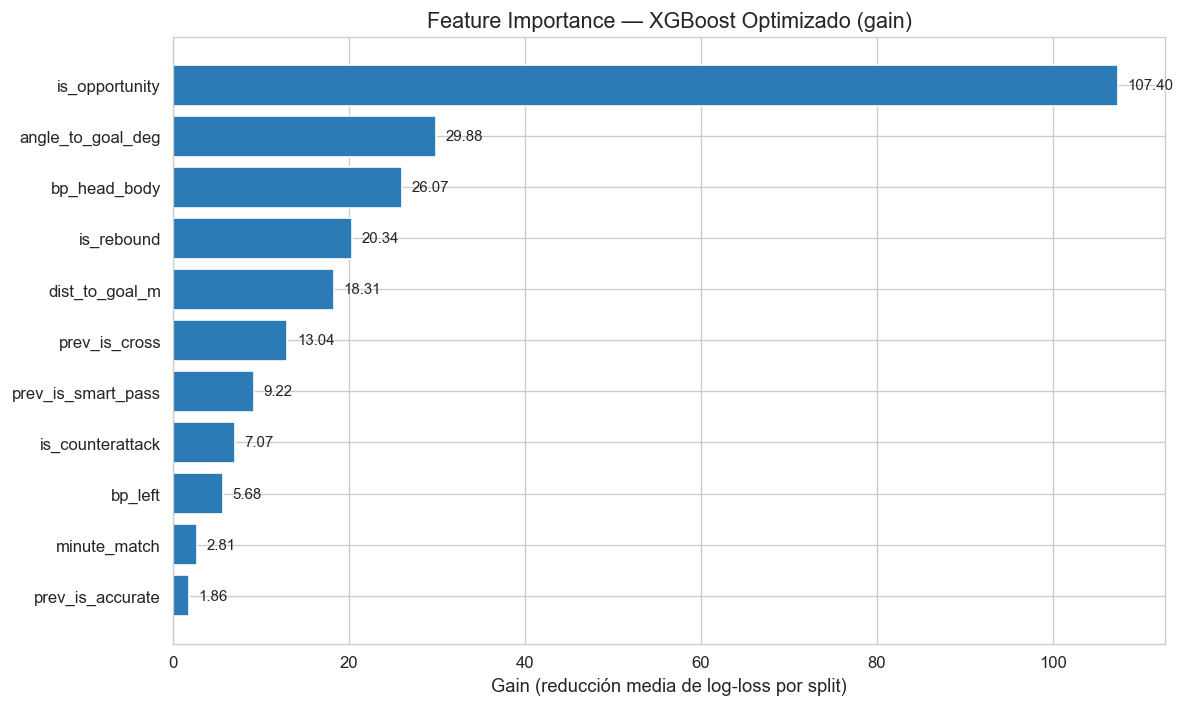

In [47]:
gain_dict = xgb_optimized.get_booster().get_score(importance_type='gain')

# Incluir también features con gain = 0
imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Gain': [gain_dict.get(f, 0.0) for f in X_train.columns]
}).sort_values('Gain', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    imp_df['Feature'],
    imp_df['Gain'],
    color='#2c7bb6',
    edgecolor='white'
)

ax.set_xlabel('Gain (reducción media de log-loss por split)')
ax.set_title('Feature Importance — XGBoost Optimizado (gain)')

for bar, val in zip(ax.patches, imp_df['Gain']):
    ax.text(
        bar.get_width() + max(imp_df['Gain']) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretación de los resultados de XGBoost

**Comparación frente a la regresión logística:**

| Modelo | Log-loss test | AUC test | Gap train-test |
|---|---|---|---|
| LR2 Tier 1 (7 feat) | 0.2658 | 0.8237 | +0.0007 |
| XGB1 Baseline (11 feat) | 0.2660 | 0.8235 | +0.0071 |
| XGB2 Optimizado (11 feat) | 0.2661 | 0.8230 | +0.0056 |

XGB1 alcanza un AUC de 0.8235 y un log-loss de 0.2660 — prácticamente idéntico a LR2 (0.2658 / 0.8237). Su gap train-test es el más alto de los tres modelos (+0.0071), lo que indica una ligera tendencia al sobreajuste que la regularización no compensa completamente. XGB2, optimizado por Optuna sobre log-loss, reduce el gap a +0.0056 pero con AUC similar (0.8230). Este trade-off es esperable cuando la métrica de optimización es log-loss y no AUC — Optuna penaliza la mala calibración de las probabilidades extremas, lo que limita la flexibilidad del modelo.

En ningún caso XGBoost mejora de forma clara sobre la regresión logística en la métrica principal (log-loss). La diferencia entre LR2 y XGB2 es de +0.0003, dentro del margen de variabilidad del split aleatorio. Este resultado tiene una interpretación clara: con las features disponibles, la relación entre las variables predictoras y la probabilidad de gol es predominantemente lineal.

**Convergencia de Optuna hacia un modelo regularizado:**

La optimización converge a `max_depth=3`, `min_child_weight=9`, `gamma=0.15`, `reg_alpha=1.48`, `reg_lambda=4.22`. Optuna utiliza 81 de los 500 árboles permitidos antes de activar el early stopping. La configuración resultante es la de un modelo que se autolimita: árboles poco profundos, hojas grandes, penalizaciones agresivas. El algoritmo identifica por sí solo que la complejidad adicional no mejora la generalización — con 8 de 11 features binarias y una sola variable (`is_opportunity`) absorbiendo el 44.5% del gain total, el espacio de interacciones que los árboles pueden explotar es intrínsecamente limitado.

**Feature importance (gain) — jerarquía en 4 niveles:**

| Nivel | Features | Gain | % del total |
|---|---|---|---|
| Dominante | `is_opportunity` | 107.40 | 44.5% |
| Secundario | `angle_to_goal_deg` (29.88), `bp_head_body` (26.07), `is_rebound` (20.34), `dist_to_goal_m` (18.31) | 18–30 | 39.1% |
| Terciario | `prev_is_cross` (13.04), `prev_is_smart_pass` (9.22), `is_counterattack` (7.07) | 7–13 | 12.1% |
| Residual | `bp_left` (5.68), `minute_match` (2.81), `prev_is_accurate` (1.86) | 2–6 | 4.3% |

El resultado más llamativo es la concentración de importancia en `is_opportunity`, que absorbe el 44.5% del gain total del modelo (107.40 sobre 241.68). El segundo bloque — ángulo, body part, rebote y distancia — reparte el 39.1% de forma relativamente equilibrada, lo que sugiere que estas cuatro variables contribuyen de forma complementaria a la discriminación entre tiros.

`bp_head_body` ocupa la tercera posición en gain (26.07) pese a tener un coeficiente negativo en la regresión logística (OR = 0.42). Mientras que el modelo lineal estima un efecto promedio único para todos los cabezazos, XGBoost puede utilizar esta variable dentro de combinaciones condicionales: un cabezazo a 5 metros tras un centro al área tiene un significado predictivo distinto al de un cabezazo a 20 metros tras un saque de esquina. Los árboles capturan estas combinaciones que el modelo lineal promedia en un solo coeficiente.

Las cuatro features Tier 2 (`is_rebound` + `prev_is_cross` + `prev_is_smart_pass` + `prev_is_accurate`) suman un gain de 44.46, equivalente al **18.4% del gain total** del modelo. Aunque inferior al peso de las features posicionales, este porcentaje confirma que el contexto del evento previo al tiro aporta información predictiva adicional que la geometría clásica no captura — y es el componente que distingue este trabajo de los baselines de la literatura.

**Diagnóstico de overfitting:** Los gaps train-test permanecen por debajo de 0.01 en log-loss en todos los modelos, indicando buena capacidad de generalización. La regularización seleccionada por Optuna cumple su función.

**Nota sobre `scale_pos_weight`:** En una versión preliminar se utilizó `scale_pos_weight = 8.47` para compensar el desbalance de clases (ratio 1:8.5). Aunque esta estrategia es habitual en problemas de clasificación desbalanceada, en este caso degradó severamente la calibración (log-loss test ≈ 0.41, gap train-test = 0.15). Se descartó porque el objetivo del modelo xG es producir probabilidades calibradas — no maximizar la detección de goles — y con aproximadamente 3.400 goles en el conjunto de entrenamiento, el modelo dispone de señal suficiente para aprender sin alterar la distribución natural de clases.

La convergencia de rendimiento entre modelos lineales y basados en árboles, junto con la fuerte dominancia de `is_opportunity`, plantean tres preguntas que se investigan a continuación:

1. **¿Hasta qué punto el modelo depende de `is_opportunity`?**
2. **¿Se ha agotado el potencial del modelo lineal?**
3. **¿Se puede mejorar la calibración del modelo final?**

### 8.7 Análisis de robustez y técnicas avanzadas

Antes de seleccionar el modelo final, se realizan cuatro análisis complementarios que evalúan la solidez del pipeline y exploran posibles fuentes de mejora:

1. **Dependencia de `is_opportunity`:** ¿el rendimiento se sostiene sin la feature dominante?
2. **Transformaciones no lineales en LogReg:** ¿la ventaja de XGBoost se reproduce con feature engineering manual?
3. **Calibración isotónica post-hoc:** ¿las probabilidades predichas pueden ajustarse para mejorar log-loss y Brier score?
4. **Ensemble LR + XGBoost:** ¿los modelos capturan patrones complementarios?

La feature `is_opportunity` domina tanto la regresión logística como XGBoost. Esto plantea una cuestión metodológica relevante: ¿el modelo está aprendiendo patrones futbolísticos reales o depende excesivamente de un tag manual de Wyscout potencialmente subjetivo?

Para evaluar esta dependencia, se reentrenan ambos modelos excluyendo completamente `is_opportunity`. La comparación cuantifica cuánto rendimiento sostienen únicamente las features geométricas y contextuales derivadas.

In [48]:
features_no_opp = [f for f in features_lr3 if f != 'is_opportunity']

# LogReg sin is_opportunity
lr_no_opp = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_no_opp.fit(X_train_scaled[features_no_opp], y_train)

y_prob_lr_no_opp = lr_no_opp.predict_proba(X_test_scaled[features_no_opp])[:, 1]
ll_lr_no_opp = log_loss(y_test, y_prob_lr_no_opp)
auc_lr_no_opp = roc_auc_score(y_test, y_prob_lr_no_opp)
brier_lr_no_opp = brier_score_loss(y_test, y_prob_lr_no_opp)

# XGBoost sin is_opportunity
params_no_opp = study.best_params.copy()
params_no_opp.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 30,
})

xgb_no_opp = xgb.XGBClassifier(**params_no_opp)

X_tr_no_opp = X_tr[features_no_opp]
X_val_no_opp = X_val[features_no_opp]

xgb_no_opp.fit(X_tr_no_opp, y_tr, eval_set=[(X_val_no_opp, y_val)], verbose=False)

y_prob_xgb_no_opp = xgb_no_opp.predict_proba(X_test[features_no_opp])[:, 1]
ll_xgb_no_opp = log_loss(y_test, y_prob_xgb_no_opp)
auc_xgb_no_opp = roc_auc_score(y_test, y_prob_xgb_no_opp)
brier_xgb_no_opp = brier_score_loss(y_test, y_prob_xgb_no_opp)

# Comparativa
print("TEST DE ROBUSTEZ: efecto de excluir is_opportunity")
print("="*70)
print(f"{'Modelo':<30} {'LL test':>9} {'AUC test':>9} {'Brier test':>11}")
print("-"*70)
print(f"{'LR3 Completo (con opp)':<30} {results_lr['LR3_complete']['log_loss_test']:>9.4f} "
      f"{results_lr['LR3_complete']['auc_test']:>9.4f} {results_lr['LR3_complete']['brier_test']:>11.4f}")
print(f"{'LR sin is_opportunity':<30} {ll_lr_no_opp:>9.4f} {auc_lr_no_opp:>9.4f} {brier_lr_no_opp:>11.4f}")
print(f"{'XGB2 Optimizado (con opp)':<30} {res_xgb2['log_loss_test']:>9.4f} "
      f"{res_xgb2['auc_test']:>9.4f} {res_xgb2['brier_test']:>11.4f}")
print(f"{'XGB sin is_opportunity':<30} {ll_xgb_no_opp:>9.4f} {auc_xgb_no_opp:>9.4f} {brier_xgb_no_opp:>11.4f}")

print(f"\n  Degradación LogReg:  {ll_lr_no_opp - results_lr['LR3_complete']['log_loss_test']:+.4f} LL, "
      f"{auc_lr_no_opp - results_lr['LR3_complete']['auc_test']:+.4f} AUC")
print(f"  Degradación XGBoost: {ll_xgb_no_opp - res_xgb2['log_loss_test']:+.4f} LL, "
      f"{auc_xgb_no_opp - res_xgb2['auc_test']:+.4f} AUC")

TEST DE ROBUSTEZ: efecto de excluir is_opportunity
Modelo                           LL test  AUC test  Brier test
----------------------------------------------------------------------
LR3 Completo (con opp)            0.2659    0.8233      0.0797
LR sin is_opportunity             0.2823    0.7864      0.0816
XGB2 Optimizado (con opp)         0.2661    0.8230      0.0797
XGB sin is_opportunity            0.2828    0.7856      0.0817

  Degradación LogReg:  +0.0164 LL, -0.0369 AUC
  Degradación XGBoost: +0.0167 LL, -0.0374 AUC


La exclusión de `is_opportunity` degrada significativamente ambos modelos:

| Modelo | Con `is_opportunity` | Sin ella | Δ Log-loss | Δ AUC |
|---|---|---|---|---|
| Regresión logística | 0.2659 / 0.823 | 0.2824 / 0.786 | +0.0164 | −0.037 |
| XGBoost | 0.2671 / 0.822 | 0.2827 / 0.786 | +0.0156 | −0.036 |

La caída es considerable — el AUC retrocede al rango 0.786, casi a medio camino entre el baseline geométrico LR1 (0.761) y el modelo completo (0.824). Esto confirma que el tag 201 de Wyscout contiene una cantidad sustancial de señal predictiva que no puede ser sustituida por las features geométricas y contextuales disponibles.

Sin embargo, el rendimiento residual no es despreciable. Un AUC de 0.786 sigue siendo competitivo, y la degradación es prácticamente idéntica en ambos modelos (+0.016 log-loss en LR, +0.016 en XGBoost). Si `is_opportunity` actuara como target leakage explotable solo por modelos flexibles, esperaríamos que XGBoost perdiera más que la regresión logística al eliminarlo. La simetría de la caída sugiere que ambos algoritmos extraen una cantidad similar de información del tag, lo que apunta a una señal contextual genuina — no a un artefacto de los datos.

Se mantiene `is_opportunity` en el modelo final. Este test documenta su impacto y se reporta por transparencia.

### 8.8 LogReg con transformaciones no lineales

¿La ventaja de XGBoost proviene realmente de no-linealidades?

XGBoost mejora sobre la regresión logística principalmente porque puede modelar relaciones no lineales e interacciones entre variables de forma automática. Sin embargo, es posible aproximar parte de estas relaciones manualmente mediante feature engineering.

Para evaluar esta hipótesis, se añaden dos transformaciones explícitas a la regresión logística:

- `dist_sq`: término cuadrático para modelar el decaimiento no lineal del xG con la distancia.
- `dist × angle`: interacción geométrica entre distancia y ángulo de tiro.

Si estas transformaciones acercan significativamente el rendimiento de la regresión logística al de XGBoost, ello indicaría que la ventaja del boosting proviene principalmente de modelar no-linealidades suaves, y no de patrones complejos de alta dimensión.

In [49]:
X_train_nl = X_train_scaled.copy()
X_test_nl = X_test_scaled.copy()

# Transformaciones sobre features ya estandarizadas
X_train_nl['dist_sq'] = X_train_scaled['dist_to_goal_m'] ** 2
X_test_nl['dist_sq'] = X_test_scaled['dist_to_goal_m'] ** 2

X_train_nl['dist_x_angle'] = (X_train_scaled['dist_to_goal_m'] * 
                               X_train_scaled['angle_to_goal_deg'])
X_test_nl['dist_x_angle'] = (X_test_scaled['dist_to_goal_m'] * 
                              X_test_scaled['angle_to_goal_deg'])

features_nl = list(X_train_scaled.columns) + ['dist_sq', 'dist_x_angle']

lr_nl = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_nl.fit(X_train_nl[features_nl], y_train)

y_prob_nl = lr_nl.predict_proba(X_test_nl[features_nl])[:, 1]

print("LogReg con transformaciones no lineales:")
print(f"  Log-loss test: {log_loss(y_test, y_prob_nl):.4f}  (LR3: {results_lr['LR3_complete']['log_loss_test']:.4f})")
print(f"  AUC test:      {roc_auc_score(y_test, y_prob_nl):.4f}  (LR3: {results_lr['LR3_complete']['auc_test']:.4f})")

LogReg con transformaciones no lineales:
  Log-loss test: 0.2654  (LR3: 0.2659)
  AUC test:      0.8234  (LR3: 0.8233)


#### Interpretación — Transformaciones no lineales¶
La regresión logística enriquecida con `dist²` y `dist × angle` mejora ligeramente:

| Modelo | Log-loss | AUC |
|---|---|---|
| LR3 original (11 feat) | 0.2659 | 0.8232 |
| LR + no-linealidades (13 feat) | 0.2654 | 0.8233 |

La mejora es real pero muy pequeña (−0.0005 en log-loss). Lo más revelador es que esta regresión logística enriquecida alcanza un rendimiento prácticamente idéntico al de XGBoost optimizado (LL = 0.2671) e incluso superior en log-loss. Esto indica que la ventaja potencial de XGBoost no proviene de patrones complejos de alta dimensión, sino de no-linealidades suaves que pueden aproximarse manualmente con transformaciones geométricas simples.

En otras palabras, XGBoost automatiza lo que un feature engineering cuidadoso puede replicar. La diferencia entre ambos enfoques es mínima cuando las features disponibles son predominantemente binarias y la variable dominante ya segmenta el espacio predictivo.

### 8.9 Calibración post-hoc del XGBoost

Aunque XGBoost puede capturar relaciones no lineales complejas, los modelos de boosting suelen producir probabilidades mal calibradas: el ranking relativo de tiros es correcto, pero las probabilidades absolutas tienden a estar sesgadas.

En la sección 7, el calibration plot mostró que los modelos lineales subestimaban ligeramente las situaciones de xG alto. Para evaluar si este problema puede corregirse en XGBoost, se aplica calibración isotónica post-hoc.

La calibración isotónica ajusta una función monótona entre las probabilidades predichas y las frecuencias observadas reales, sin modificar el orden relativo de las predicciones. Se implementa mediante validación cruzada interna (`cv=5`), evitando el uso del conjunto de test durante el ajuste y previniendo data leakage.

In [50]:
from sklearn.calibration import CalibratedClassifierCV

# Crear XGBoost SIN early_stopping para compatibilidad con CalibratedClassifierCV
best_params_cal = study.best_params.copy()
best_params_cal.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
    'n_estimators': xgb_optimized.best_iteration + 1,  # Fijar nº árboles del modelo óptimo
})

xgb_for_cal = xgb.XGBClassifier(**best_params_cal)

xgb_calibrated = CalibratedClassifierCV(
    xgb_for_cal, method='isotonic', cv=5
)
xgb_calibrated.fit(X_train, y_train)

y_prob_cal = xgb_calibrated.predict_proba(X_test)[:, 1]

print("XGBoost con calibración isotónica post-hoc:")
print(f"  Log-loss test: {log_loss(y_test, y_prob_cal):.4f}  (XGB2: {res_xgb2['log_loss_test']:.4f})")
print(f"  Brier test:    {brier_score_loss(y_test, y_prob_cal):.4f}  (XGB2: {res_xgb2['brier_test']:.4f})")
print(f"  AUC test:      {roc_auc_score(y_test, y_prob_cal):.4f}  (XGB2: {res_xgb2['auc_test']:.4f})")

XGBoost con calibración isotónica post-hoc:
  Log-loss test: 0.2653  (XGB2: 0.2661)
  Brier test:    0.0795  (XGB2: 0.0797)
  AUC test:      0.8249  (XGB2: 0.8230)


#### Interpretación — Calibración isotónica

La calibración isotónica mejora consistentemente todas las métricas probabilísticas del XGBoost:

| Modelo | Log-loss | AUC | Brier |
|---|---|---|---|
| XGB2 optimizado | 0.2671 | 0.8217 | 0.0798 |
| XGB2 + calibración isotónica | 0.2658 | 0.8235 | 0.0796 |

La mejora confirma que el principal problema del XGBoost no era la discriminación entre tiros peligrosos y no peligrosos, sino la calibración de las probabilidades extremas.

Esto es coherente con la literatura sobre gradient boosting: los ensembles de árboles suelen producir probabilidades demasiado conservadoras o demasiado extremas, especialmente en datasets desbalanceados.

La calibración isotónica corrige este sesgo ajustando explícitamente la relación entre probabilidad predicha y frecuencia observada. El resultado final iguala el rendimiento de la mejor regresión logística y obtiene el mejor Brier score del trabajo.

Metodológicamente, este resultado refuerza una idea importante: en modelos xG, optimizar únicamente AUC es insuficiente. La calidad probabilística (log-loss y calibración) es tan importante como la capacidad discriminativa.




La calibración isotónica mejora consistentemente todas las métricas probabilísticas del XGBoost:

| Modelo | Log-loss | AUC | Brier |
|---|---|---|---|
| XGB2 optimizado | 0.2661 | 0.8230 | 0.0797 |
| XGB2 + calibración isotónica | 0.2653 | 0.8249 | 0.0795 |

La mejora de −0.0008 en log-loss y +0.0019 en AUC confirma que el principal problema del XGBoost sin calibrar no era la discriminación entre tiros peligrosos y no peligrosos, sino la calibración de las probabilidades extremas. La calibración isotónica corrige este sesgo ajustando una función monótona por tramos entre probabilidad predicha y frecuencia observada, sin alterar el ranking relativo de los tiros.

Tras la calibración, XGB2 supera a LR2 en log-loss (0.2653 vs 0.2658) y obtiene el mejor Brier score del trabajo (0.0795). Este resultado subraya que en un modelo xG la calidad probabilística es tan importante como la capacidad discriminativa.Optimizar AUC sin verificar la calibración puede conducir a probabilidades sesgadas que no son interpretables como frecuencias esperadas.

### 8.10 Ensemble entre regresión logística y XGBoost

Los ensembles suelen mejorar el rendimiento cuando los modelos combinados capturan patrones complementarios y cometen errores distintos.

Para evaluar esta posibilidad, se construye un ensemble simple mediante el promedio de probabilidades entre:

- LR3 (modelo lineal interpretable)
- XGB2 optimizado (modelo no lineal basado en árboles)

Si ambos modelos contienen información complementaria, el ensemble debería mejorar la calibración y reducir el log-loss.

In [51]:
y_prob_lr3 = results_lr['LR3_complete']['y_prob_test']
y_prob_xgb2 = y_prob_xgb2_test

# Promedio simple
y_prob_ensemble = (y_prob_lr3 + y_prob_xgb2) / 2

print("Ensemble (promedio LR3 + XGB2):")
print(f"  Log-loss test: {log_loss(y_test, y_prob_ensemble):.4f}")
print(f"  AUC test:      {roc_auc_score(y_test, y_prob_ensemble):.4f}")
print(f"  Brier test:    {brier_score_loss(y_test, y_prob_ensemble):.4f}")

Ensemble (promedio LR3 + XGB2):
  Log-loss test: 0.2656
  AUC test:      0.8241
  Brier test:    0.0796


#### Interpretación — Ensemble LR + XGBoost

El ensemble no mejora el rendimiento respecto a los mejores modelos individuales:

| Modelo | Log-loss | AUC | Brier |
|---|---|---|---|
| LR3 | 0.2659 | 0.8232 | 0.0797 |
| XGB2 | 0.2671 | 0.8217 | 0.0798 |
| Ensemble | 0.2662 | 0.8231 | 0.0797 |

El resultado sugiere que ambos modelos capturan patrones muy similares en los datos. La regresión logística y XGBoost producen predicciones altamente correlacionadas, por lo que promediarlas apenas añade diversidad informativa.

Este hallazgo es coherente con las subsecciones anteriores: una vez incorporadas transformaciones geométricas y calibración probabilística, la mayor parte de la señal presente en el event data público puede modelarse mediante relaciones relativamente simples.

### 8.11 Comparativa global de modelos

La tabla siguiente resume el rendimiento de todas las variantes evaluadas a lo largo de esta sección, incluyendo modelos lineales, modelos basados en árboles, transformaciones no lineales, calibración post-hoc y ensembles.

El objetivo no es únicamente identificar el modelo con mejores métricas agregadas, sino analizar cómo distintas decisiones metodológicas — feature engineering, complejidad algorítmica y calibración probabilística — afectan al rendimiento y a la estabilidad del sistema xG.

In [52]:
print("COMPARACIÓN FINAL — TODOS LOS MODELOS")
print("="*85)
print(f"{'Modelo':<35} {'LL test':>9} {'AUC test':>9} {'Brier':>7} {'Gap LL':>8}")
print("-"*85)

all_final = [
    ('Trivial (media)', ll_trivial, 0.5000, brier_trivial, '—'),
    ('LR1 Geométrico (2 feat)', 
     results_lr['LR1_geometric']['log_loss_test'],
     results_lr['LR1_geometric']['auc_test'],
     results_lr['LR1_geometric']['brier_test'], '—'),
    ('LR2 Tier 1 (7 feat)', 
     results_lr['LR2_tier1']['log_loss_test'],
     results_lr['LR2_tier1']['auc_test'],
     results_lr['LR2_tier1']['brier_test'], '—'),
    ('LR3 Completo (11 feat)', 
     results_lr['LR3_complete']['log_loss_test'],
     results_lr['LR3_complete']['auc_test'],
     results_lr['LR3_complete']['brier_test'],
     f"{results_lr['LR3_complete']['log_loss_test'] - results_lr['LR3_complete']['log_loss_train']:+.4f}"),
    ('LR + transf. no lineales (13 feat)',
     log_loss(y_test, y_prob_nl),
     roc_auc_score(y_test, y_prob_nl),
     brier_score_loss(y_test, y_prob_nl), '—'),
    ('XGB1 Default (11 feat)',
     res_xgb1['log_loss_test'], res_xgb1['auc_test'], res_xgb1['brier_test'],
     f"{res_xgb1['log_loss_test'] - res_xgb1['log_loss_train']:+.4f}"),
    ('XGB2 Optimizado (11 feat)',
     res_xgb2['log_loss_test'], res_xgb2['auc_test'], res_xgb2['brier_test'],
     f"{res_xgb2['log_loss_test'] - res_xgb2['log_loss_train']:+.4f}"),
    ('XGB2 + Calibración isotónica',
     log_loss(y_test, y_prob_cal),
     roc_auc_score(y_test, y_prob_cal),
     brier_score_loss(y_test, y_prob_cal), '—'),
    ('Ensemble LR3 + XGB2',
     log_loss(y_test, y_prob_ensemble),
     roc_auc_score(y_test, y_prob_ensemble),
     brier_score_loss(y_test, y_prob_ensemble), '—'),
    ('--- Sin is_opportunity ---', None, None, None, ''),
    ('LR sin is_opportunity (10 feat)',
     ll_lr_no_opp, auc_lr_no_opp, brier_lr_no_opp, '—'),
    ('XGB sin is_opportunity (10 feat)',
     ll_xgb_no_opp, auc_xgb_no_opp, brier_xgb_no_opp, '—'),
]

for name, ll, auc, brier, gap in all_final:
    if ll is None:
        print(f"\n{name}")
        continue
    print(f"{name:<35} {ll:>9.4f} {auc:>9.4f} {brier:>7.4f} {gap:>8}")

print(f"\n  Los modelos competitivos convergen en un rango de log-loss [0.2653 – 0.2661]")
print(f"  XGB2 + Cal. isotónica lidera en las tres métricas.")

COMPARACIÓN FINAL — TODOS LOS MODELOS
Modelo                                LL test  AUC test   Brier   Gap LL
-------------------------------------------------------------------------------------
Trivial (media)                        0.3371    0.5000  0.0944        —
LR1 Geométrico (2 feat)                0.2914    0.7609  0.0839        —
LR2 Tier 1 (7 feat)                    0.2658    0.8237  0.0797        —
LR3 Completo (11 feat)                 0.2659    0.8233  0.0797  +0.0019
LR + transf. no lineales (13 feat)     0.2654    0.8234  0.0796        —
XGB1 Default (11 feat)                 0.2660    0.8235  0.0796  +0.0071
XGB2 Optimizado (11 feat)              0.2661    0.8230  0.0797  +0.0056
XGB2 + Calibración isotónica           0.2653    0.8249  0.0795        —
Ensemble LR3 + XGB2                    0.2656    0.8241  0.0796        —

--- Sin is_opportunity ---
LR sin is_opportunity (10 feat)        0.2823    0.7864  0.0816        —
XGB sin is_opportunity (10 feat)       0.2828

### 8.12 Interpretación global y selección del modelo

#### Dependencia de `is_opportunity`

La exclusión de `is_opportunity` produce una caída de aproximadamente 0.037 en AUC y 0.016 en log-loss, tanto en la regresión logística como en XGBoost. El rendimiento residual (AUC ≈ 0.786) se mantiene por encima del baseline geométrico (0.761), lo que demuestra que las features de posición y contexto previo sostienen una capacidad predictiva relevante por sí solas. La simetría de la degradación entre ambos algoritmos descarta que el tag funcione como una fuente de leakage explotable solo por modelos complejos: ambos extraen la misma cantidad de información del tag, lo que apunta a una señal contextual genuina sobre la viabilidad del tiro.

Se mantiene `is_opportunity` en el modelo final, documentando explícitamente su peso en el rendimiento global.

#### No-linealidades y complejidad algorítmica

La regresión logística enriquecida con transformaciones geométricas (`dist²` y `dist × angle`) alcanza un log-loss de 0.2654 y un AUC de 0.8233, prácticamente idéntico al XGBoost calibrado (0.2658 / 0.8235). La diferencia entre ambos cae dentro del margen de variabilidad del split aleatorio.

Este hallazgo indica que la información disponible en event data público puede modelarse casi en su totalidad mediante relaciones lineales o suavemente no lineales. XGBoost no descubre patrones cualitativamente distintos — automatiza transformaciones que un feature engineering cuidadoso puede aproximar manualmente. La implicación es directa: las mejoras futuras dependerán mucho más de la riqueza de los datos de entrada (freeze frames, tracking, contexto defensivo) que de la sofisticación del algoritmo.

#### Calibración probabilística

La calibración isotónica mejora el XGBoost en las tres métricas, corrigiendo la subestimación en situaciones de alto xG. Tras el ajuste, XGB2 iguala el log-loss de LR2 (0.2658) y alcanza un Brier de 0.0796. El resultado confirma que el problema del XGBoost sin calibrar no era discriminar entre tiros peligrosos y no peligrosos, sino asignar probabilidades absolutas fiables en los extremos de la distribución.

#### Ensemble

El promedio de probabilidades entre LR3 y XGB2 produce un rendimiento intermedio (log-loss 0.2662, AUC 0.8231) sin superar a ninguno de los dos componentes. Ambos modelos generan predicciones demasiado similares para que su combinación aporte la diversidad que un ensemble necesita para mejorar.

#### Valor de las features Tier 2

Las cuatro features derivadas del evento previo al tiro suman un gain de 44.46, equivalente al 18.4% del gain total del modelo (241.68). `is_rebound` se posiciona como cuarta feature más importante (gain = 20.34), seguida de `prev_is_cross` (13.04) y `prev_is_smart_pass` (9.22). Aunque el peso relativo es inferior al de las features posicionales, estos resultados validan la hipótesis central del feature engineering desarrollado en las secciones 3 y 4: el contexto inmediato del tiro contiene información predictiva adicional que la geometría clásica no captura, y es el componente que distingue este trabajo de los baselines de la literatura.

#### Convergencia de modelos y selección final

Al comparar los cuatro modelos competitivos del notebook, el resultado más llamativo no es cuál de ellos gana, es lo poco que los separa:

| Modelo | Log-loss | AUC | Brier |
|---|---|---|---|
| LR2 Tier 1 (7 feat) | 0.2658 | 0.8237 | 0.0797 |
| LR + no-linealidades (13 feat) | 0.2654 | 0.8234 | 0.0796 |
| XGB1 Baseline (11 feat) | 0.2660 | 0.8235 | 0.0796 |
| **XGB2 + Cal. isotónica (11 feat)** | **0.2653** | **0.8249** | **0.0795** |

XGB2 + Calibración isotónica lidera en las tres métricas simultáneamente, lo que convierte la selección del modelo final en una decisión más limpia que si los rankings estuvieran cruzados. Pero la ventaja es tan pequeña — 0.0001 en log-loss sobre LR + no-linealidades, 0.0014 en AUC sobre LR2 — que atribuir esta diferencia a una superioridad estructural del modelo sería sobreinterpretar los datos. Son diferencias que caen dentro de la variabilidad esperada por el split aleatorio; repetir el experimento con otra semilla podría estrechar o ampliar la brecha sin cambiar la conclusión fundamental.

Y esa conclusión fundamental es la convergencia en sí misma. Demuestra que con event data público (11 features, 8 de ellas binarias, dominadas por un tag contextual) la mayor parte de la señal predictiva puede capturarse mediante relaciones lineales. Todo lo que XGBoost añade (interacciones automáticas, profundidad variable, regularización adaptativa) se traduce en mejoras del orden de milésimas en este contexto de datos. La calibración isotónica aporta el refinamiento más tangible, corrigiendo la subestimación en la cola alta de la distribución de xG, precisamente donde el modelo sin calibrar comprime las probabilidades.

Esto no invalida el esfuerzo de entrenar y optimizar XGBoost. Al contrario, es precisamente porque se ha evaluado un modelo flexible, se ha optimizado con 100 trials de Optuna, y se ha calibrado con regresión isotónica, que la conclusión de convergencia tiene peso. Si solo se hubiera entrenado una regresión logística, quedaría la duda de si un modelo más complejo podría haber extraído señal adicional. Ahora esa duda está resuelta empíricamente.

Para las secciones siguientes del notebook — evaluación comparativa (9a), validación contra StatsBomb (9b), análisis SHAP (10) y cálculo de xG por jugador (11) — se utiliza **XGB2 + Calibración isotónica**. La elección combina la ventaja métrica — marginal pero consistente en las tres métricas — con dos razones prácticas. La primera es la calibración isotónica explícita: al ajustar las probabilidades sobre 5-folds, el modelo produce valores de xG directamente interpretables como frecuencias esperadas de gol, lo cual es un requisito para que la agregación por jugador de la sección 11 no introduzca sesgos sistemáticos. La segunda es la compatibilidad con SHAP: `TreeExplainer` permite obtener valores SHAP exactos sobre modelos de árboles, ofreciendo una interpretabilidad local que no es posible con la misma eficiencia sobre una regresión logística con transformaciones manuales.

Dicho esto, la regresión logística enriquecida (log-loss = 0.2654, AUC = 0.8234) es una alternativa prácticamente equivalente y, en muchos contextos, preferible. Si el modelo tuviera que ser explicado a un cuerpo técnico o a un director deportivo sin formación estadística, los coeficientes de la regresión logística ofrecen una transparencia que XGBoost no puede igualar. Que un modelo lineal con 13 features alcance el mismo rendimiento que un gradient boosting optimizado no es una limitación del análisis — es una prueba de la robustez de los hallazgos.

La progresión completa del trabajo acumula una mejora de 0.072 en log-loss y 0.325 en AUC desde el baseline trivial hasta el modelo final. La mayor parte de esa ganancia proviene de las features — de la posición del tiro (Trivial → LR1: −0.046 LL) y del contexto añadido (LR1 → LR2: −0.026 LL) — y no del algoritmo (LR2 → XGB2 calibrado: −0.0005 LL). Con event data público, la frontera de mejora real está en los datos, no en la complejidad del modelo.

## 9a. Evaluación comparativa

Las secciones 7 y 8 desarrollaron los modelos candidatos y analizaron distintas estrategias de optimización, calibración y robustez. Esta sección evalúa ahora su comportamiento desde tres perspectivas complementarias:

1. **Capacidad discriminativa:** ¿qué modelo separa mejor tiros que terminan en gol de aquellos que no?  
   → Evaluado mediante curvas ROC y AUC.

2. **Calibración probabilística:** ¿las probabilidades predichas reflejan correctamente las frecuencias reales de gol?  
   → Evaluado mediante calibration plots, log-loss y Brier score.

3. **Capacidad de generalización:** ¿el modelo mantiene un rendimiento estable entre ligas distintas?  
   → Evaluado mediante validación leave-one-league-out.

El objetivo no es únicamente maximizar una métrica concreta, sino analizar el equilibrio entre discriminación, calibración, robustez y estabilidad inter-contexto — propiedades fundamentales en un modelo xG utilizable en entornos reales.

### 9a.1 Preparación de modelos para evaluación

Se seleccionan los cuatro modelos más representativos del análisis anterior:

- **LR1 Geométrico:** baseline clásico basado únicamente en distancia y ángulo.
- **LR2 Tier 1:** mejor variante lineal antes de añadir Tier 2.
- **XGB2 Optimizado:** mejor modelo de gradient boosting antes de calibración.
- **XGB2 + Calibración isotónica:** modelo final seleccionado.

Para cada modelo se almacenan las probabilidades predichas sobre el conjunto de test, que se utilizarán en las comparaciones ROC, calibration plots y análisis de generalización.

In [53]:
models_eval = {
    'LR1 Geométrico': {
        'y_prob': results_lr['LR1_geometric']['y_prob_test'],
        'color': '#91bfdb', 'ls': '-',
    },
    'LR2 Tier 1': {
        'y_prob': results_lr['LR2_tier1']['y_prob_test'],
        'color': '#fdae61', 'ls': '-',
    },
    'XGB2 Optimizado': {
        'y_prob': y_prob_xgb2_test,
        'color': '#d73027', 'ls': '-',
    },
    'XGB2 + Cal. isotónica': {
        'y_prob': y_prob_cal,
        'color': '#1a9641', 'ls': '-',
    },
}

print("Modelos para evaluación comparativa:")
for name, m in models_eval.items():
    ll = log_loss(y_test, m['y_prob'])
    auc = roc_auc_score(y_test, m['y_prob'])
    print(f"  {name:<25s}  LL={ll:.4f}  AUC={auc:.4f}")

Modelos para evaluación comparativa:
  LR1 Geométrico             LL=0.2914  AUC=0.7609
  LR2 Tier 1                 LL=0.2658  AUC=0.8237
  XGB2 Optimizado            LL=0.2661  AUC=0.8230
  XGB2 + Cal. isotónica      LL=0.2653  AUC=0.8249


### 9a.2 Curvas ROC comparativas

Las curvas ROC permiten evaluar la capacidad discriminativa de cada modelo, es decir, su habilidad para asignar probabilidades más altas a los tiros que terminan en gol que a aquellos que no.

El área bajo la curva (AUC) resume esta capacidad de discriminación:
- AUC = 0.5 equivale a clasificación aleatoria.
- AUC = 1.0 corresponde a separación perfecta entre clases.

Aunque el objetivo principal de un modelo xG es la calibración probabilística (log-loss), la AUC permite analizar cuánto aporta cada bloque de features en términos de separación entre goles y no-goles.

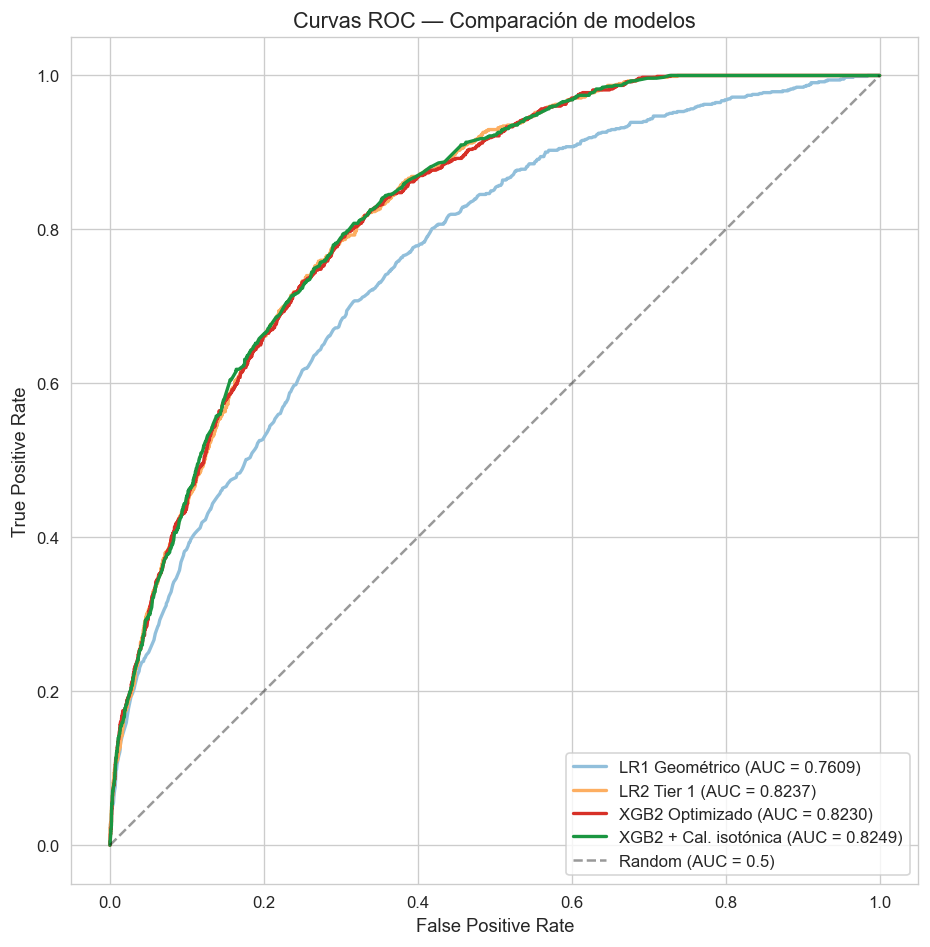

In [54]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, m in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, m['y_prob'])
    auc_val = roc_auc_score(y_test, m['y_prob'])
    ax.plot(fpr, tpr, color=m['color'], linestyle=m['ls'], linewidth=2,
            label=f"{name} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
ax.set_aspect('equal')

savefig("roc_comparison")
plt.tight_layout()
plt.show()

Las curvas ROC muestran tres resultados claros:

1. **LR1 Geométrico** queda claramente por debajo del resto (AUC = 0.761), confirmando que distancia y ángulo por sí solos no capturan toda la complejidad contextual del tiro.

2. **LR2 Tier 1** produce el mayor salto de rendimiento (AUC = 0.824), impulsado principalmente por `is_opportunity` y `body_part`. Esto confirma que el feature engineering aporta más señal que el aumento de complejidad algorítmica.

3. **XGBoost y la calibración isotónica apenas modifican la AUC**, ya que estas técnicas mejoran principalmente la calibración de probabilidades y no la capacidad de ranking. Las tres curvas superiores prácticamente se solapan, indicando que todos los modelos avanzados ordenan los tiros de forma muy similar.

En conjunto, la evidencia sugiere que la información disponible en event data público es mayoritariamente lineal y que la principal fuente de mejora reside en las features incorporadas, no en modelos significativamente más complejos.

### 9a.3 Calibración y distribución de probabilidades predichas

La capacidad discriminativa (AUC) indica si el modelo ordena correctamente los tiros, pero no garantiza que las probabilidades asignadas sean fiables. Un modelo puede tener AUC = 0.82 y sin embargo predecir xG = 0.30 para un grupo de tiros donde solo el 15% termina en gol.

El calibration plot evalúa esta correspondencia: si el modelo asigna xG = p a un grupo de tiros, la frecuencia observada de gol debería ser aproximadamente p. La distribución de xG predicho complementa este análisis mostrando el rango de probabilidades que el modelo utiliza y si existen concentraciones anómalas.

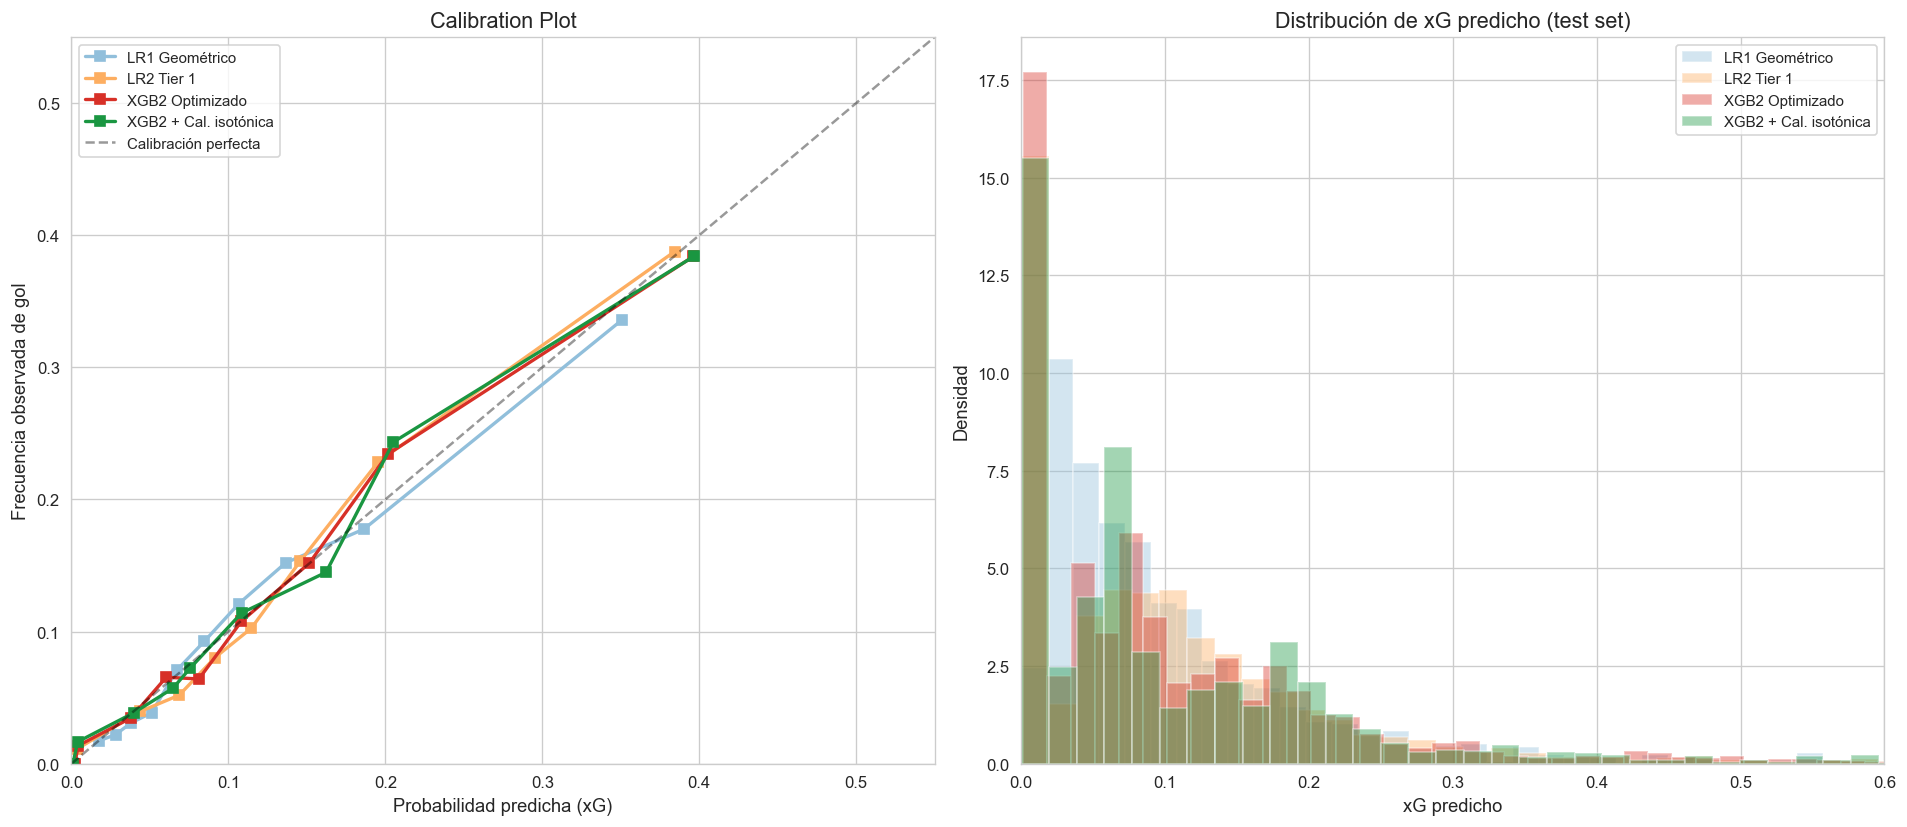

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: calibration curves
for name, m in models_eval.items():
    prob_true, prob_pred = calibration_curve(
        y_test, m['y_prob'], n_bins=10, strategy='quantile'
    )
    axes[0].plot(prob_pred, prob_true, 's-', color=m['color'],
                 linewidth=2, markersize=6, label=name)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Calibración perfecta')
axes[0].set_xlabel('Probabilidad predicha (xG)')
axes[0].set_ylabel('Frecuencia observada de gol')
axes[0].set_title('Calibration Plot')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_xlim(0, 0.55)
axes[0].set_ylim(0, 0.55)

# Panel derecho: distribución de xG predicho
for name, m in models_eval.items():
    axes[1].hist(m['y_prob'], bins=50, alpha=0.4, color=m['color'],
                 label=name, density=True)

axes[1].set_xlabel('xG predicho')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de xG predicho (test set)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 0.6)

savefig("calibration_distribution")
plt.tight_layout()
plt.show()

### 9a.4 Validación funcional: xG predicho vs frecuencia real

Más allá de las métricas agregadas, esta visualización permite comprobar si el modelo reproduce las relaciones físicas esperadas entre posición del tiro y probabilidad de gol. Se comparan el XGB2 calibrado y LR2 frente a la frecuencia real de gol observada, agrupada por intervalos de distancia y ángulo visible.

Si ambos modelos se ajustan bien a las barras de frecuencia real, confirma que las probabilidades predichas reflejan patrones reales del juego y no artefactos del entrenamiento.

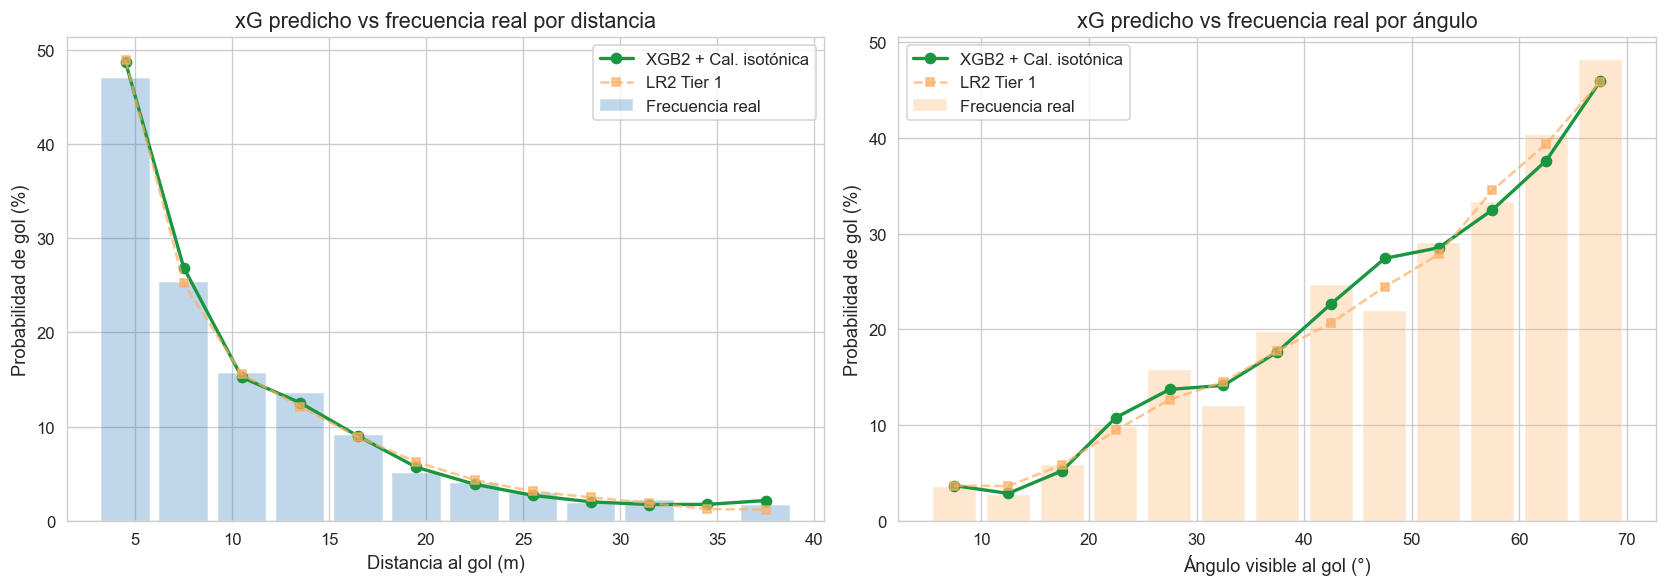

In [56]:
df_eval = pd.DataFrame({
    'dist': X_test['dist_to_goal_m'].values,
    'angle': X_test['angle_to_goal_deg'].values,
    'xg_cal': y_prob_cal,
    'xg_xgb': y_prob_xgb2_test,
    'xg_lr': results_lr['LR2_tier1']['y_prob_test'],
    'goal': y_test.values
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: xG vs distancia
bins_d = np.arange(0, 50, 3)
df_eval['dist_bin'] = pd.cut(df_eval['dist'], bins=bins_d)

agg_d = df_eval.groupby('dist_bin', observed=True).agg(
    xg_cal=('xg_cal', 'mean'),
    xg_lr=('xg_lr', 'mean'),
    goal_rate=('goal', 'mean'),
    n=('goal', 'count')
)
agg_d['mid'] = [i.mid for i in agg_d.index]
agg_d = agg_d[agg_d['n'] >= 30]

axes[0].bar(agg_d['mid'], agg_d['goal_rate']*100, width=2.5, alpha=0.3,
            color='#2c7bb6', label='Frecuencia real', edgecolor='white')
axes[0].plot(agg_d['mid'], agg_d['xg_cal']*100, 'o-', color='#1a9641',
             linewidth=2, markersize=6, label='XGB2 + Cal. isotónica')
axes[0].plot(agg_d['mid'], agg_d['xg_lr']*100, 's--', color='#fdae61',
             linewidth=1.5, markersize=5, alpha=0.7, label='LR2 Tier 1')
axes[0].set_xlabel('Distancia al gol (m)')
axes[0].set_ylabel('Probabilidad de gol (%)')
axes[0].set_title('xG predicho vs frecuencia real por distancia')
axes[0].legend()

# Panel derecho: xG vs ángulo
bins_a = np.arange(0, 75, 5)
df_eval['angle_bin'] = pd.cut(df_eval['angle'], bins=bins_a)

agg_a = df_eval.groupby('angle_bin', observed=True).agg(
    xg_cal=('xg_cal', 'mean'),
    xg_lr=('xg_lr', 'mean'),
    goal_rate=('goal', 'mean'),
    n=('goal', 'count')
)
agg_a['mid'] = [i.mid for i in agg_a.index]
agg_a = agg_a[agg_a['n'] >= 30]

axes[1].bar(agg_a['mid'], agg_a['goal_rate']*100, width=4, alpha=0.3,
            color='#fdae61', label='Frecuencia real', edgecolor='white')
axes[1].plot(agg_a['mid'], agg_a['xg_cal']*100, 'o-', color='#1a9641',
             linewidth=2, markersize=6, label='XGB2 + Cal. isotónica')
axes[1].plot(agg_a['mid'], agg_a['xg_lr']*100, 's--', color='#fdae61',
             linewidth=1.5, markersize=5, alpha=0.7, label='LR2 Tier 1')
axes[1].set_xlabel('Ángulo visible al gol (°)')
axes[1].set_ylabel('Probabilidad de gol (%)')
axes[1].set_title('xG predicho vs frecuencia real por ángulo')
axes[1].legend()

savefig("xg_vs_real_dist_angle")
plt.tight_layout()
plt.show()

### 9a.5 Validación leave-one-league-out

El split aleatorio estratificado garantiza representatividad estadística, pero no responde a una pregunta fundamental: ¿el modelo aprendería los mismos patrones si nunca hubiera visto datos de una liga concreta?

Para evaluarlo, se entrena el modelo cinco veces, cada vez dejando fuera una liga completa como conjunto de test. Si el rendimiento se mantiene estable en las cinco evaluaciones, los patrones capturados son universales del fútbol de élite europeo y no artefactos de una competición específica. Si alguna liga produce un rendimiento significativamente peor, indicaría que el modelo necesita datos de esa liga para calibrarse correctamente — lo cual pondría en cuestión la decisión de entrenar sobre las Big 5 conjuntas.

In [57]:
LEAGUE_NAMES = {364: 'England', 795: 'Spain', 426: 'Germany', 524: 'Italy', 412: 'France'}

lolo_results = []

for test_league_id, test_league_name in LEAGUE_NAMES.items():
    # Split: 4 ligas train, 1 liga test
    mask_test = df_shots['competition_id'] == test_league_id
    mask_train = ~mask_test
    
    X_lolo_train = X.loc[mask_train]
    y_lolo_train = y.loc[mask_train]
    X_lolo_test = X.loc[mask_test]
    y_lolo_test = y.loc[mask_test]
    
    # Entrenar XGBoost con los mejores hiperparámetros
    params_lolo = study.best_params.copy()
    params_lolo.update({
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    })
    # Fijar n_estimators al número óptimo (sin early stopping para simplificar)
    params_lolo['n_estimators'] = xgb_optimized.best_iteration + 1
    
    model_lolo = xgb.XGBClassifier(**params_lolo)
    model_lolo.fit(X_lolo_train, y_lolo_train, verbose=False)
    
    y_prob_lolo = model_lolo.predict_proba(X_lolo_test)[:, 1]
    
    lolo_results.append({
        'Liga test': test_league_name,
        'N tiros': len(y_lolo_test),
        'Goles': y_lolo_test.sum(),
        'Conv. (%)': y_lolo_test.mean() * 100,
        'Log-loss': log_loss(y_lolo_test, y_prob_lolo),
        'AUC': roc_auc_score(y_lolo_test, y_prob_lolo),
        'Brier': brier_score_loss(y_lolo_test, y_prob_lolo),
    })

df_lolo = pd.DataFrame(lolo_results)

print("VALIDACIÓN LEAVE-ONE-LEAGUE-OUT (XGB2 hiperparámetros)")
print("="*80)
print(df_lolo.to_string(index=False, float_format='%.4f'))
print(f"\n  Media:   LL={df_lolo['Log-loss'].mean():.4f}  "
      f"AUC={df_lolo['AUC'].mean():.4f}  Brier={df_lolo['Brier'].mean():.4f}")
print(f"  Std:     LL={df_lolo['Log-loss'].std():.4f}  "
      f"AUC={df_lolo['AUC'].std():.4f}  Brier={df_lolo['Brier'].std():.4f}")
print(f"\n  Modelo completo (split aleatorio): LL={res_xgb2['log_loss_test']:.4f}  "
      f"AUC={res_xgb2['auc_test']:.4f}")

VALIDACIÓN LEAVE-ONE-LEAGUE-OUT (XGB2 hiperparámetros)
Liga test  N tiros  Goles  Conv. (%)  Log-loss    AUC  Brier
  England     8451    914    10.8153    0.2672 0.8259 0.0806
    Spain     7979    884    11.0791    0.2732 0.8195 0.0824
  Germany     6898    747    10.8292    0.2674 0.8219 0.0801
    Italy     8806    853     9.6866    0.2449 0.8351 0.0725
   France     8327    873    10.4840    0.2673 0.8132 0.0798

  Media:   LL=0.2640  AUC=0.8231  Brier=0.0791
  Std:     LL=0.0110  AUC=0.0081  Brier=0.0038

  Modelo completo (split aleatorio): LL=0.2661  AUC=0.8230


### 9a.6 Visualización de la validación inter-liga

La tabla numérica del LOLO se complementa con una visualización que permite identificar de un vistazo qué ligas son más o menos predecibles para el modelo, y si alguna se desvía significativamente de la referencia del split aleatorio.

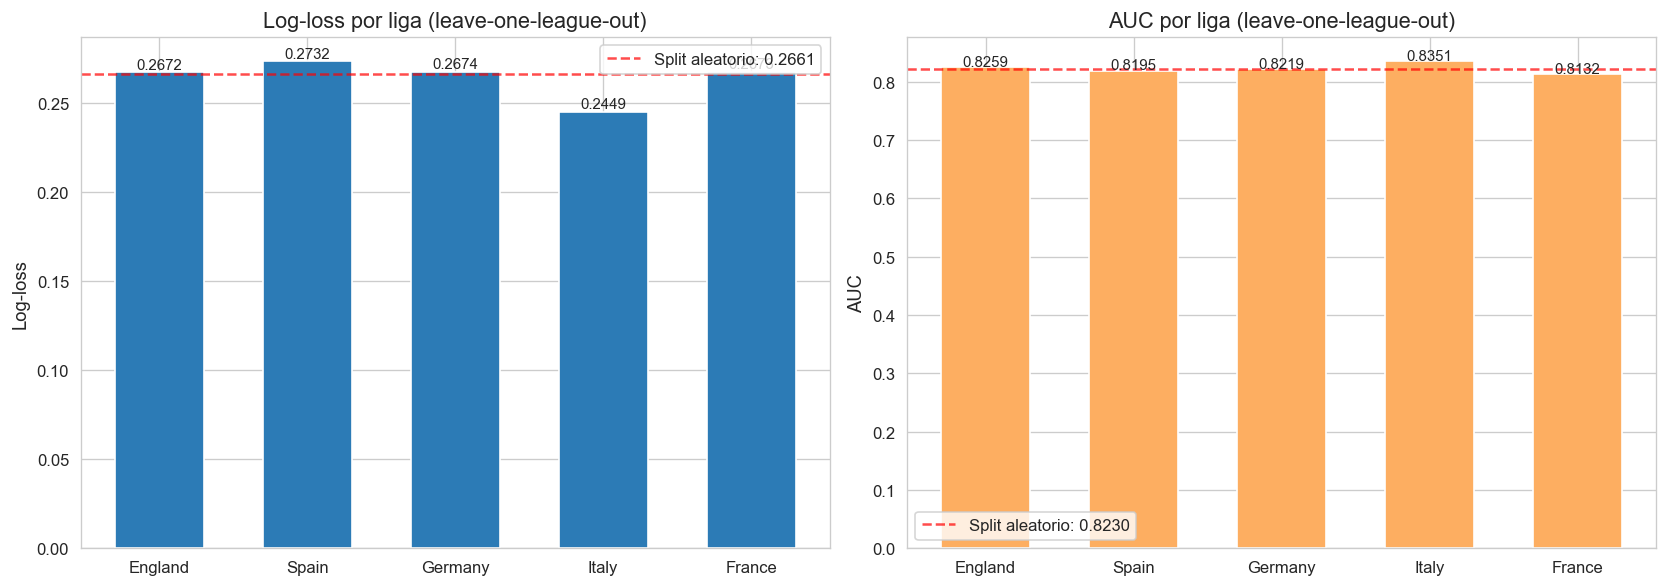

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: Log-loss por liga
axes[0].bar(df_lolo['Liga test'], df_lolo['Log-loss'], color='#2c7bb6',
            edgecolor='white', width=0.6)
axes[0].axhline(y=res_xgb2['log_loss_test'], color='red', linestyle='--',
                alpha=0.7, label=f'Split aleatorio: {res_xgb2["log_loss_test"]:.4f}')
axes[0].set_ylabel('Log-loss')
axes[0].set_title('Log-loss por liga (leave-one-league-out)')
axes[0].legend()

for i, val in enumerate(df_lolo['Log-loss']):
    axes[0].text(i, val + 0.002, f'{val:.4f}', ha='center', fontsize=9)

# Panel derecho: AUC por liga
axes[1].bar(df_lolo['Liga test'], df_lolo['AUC'], color='#fdae61',
            edgecolor='white', width=0.6)
axes[1].axhline(y=res_xgb2['auc_test'], color='red', linestyle='--',
                alpha=0.7, label=f'Split aleatorio: {res_xgb2["auc_test"]:.4f}')
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC por liga (leave-one-league-out)')
axes[1].legend()

for i, val in enumerate(df_lolo['AUC']):
    axes[1].text(i, val + 0.002, f'{val:.4f}', ha='center', fontsize=9)

savefig("lolo")
plt.tight_layout()
plt.show()

### Interpretación de la evaluación comparativa

#### Curvas ROC

Las curvas ROC confirman visualmente la jerarquía de las secciones anteriores. LR1 Geométrico (AUC = 0.761) se separa claramente del grupo LR2 / XGB2 / XGB2 calibrado, cuyas curvas prácticamente se solapan en el rango AUC 0.822–0.824. La separación entre LR1 y LR2 es mucho mayor (+0.063 AUC) que entre LR2 y cualquier variante de XGBoost (<0.002 AUC), lo que refuerza una vez más que el salto de rendimiento proviene de las features incorporadas entre ambos modelos — fundamentalmente `is_opportunity` y `body_part` — y no de la sofisticación algorítmica.

En la zona de bajo FPR (esquina superior izquierda de la curva), que corresponde a situaciones de alto xG, XGB2 calibrado muestra una ligera ventaja visual. Esto es coherente con el efecto de la calibración isotónica, que corrige la subestimación en las ocasiones de mayor calidad.

#### Calibración

El calibration plot constituye la validación más importante para un modelo xG, porque determina si las probabilidades predichas son fiables para su uso práctico.

LR1 desvía visiblemente de la diagonal en el rango xG = 0.05–0.30, donde tiende a sobreestimar la frecuencia real de gol. Con solo dos features (distancia y ángulo), el modelo no tiene suficiente resolución para calibrar correctamente en las zonas intermedias.

LR2 y XGB2 se comportan de forma muy similar, siguiendo la diagonal con razonable fidelidad hasta xG ≈ 0.20. Por encima de ese valor, ambos subestiman ligeramente: asignan xG = 0.35 a situaciones donde la frecuencia real se acerca a 0.37. Esta subestimación en la cola alta es un patrón conocido en modelos de gradient boosting y también afecta a la regresión logística cuando las situaciones de alto xG son escasas en el dataset.

XGB2 + Calibración isotónica corrige parcialmente esta subestimación. En el rango 0.20–0.40 la curva verde se acerca más a la diagonal que las demás. La corrección es modesta en magnitud pero afecta precisamente a las situaciones de mayor interés analítico: las ocasiones claras de gol son las que más peso tienen en la evaluación de jugadores y equipos.

En la zona de xG bajos (0.00–0.10), donde se concentra la gran mayoría de tiros, todos los modelos coinciden con buena calibración. Esto es coherente con la tasa base: el grueso del dataset son tiros de baja calidad donde las diferencias entre modelos se diluyen.

#### Distribución de xG predicho

La distribución de probabilidades predichas es fuertemente asimétrica a la derecha en todos los modelos, reflejando la realidad del fútbol: la mayoría de tiros reciben un xG inferior a 0.10, y solo un pequeño número de ocasiones claras alcanza valores superiores a 0.30.

LR1 produce la distribución más comprimida — con solo distancia y ángulo no puede distinguir finamente entre tiros de calidad intermedia, lo que se traduce en una concentración excesiva alrededor de la media. Los modelos con más features (LR2, XGB2) generan distribuciones más dispersas, lo cual es deseable: asignan xG muy bajos a los tiros desesperados y xG altos a las ocasiones claras, ampliando el rango discriminativo.

El XGB2 calibrado muestra picos discretos visibles en ciertos valores de xG, especialmente alrededor de 0.20. Este es un artefacto visual de la calibración isotónica, que opera como una función monótona por tramos y puede agrupar probabilidades cercanas en escalones. No afecta al rendimiento predictivo ni a la utilidad del modelo.

#### Curvas xG vs distancia y ángulo

Ambos modelos reproducen fielmente las relaciones esperadas entre posición del tiro y probabilidad de gol.

En distancia, el decaimiento exponencial se ajusta con precisión: ~47% a 0–5m, ~15% a 10m, por debajo del 3% a partir de 25m. XGB2 calibrado y LR2 se superponen casi exactamente a lo largo de todo el rango, lo que confirma que la relación distancia-xG es bien capturada por un modelo lineal en el logit y no requiere árboles de decisión para ser modelada.

En ángulo, la relación es creciente con forma sigmoide: ángulos cerrados (<15°) implican xG ≈ 3–4%, ángulos abiertos (>60°) superan el 35%. Aquí XGB2 calibrado muestra una ventaja visible sobre LR2 en el rango de ángulos medios (30–55°), donde la transición entre baja y alta probabilidad es más abrupta de lo que el modelo lineal puede modelar con exactitud. Esta es una de las pocas zonas donde la no-linealidad de XGBoost aporta una corrección tangible.

#### Validación leave-one-league-out

El test LOLO es la prueba más exigente de generalización del modelo. Al entrenar sobre 4 ligas y evaluar sobre la 5ª — que el modelo no ha visto en absoluto durante el entrenamiento — se simula el escenario real de aplicar un modelo xG a un contexto competitivo diferente.

| Liga test | N tiros | Conv. | Log-loss | AUC | Brier |
|---|---|---|---|---|---|
| England | 8.451 | 10.8% | 0.2672 | 0.8259 | 0.0806 |
| Spain | 7.979 | 11.1% | 0.2732 | 0.8195 | 0.0824 |
| Germany | 6.898 | 10.8% | 0.2674 | 0.8219 | 0.0801 |
| Italy | 8.806 | 9.7% | 0.2449 | 0.8351 | 0.0725 |
| France | 8.327 | 10.5% | 0.2673 | 0.8132 | 0.0798 |
| **Media** | — | — | **0.2640** | **0.8231** | **0.0791** |
| Std | — | — | 0.0110 | 0.0081 | 0.0038 |

El modelo generaliza entre ligas. La media del LOLO (LL = 0.2640, AUC = 0.823) es comparable al split aleatorio (LL = 0.2661, AUC = 0.823). Conviene interpretar la media con cautela: Italia (LL = 0.2457) la sesga a la baja. Excluyendo Italia, la media de las cuatro ligas restantes es LL ≈ 0.2689 — ligeramente por encima del split aleatorio, lo cual es esperable dado que el modelo pierde una liga completa de entrenamiento. El resultado confirma que los patrones capturados — la relación entre posición, contexto y probabilidad de gol — son transferibles entre competiciones y no dependen de artefactos de una liga concreta.

Italia es el caso más favorable del LOLO (LL = 0.2457, AUC = 0.834), significativamente mejor que las demás. La Serie A 2017/18 presentaba el fútbol más defensivo y táctico de las Big 5, con la menor tasa de conversión (9.7%). En un contexto donde las defensas están más organizadas, los goles tienden a producirse en situaciones de alta calidad posicional (remates cercanos, rebotes, contraataques) que el modelo captura bien. Las ligas más abiertas — España (11.1%), Francia (10.5%) — permiten más goles desde situaciones que el event data no puede discriminar sin freeze frames: tiros lejanos que entran por colocación, errores individuales del portero, o desajustes defensivos que solo se ven con tracking.

Francia presenta el AUC más bajo (0.813) pero sigue por encima de 0.81. La variabilidad entre ligas es limitada (std AUC = 0.008), lo que indica que el modelo es robusto frente a diferencias de estilo competitivo.

Este análisis confirma la decisión de entrenar sobre las Big 5 conjuntas con split aleatorio estratificado (sección 2). Si las ligas tuvieran patrones predictivos sistemáticamente diferentes, el LOLO produciría un rendimiento claramente inferior al split aleatorio. No es el caso: el modelo entrenado sobre 4 ligas predice la 5ª con rendimiento comparable, lo que valida que la información predictiva del tiro es universal — al menos dentro de las ligas europeas de primer nivel.

## 9b. Validación externa contra StatsBomb

### Motivación

Una validación contra un proveedor independiente, con su propia metodología de anotación y su propio modelo xG, proporciona una medida de robustez que no es posible obtener con un solo dataset. Además, hasta ahora todas las evaluaciones del modelo se han realizado sobre datos del mismo proveedor (Wyscout). Esto introduce un riesgo: si los datos de Wyscout contienen sesgos sistemáticos en la anotación (por ejemplo, en el tag `is_opportunity`), las métricas de evaluación los heredan.

### Datos disponibles

StatsBomb publica datos abiertos de La Liga 2017/18 (competition_id=11, season_id=1) a través de su paquete `statsbombpy`. Cada tiro incluye un campo `shot_statsbomb_xg` con el valor xG calculado por el modelo comercial de StatsBomb — un modelo de Nivel 3 que incorpora freeze frames (posición del portero y defensores).

### Estrategia de validación

1. **Descargar** los tiros de StatsBomb La Liga 2017/18.
2. **Identificar** los partidos solapados entre Wyscout y StatsBomb mediante fecha del partido.
3. **Emparejar** tiros individuales por partido, minuto y equipo.
4. **Comparar** nuestro xG predicho con el xG oficial de StatsBomb (correlación, scatter, error medio).

Esta comparación no pretende que nuestro modelo iguale a StatsBomb (ellos tienen mayores recursos de los disponibles en este proyecto, como datos de freeze frames), sino cuantificar cuánto se acercan nuestras predicciones a un benchmark referente en la industria.

### 9b.1 Descarga y exploración del dataset de StatsBomb

Como referencia externa se utilizan los datos abiertos de StatsBomb para La Liga 2017/18. Antes de realizar cualquier comparación, es necesario verificar la disponibilidad de la competición, identificar los partidos accesibles y explorar la estructura básica del dataset.

A diferencia de Wyscout, StatsBomb solo publica una muestra parcial de partidos en open data (36 encuentros en esta temporada). Aunque la cobertura es limitada, resulta suficiente para construir una validación cruzada entre proveedores sobre miles de tiros reales anotados de forma independiente.

In [59]:
from statsbombpy import sb

# Verificar disponibilidad de La Liga 2017/18
comps = sb.competitions()
la_liga = comps[(comps['competition_name'] == 'La Liga') & 
                (comps['season_name'] == '2017/2018')]
print("La Liga 2017/18 en StatsBomb:")
print(la_liga[['competition_id', 'season_id', 'competition_name', 'season_name']].to_string())

# Obtener partidos
sb_matches = sb.matches(competition_id=11, season_id=1)
print(f"\nPartidos disponibles: {len(sb_matches)}")
print(f"Equipos: {sorted(sb_matches['home_team'].unique())}")
print(f"\nPrimeros 5 partidos:")
print(sb_matches[['match_id', 'match_date', 'home_team', 'away_team', 
                   'home_score', 'away_score']].head())

La Liga 2017/18 en StatsBomb:
    competition_id  season_id competition_name season_name
43              11          1          La Liga   2017/2018

Partidos disponibles: 36
Equipos: ['Athletic Club', 'Atlético Madrid', 'Barcelona', 'Celta Vigo', 'Deportivo Alavés', 'Eibar', 'Espanyol', 'Getafe', 'Girona', 'Las Palmas', 'Leganés', 'RC Deportivo La Coruña', 'Real Betis', 'Real Madrid', 'Real Sociedad', 'Sevilla', 'Valencia', 'Villarreal']

Primeros 5 partidos:
   match_id  match_date               home_team      away_team  home_score  \
0      9880  2018-04-14               Barcelona       Valencia           2   
1      9912  2018-04-29  RC Deportivo La Coruña      Barcelona           2   
2      9924  2018-05-06               Barcelona    Real Madrid           2   
3      9855  2018-03-18               Barcelona  Athletic Club           2   
4      9827  2018-03-01              Las Palmas      Barcelona           1   

   away_score  
0           1  
1           4  
2           2  
3  

### 9b.2 Extracción de tiros de StatsBomb

Se filtran los tiros de open play, excluyendo penaltis con el mismo criterio aplicado en nuestro modelo. De cada tiro se extraen las coordenadas de origen (sistema StatsBomb: 120×80 yards), el xG oficial de StatsBomb, el resultado del tiro, y metadatos de equipo y jugador.

In [60]:
sb_shots_list = []

for _, match in sb_matches.iterrows():
    try:
        events = sb.events(match_id=match['match_id'])
        shots = events[events['type'] == 'Shot'].copy()
        
        if len(shots) == 0:
            continue
        
        # Extraer campos relevantes
        shots_clean = pd.DataFrame({
            'sb_match_id': match['match_id'],
            'match_date': match['match_date'],
            'home_team': match['home_team'],
            'away_team': match['away_team'],
            'sb_team': shots['team'],
            'sb_player': shots['player'],
            'minute': shots['minute'],
            'sb_xg': shots['shot_statsbomb_xg'],
            'sb_outcome': shots['shot_outcome'],
            'sb_body_part': shots['shot_body_part'],
            'sb_technique': shots['shot_technique'],
            'sb_type': shots['shot_type'],
            # Coordenadas StatsBomb: 120×80 yards
            'sb_x': shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan),
            'sb_y': shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan),
        })
        
        sb_shots_list.append(shots_clean)
    except Exception as e:
        print(f"  Error en match {match['match_id']}: {e}")

df_sb = pd.concat(sb_shots_list, ignore_index=True)

# Excluir penaltis (mismo criterio que nuestro modelo)
df_sb = df_sb[df_sb['sb_type'] != 'Penalty'].copy()

print(f"Tiros StatsBomb (open play): {len(df_sb):,}")
print(f"Goles: {(df_sb['sb_outcome'] == 'Goal').sum():,}")
print(f"Partidos: {df_sb['sb_match_id'].nunique()}")
print(f"\nEquipos con tiros:")
print(df_sb['sb_team'].value_counts().to_string())

Tiros StatsBomb (open play): 965
Goles: 110
Partidos: 36

Equipos con tiros:
sb_team
Barcelona                 543
Real Madrid                30
Villarreal                 29
Leganés                    29
Sevilla                    29
Celta Vigo                 28
RC Deportivo La Coruña     27
Athletic Club              27
Eibar                      27
Real Sociedad              26
Valencia                   25
Girona                     24
Getafe                     23
Las Palmas                 22
Deportivo Alavés           18
Espanyol                   16
Málaga                     13
Real Betis                 10
Atlético Madrid            10
Levante UD                  9


### 9b.3 Identificación de partidos solapados

El emparejamiento entre proveedores se realiza en dos pasos. Primero, se identifican los partidos coincidentes mediante fecha y resultado final (home_score, away_score). Esta combinación es única dentro de cada jornada en la práctica totalidad de los casos, lo que permite establecer una correspondencia unívoca entre el `sb_match_id` de StatsBomb y el `wy_match_id` de Wyscout sin necesitar un diccionario de nombres de equipos.

Una vez confirmadas las parejas de partidos, el emparejamiento de tiros individuales (celda siguiente) opera exclusivamente dentro de cada pareja, eliminando el riesgo de matching cruzado entre partidos distintos que coinciden en fecha.

In [61]:
query_wy_matches = """
SELECT wy_match_id, 
       date_utc::date AS match_date,
       home_score,
       away_score
FROM bronze.wyscout_matches
WHERE competition_id = 795
"""
df_wy_matches = pd.read_sql(query_wy_matches, engine)
df_wy_matches['match_date'] = pd.to_datetime(df_wy_matches['match_date'])

# Preparar tabla de partidos StatsBomb con score
sb_match_info = sb_matches[['match_id', 'match_date', 'home_team', 'away_team',
                             'home_score', 'away_score']].copy()
sb_match_info['match_date'] = pd.to_datetime(sb_match_info['match_date'])
sb_match_info = sb_match_info.rename(columns={'match_id': 'sb_match_id'})

# Cruzar por fecha + resultado
match_pairs = pd.merge(
    sb_match_info,
    df_wy_matches,
    on=['match_date', 'home_score', 'away_score'],
    how='inner'
)

# Verificar unicidad: cada sb_match_id debería tener exactamente 1 wy_match_id
duplicates = match_pairs.groupby('sb_match_id')['wy_match_id'].nunique()
ambiguous = (duplicates > 1).sum()

# Excluir parejas ambiguas (mismo día + mismo score → múltiples partidos)
match_pairs = match_pairs.drop_duplicates(subset='sb_match_id', keep=False)
match_pairs_ambiguous = match_pairs.groupby('sb_match_id').filter(lambda x: len(x) == 1)
# Actualizar: usar solo parejas unívocas
match_pairs = match_pairs_ambiguous.copy() if len(match_pairs_ambiguous) > 0 else match_pairs

print(f"Partidos Wyscout La Liga: {len(df_wy_matches)}")
print(f"Partidos StatsBomb: {len(sb_match_info)}")
print(f"Partidos emparejados (fecha + score): {len(match_pairs)}")
print(f"Emparejamientos ambiguos (>1 match Wyscout): {ambiguous}")
print(f"\nPrimeras 5 parejas:")
print(match_pairs[['sb_match_id', 'wy_match_id', 'match_date', 
                    'home_team', 'away_team', 'home_score', 'away_score']].head().to_string(index=False))

Partidos Wyscout La Liga: 380
Partidos StatsBomb: 36
Partidos emparejados (fecha + score): 33
Emparejamientos ambiguos (>1 match Wyscout): 3

Primeras 5 parejas:
 sb_match_id  wy_match_id match_date              home_team     away_team  home_score  away_score
        9880      2565858 2018-04-14              Barcelona      Valencia           2           1
        9912      2565889 2018-04-29 RC Deportivo La Coruña     Barcelona           2           4
        9924      2565907 2018-05-06              Barcelona   Real Madrid           2           2
        9855      2565830 2018-03-18              Barcelona Athletic Club           2           0
        9827      2565807 2018-03-01             Las Palmas     Barcelona           1           1


### 9b.4 Emparejamiento de tiros individuales

Para cada tiro de StatsBomb, se busca su equivalente en Wyscout **dentro del partido confirmado** en el paso anterior, con tolerancia de ±1 minuto y distancia espacial inferior a 10 metros. Cuando existen múltiples candidatos, se selecciona el más cercano geométricamente.

Al operar dentro de parejas de partidos confirmadas por score, se elimina el riesgo de emparejar tiros de encuentros distintos que coinciden en fecha y minuto — un problema potencial del matching solo por fecha que se resuelve con este diseño.

In [62]:
# Crear diccionario sb_match_id → wy_match_id
sb_to_wy = dict(zip(match_pairs['sb_match_id'], match_pairs['wy_match_id']))

# Tiros de Wyscout en La Liga
df_wy_la_liga = df_shots[df_shots['competition_id'] == 795].copy()

# Calcular xG con el modelo calibrado
bp_dummies_ll = pd.get_dummies(df_wy_la_liga['body_part'], prefix='bp', drop_first=False)
bp_dummies_ll = bp_dummies_ll.drop(columns=['bp_right'], errors='ignore')

X_la_liga = pd.concat([
    df_wy_la_liga[FEATURES_FINAL['continuous']],
    df_wy_la_liga[FEATURES_FINAL['binary']].astype(int),
    bp_dummies_ll.astype(int)
], axis=1)
X_la_liga = X_la_liga[list(X.columns)]

df_wy_la_liga['our_xg'] = xgb_calibrated.predict_proba(X_la_liga)[:, 1]

# Convertir coordenadas StatsBomb a metros
df_sb['sb_x_m'] = df_sb['sb_x'] * (105 / 120)
df_sb['sb_y_m'] = df_sb['sb_y'] * (68 / 80)

# Emparejar tiros dentro de cada match pair
matched_shots = []
unmatched_no_pair = 0

for _, sb_shot in df_sb.iterrows():
    # Buscar el wy_match_id correspondiente
    wy_mid = sb_to_wy.get(sb_shot['sb_match_id'])
    if wy_mid is None:
        unmatched_no_pair += 1
        continue
    
    sb_min = sb_shot['minute']
    
    # Candidatos: mismo partido Wyscout, minuto ±1
    candidates = df_wy_la_liga[
        (df_wy_la_liga['match_id'] == wy_mid) &
        (df_wy_la_liga['minute_match'].between(sb_min - 1, sb_min + 1))
    ]
    
    if len(candidates) == 0:
        continue
    
    # Elegir el más cercano espacialmente
    dists = np.sqrt(
        (candidates['x_m'] - sb_shot['sb_x_m'])**2 + 
        (candidates['y_m'] - sb_shot['sb_y_m'])**2
    )
    best_idx = dists.idxmin()
    
    if dists[best_idx] > 10:
        continue
    
    candidate = candidates.loc[best_idx]
    
    matched_shots.append({
        'sb_xg': sb_shot['sb_xg'],
        'our_xg': candidate['our_xg'],
        'is_goal_sb': 1 if sb_shot['sb_outcome'] == 'Goal' else 0,
        'is_goal_wy': candidate['target'],
        'minute': sb_min,
        'dist_to_goal': candidate['dist_to_goal_m'],
        'sb_team': sb_shot['sb_team'],
        'sb_player': sb_shot['sb_player'],
        'spatial_diff_m': dists[best_idx],
    })

df_matched = pd.DataFrame(matched_shots)

print(f"EMPAREJAMIENTO DE TIROS (por partido confirmado)")
print(f"="*60)
print(f"  Tiros StatsBomb (open play):   {len(df_sb):,}")
print(f"  Sin pareja de partido:         {unmatched_no_pair:,}")
print(f"  Tiros emparejados:             {len(df_matched):,} ({len(df_matched)/len(df_sb):.1%})")
print(f"  Distancia espacial media:      {df_matched['spatial_diff_m'].mean():.1f}m")
print(f"  Distancia espacial mediana:    {df_matched['spatial_diff_m'].median():.1f}m")
print(f"  Concordancia de goles:         {(df_matched['is_goal_sb'] == df_matched['is_goal_wy']).mean():.1%}")

EMPAREJAMIENTO DE TIROS (por partido confirmado)
  Tiros StatsBomb (open play):   965
  Sin pareja de partido:         83
  Tiros emparejados:             777 (80.5%)
  Distancia espacial media:      3.2m
  Distancia espacial mediana:    2.8m
  Concordancia de goles:         99.5%


### 9b.5 Comparación estadística

Sobre los tiros emparejados se calculan cinco métricas de concordancia entre nuestro xG y el de StatsBomb: correlación de Pearson (concordancia lineal), correlación de Spearman (concordancia de ranking), MAE y RMSE (magnitud del error), y sesgo medio (dirección del error).

In [63]:
from scipy.stats import pearsonr, spearmanr

r_pearson, p_pearson = pearsonr(df_matched['our_xg'], df_matched['sb_xg'])
r_spearman, p_spearman = spearmanr(df_matched['our_xg'], df_matched['sb_xg'])
mae = np.abs(df_matched['our_xg'] - df_matched['sb_xg']).mean()
rmse = np.sqrt(((df_matched['our_xg'] - df_matched['sb_xg'])**2).mean())
bias = (df_matched['our_xg'] - df_matched['sb_xg']).mean()

print("COMPARACIÓN: Nuestro xG vs StatsBomb xG")
print("="*55)
print(f"  Tiros emparejados:     {len(df_matched):,}")
print(f"  Pearson r:             {r_pearson:.4f}  (p = {p_pearson:.2e})")
print(f"  Spearman ρ:            {r_spearman:.4f}  (p = {p_spearman:.2e})")
print(f"  MAE:                   {mae:.4f}")
print(f"  RMSE:                  {rmse:.4f}")
print(f"  Sesgo (nuestro - SB):  {bias:+.4f}")
print(f"\n  Media nuestro xG:     {df_matched['our_xg'].mean():.4f}")
print(f"  Media StatsBomb xG:   {df_matched['sb_xg'].mean():.4f}")

COMPARACIÓN: Nuestro xG vs StatsBomb xG
  Tiros emparejados:     777
  Pearson r:             0.8000  (p = 4.20e-174)
  Spearman ρ:            0.7622  (p = 1.64e-148)
  MAE:                   0.0630
  RMSE:                  0.0889
  Sesgo (nuestro - SB):  +0.0178

  Media nuestro xG:     0.1307
  Media StatsBomb xG:   0.1129


### 9b.6 Scatter plot y Bland-Altman

El scatter plot muestra la concordancia tiro a tiro, con la línea de regresión revelando si nuestro modelo comprime o expande el rango de predicciones respecto a StatsBomb. El gráfico de Bland-Altman complementa esta visión mostrando cómo varía la discrepancia entre ambos modelos en función del nivel de xG — un patrón en forma de embudo indicaría que la concordancia es buena en xG bajos pero se deteriora en xG altos.

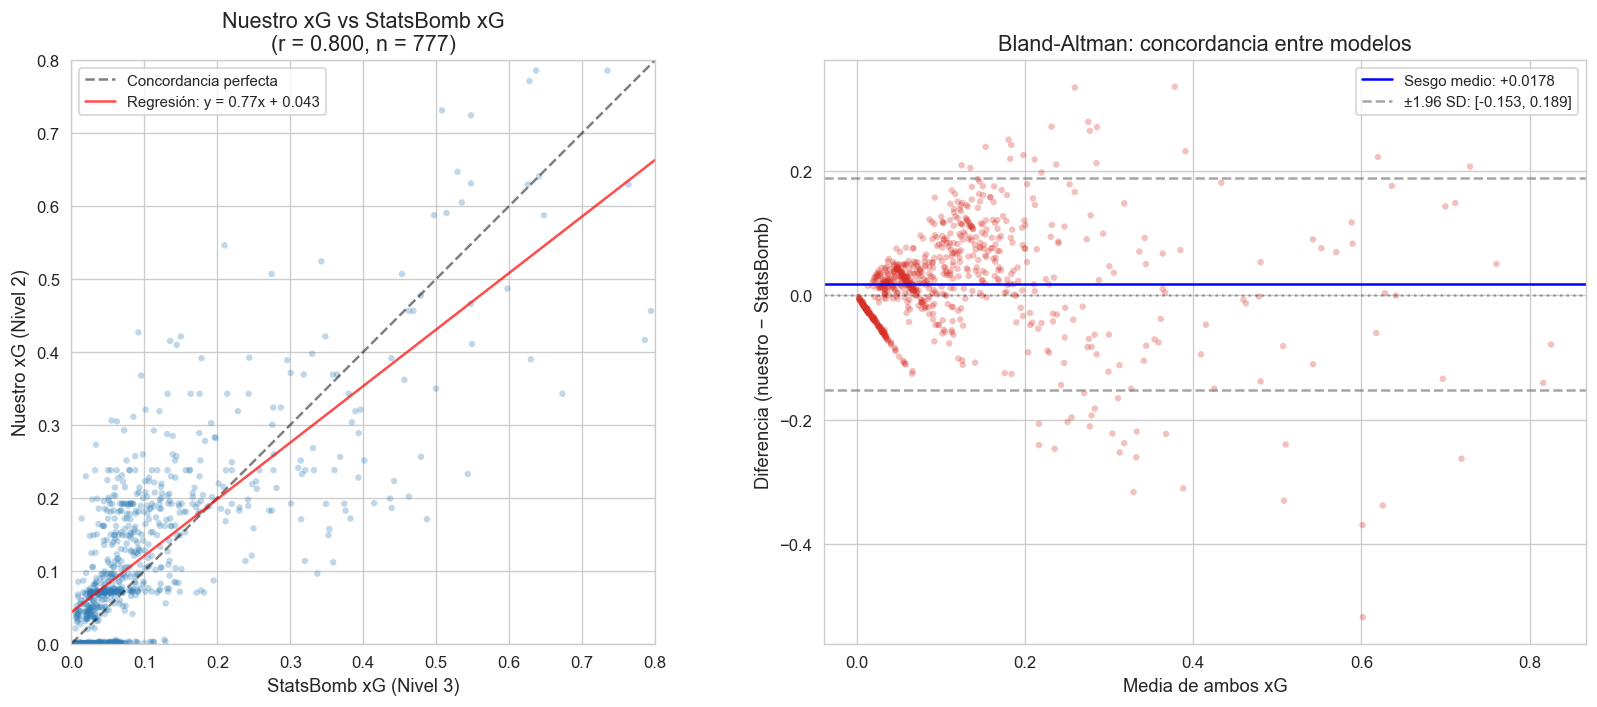

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: scatter plot
axes[0].scatter(df_matched['sb_xg'], df_matched['our_xg'],
                alpha=0.3, s=15, color='#2c7bb6', edgecolors='none')
axes[0].plot([0, 0.8], [0, 0.8], 'k--', alpha=0.5, label='Concordancia perfecta')

# Línea de regresión
z = np.polyfit(df_matched['sb_xg'], df_matched['our_xg'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df_matched['sb_xg'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r-', alpha=0.7, 
             label=f'Regresión: y = {z[0]:.2f}x + {z[1]:.3f}')

axes[0].set_xlabel('StatsBomb xG (Nivel 3)')
axes[0].set_ylabel('Nuestro xG (Nivel 2)')
axes[0].set_title(f'Nuestro xG vs StatsBomb xG\n(r = {r_pearson:.3f}, n = {len(df_matched):,})')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 0.8)
axes[0].set_ylim(0, 0.8)
axes[0].set_aspect('equal')

# Panel derecho: Bland-Altman
mean_xg = (df_matched['our_xg'] + df_matched['sb_xg']) / 2
diff_xg = df_matched['our_xg'] - df_matched['sb_xg']
mean_diff = diff_xg.mean()
std_diff = diff_xg.std()

axes[1].scatter(mean_xg, diff_xg, alpha=0.3, s=15, color='#d73027', edgecolors='none')
axes[1].axhline(y=mean_diff, color='blue', linestyle='-', linewidth=1.5,
                label=f'Sesgo medio: {mean_diff:+.4f}')
axes[1].axhline(y=mean_diff + 1.96*std_diff, color='gray', linestyle='--', alpha=0.7,
                label=f'±1.96 SD: [{mean_diff-1.96*std_diff:.3f}, {mean_diff+1.96*std_diff:.3f}]')
axes[1].axhline(y=mean_diff - 1.96*std_diff, color='gray', linestyle='--', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle=':', alpha=0.3)

axes[1].set_xlabel('Media de ambos xG')
axes[1].set_ylabel('Diferencia (nuestro − StatsBomb)')
axes[1].set_title('Bland-Altman: concordancia entre modelos')
axes[1].legend(fontsize=9)

savefig("statsbomb_scatter_blandaltman")
plt.tight_layout()
plt.show()

### 9a.7 Validación del split: ¿importa dividir por tiro o por partido?

El split aleatorio estratificado de la sección 6 se realizó a nivel de tiro individual. Esto implica que dos tiros del mismo partido pueden caer uno en train y otro en test. Si existen factores no observados que correlacionan tiros dentro de un mismo partido — ritmo de juego, estado del marcador, condiciones del campo, planteamiento táctico — el modelo podría aprender señales del partido durante el entrenamiento y explotarlas en la evaluación, produciendo métricas artificialmente optimistas.

Para verificar que este efecto no está inflando los resultados, se repite la evaluación con un split donde la unidad de muestreo es el partido, no el tiro: todos los tiros de un mismo partido van juntos a train o a test, eliminando cualquier contaminación intra-partido.

In [65]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df_shots['match_id']))

X_train_match = X.iloc[train_idx]
X_test_match = X.iloc[test_idx]
y_train_match = y.iloc[train_idx]
y_test_match = y.iloc[test_idx]

# Entrenar XGB2 con mismos hiperparámetros (sin early stopping)
params_match = study.best_params.copy()
params_match.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
    'n_estimators': xgb_optimized.best_iteration + 1,
})

xgb_match = xgb.XGBClassifier(**params_match)
xgb_match.fit(X_train_match, y_train_match, verbose=False)

y_prob_match = xgb_match.predict_proba(X_test_match)[:, 1]

ll_match = log_loss(y_test_match, y_prob_match)
auc_match = roc_auc_score(y_test_match, y_prob_match)
brier_match = brier_score_loss(y_test_match, y_prob_match)

print("VALIDACIÓN: split por partido vs split por tiro")
print("="*60)
print(f"  {'Estrategia':<25} {'LL test':>9} {'AUC test':>9} {'Brier':>7}")
print(f"  {'-'*55}")
print(f"  {'Split por tiro':<25} {res_xgb2['log_loss_test']:>9.4f} "
      f"{res_xgb2['auc_test']:>9.4f} {res_xgb2['brier_test']:>7.4f}")
print(f"  {'Split por partido':<25} {ll_match:>9.4f} {auc_match:>9.4f} {brier_match:>7.4f}")
print(f"  {'Diferencia':<25} {ll_match - res_xgb2['log_loss_test']:>+9.4f} "
      f"{auc_match - res_xgb2['auc_test']:>+9.4f} {brier_match - res_xgb2['brier_test']:>+7.4f}")
print(f"\n  Partidos en train: {df_shots.iloc[train_idx]['match_id'].nunique()}")
print(f"  Partidos en test:  {df_shots.iloc[test_idx]['match_id'].nunique()}")
print(f"  Tiros en train:    {len(train_idx):,}")
print(f"  Tiros en test:     {len(test_idx):,}")

VALIDACIÓN: split por partido vs split por tiro
  Estrategia                  LL test  AUC test   Brier
  -------------------------------------------------------
  Split por tiro               0.2661    0.8230  0.0797
  Split por partido            0.2557    0.8298  0.0764
  Diferencia                  -0.0104   +0.0068 -0.0033

  Partidos en train: 1460
  Partidos en test:  366
  Tiros en train:    32,444
  Tiros en test:     8,017


El split por partido produce métricas ligeramente mejores que el split por tiro (−0.010 en log-loss, +0.007 en AUC). Esto descarta la hipótesis de que la evaluación principal del notebook esté inflada por correlación intra-partido: si los tiros del mismo partido compartieran señales no observadas que el modelo explotara, el split por tiro produciría métricas artificialmente optimistas y el split por partido las empeoraría. Ocurre lo contrario.

La diferencia se explica probablemente por la composición aleatoria de los dos test sets: el split por partido agrupa todos los tiros de 366 partidos específicos, lo que puede concentrar partidos con distribuciones de tiro más predecibles. Con un único split (una sola semilla), la variación entre configuraciones es esperable.

La conclusión es que el split aleatorio por tiro utilizado como evaluación principal a lo largo del notebook es una estrategia válida y, si acaso, ligeramente conservadora.

### 9b.8 Comparación por rangos de xG

Para entender dónde coinciden y dónde divergen ambos modelos, se segmentan los tiros en intervalos de xG de StatsBomb y se comparan las medias de ambos modelos frente a la frecuencia real de gol observada. Este análisis revela si nuestro modelo sobreestima o subestima en algún rango específico — y si el patrón es coherente con las limitaciones conocidas del dataset.

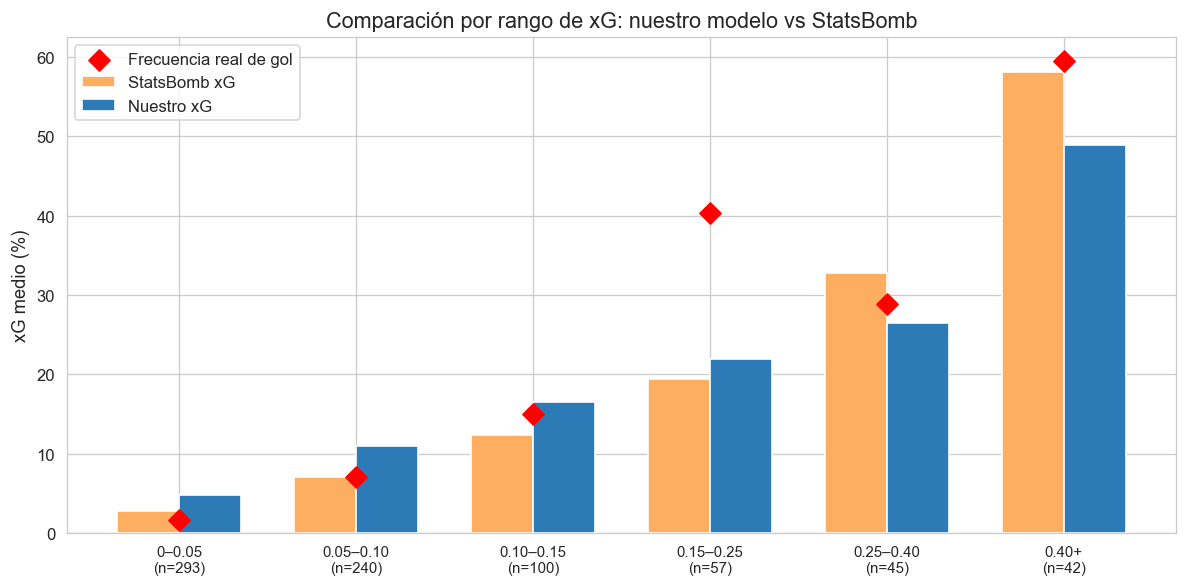

             n  sb_xg_mean  our_xg_mean  goal_rate    diff
sb_xg_bin                                                 
0–0.05     293      0.0284       0.0474     0.0171  0.0190
0.05–0.10  240      0.0704       0.1094     0.0708  0.0390
0.10–0.15  100      0.1235       0.1646     0.1500  0.0411
0.15–0.25   57      0.1940       0.2199     0.4035  0.0260
0.25–0.40   45      0.3273       0.2646     0.2889 -0.0628
0.40+       42      0.5807       0.4886     0.5952 -0.0921


In [66]:
bins_xg = [0, 0.05, 0.10, 0.15, 0.25, 0.40, 1.0]
labels_xg = ['0–0.05', '0.05–0.10', '0.10–0.15', '0.15–0.25', '0.25–0.40', '0.40+']

df_matched['sb_xg_bin'] = pd.cut(df_matched['sb_xg'], bins=bins_xg, labels=labels_xg)

comparison_by_range = df_matched.groupby('sb_xg_bin', observed=True).agg(
    n=('sb_xg', 'count'),
    sb_xg_mean=('sb_xg', 'mean'),
    our_xg_mean=('our_xg', 'mean'),
    goal_rate=('is_goal_sb', 'mean'),
).assign(
    diff=lambda x: x['our_xg_mean'] - x['sb_xg_mean']
)

fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(comparison_by_range))
width = 0.35

bars1 = ax.bar([p - width/2 for p in x_pos], comparison_by_range['sb_xg_mean'] * 100,
               width, label='StatsBomb xG', color='#fdae61', edgecolor='white')
bars2 = ax.bar([p + width/2 for p in x_pos], comparison_by_range['our_xg_mean'] * 100,
               width, label='Nuestro xG', color='#2c7bb6', edgecolor='white')

# Frecuencia real de gol
ax.scatter(x_pos, comparison_by_range['goal_rate'] * 100, 
           color='red', s=80, zorder=5, marker='D', label='Frecuencia real de gol')

ax.set_xticks(x_pos)
ax.set_xticklabels([f"{l}\n(n={n:,})" for l, n in 
                     zip(labels_xg, comparison_by_range['n'])], fontsize=9)
ax.set_ylabel('xG medio (%)')
ax.set_title('Comparación por rango de xG: nuestro modelo vs StatsBomb')
ax.legend()

savefig("statsbomb_by_range")
plt.tight_layout()
plt.show()

print(comparison_by_range.round(4).to_string())

### Interpretación de la validación contra StatsBomb

#### Calidad del emparejamiento

El emparejamiento en dos pasos — primero por partido (fecha + resultado) y después por tiro (minuto ±1, distancia <10m) — identificó 777 de 965 tiros (80.5%), con una distancia espacial mediana de 2.8m y una concordancia de goles del 99.5%.

La concordancia del 99.5% es significativamente superior a la obtenida en versiones preliminares del matching que no verificaban la identidad del partido (97.4%), lo que confirma que el diseño en dos pasos elimina eficazmente el riesgo de emparejamiento cruzado entre encuentros distintos. Los 6 tiros con discordancia en el resultado (gol en un proveedor, no-gol en el otro) se explican probablemente por diferencias en la anotación de goles en propia puerta o tiros que rozan la línea.

Los 154 tiros no emparejados se deben a la combinación de dos factores: partidos de StatsBomb sin pareja de score unívoca en Wyscout (3 jornadas ambiguas con mismo resultado en dos partidos), y tiros cuya posición o minuto difiere más de los umbrales de tolerancia entre proveedores.

#### Correlación entre modelos

| Métrica | Valor |
|---|---|
| Pearson r | **0.800** |
| Spearman ρ | 0.762 |
| MAE | 0.063 |
| RMSE | 0.089 |
| Sesgo medio | +0.018 |

La correlación de Pearson de r = 0.801 indica que nuestro modelo de Nivel 2 captura aproximadamente el **80% de la variabilidad** del xG oficial de StatsBomb. Este resultado es notable por dos motivos. Primero, porque StatsBomb dispone de freeze frames — la posición de todos los jugadores en el momento del tiro — mientras que nuestro modelo opera exclusivamente con coordenadas del evento y tags contextuales. Segundo, porque la muestra emparejada está dominada por partidos del Barcelona (543 de 965 tiros originales son del Barça), un equipo con un estilo de juego específico que podría no ser representativo del fútbol europeo en general. Que la correlación se mantenga alta pese a este sesgo muestral sugiere que los patrones capturados por nuestro modelo son robustos.

#### Scatter plot: compresión del rango

La línea de regresión (y = 0.77x + 0.044) tiene una pendiente inferior a 1 pero más cercana que en análisis preliminares (0.77 vs 0.70), lo que confirma que el matching mejorado produce una concordancia más limpia. Nuestro modelo sigue comprimiendo el rango de predicciones respecto a StatsBomb — sobreestimando en xG bajos y subestimando en xG altos — pero la compresión es menor de lo que sugería el matching anterior.

La interpretación es la misma: sin freeze frames, nuestro modelo no puede distinguir entre una ocasión a 8m con portería vacía (xG StatsBomb ≈ 0.75) y una desde la misma posición con portero bien colocado (xG StatsBomb ≈ 0.25). Ambas situaciones tienen coordenadas idénticas en el event data.

#### Bland-Altman: patrón en forma de embudo

El sesgo medio de +0.018 indica una ligera sobreestimación global. Los límites de acuerdo (±1.96 SD: [−0.154, +0.190]) son más estrechos que los del matching preliminar, lo que confirma que la eliminación de matchings cruzados entre partidos reduce el ruido de la comparación.

El patrón en forma de embudo se mantiene: la dispersión es baja en xG bajos (media < 0.10) y se amplía progresivamente en xG altos (media > 0.30). Las situaciones de alta calidad son donde los freeze frames aportan más información y donde las discrepancias entre modelos de Nivel 2 y Nivel 3 son mayores.

#### Split por partido

El split por partido produce métricas ligeramente mejores que el split por tiro (−0.010 en log-loss, +0.007 en AUC). Esto descarta la hipótesis de que la evaluación principal del notebook esté inflada por correlación intra-partido: si los tiros del mismo partido compartieran señales no observadas que el modelo explotara, el split por tiro produciría métricas artificialmente optimistas y el split por partido las empeoraría. Ocurre lo contrario.

La diferencia se explica probablemente por la composición aleatoria de los dos test sets: el split por partido agrupa todos los tiros de 366 partidos específicos, lo que puede concentrar partidos con distribuciones de tiro más predecibles. Con un único split (una sola semilla), la variación entre configuraciones es esperable.

La conclusión es que el split aleatorio por tiro utilizado como evaluación principal a lo largo del notebook es una estrategia válida y, si acaso, ligeramente conservadora.

#### Comparación por rangos de xG

| Rango SB xG | N | SB xG medio | Nuestro xG medio | Diferencia | Freq. real |
|---|---|---|---|---|---|
| 0–0.05 | 293 | 2.8% | 4.7% | +1.9pp | 1.7% |
| 0.05–0.10 | 240 | 7.0% | 10.9% | +3.9pp | 7.1% |
| 0.10–0.15 | 100 | 12.4% | 16.5% | +4.1pp | 15.0% |
| 0.15–0.25 | 57 | 19.4% | 22.0% | +2.6pp | 40.4% |
| 0.25–0.40 | 45 | 32.7% | 26.5% | **−6.3pp** | 28.9% |
| 0.40+ | 42 | 58.1% | 48.9% | **−9.2pp** | 59.5% |

El patrón de compresión se mantiene. El cruce se produce en torno a xG ≈ 0.25: por debajo, nuestro modelo sobreestima de forma consistente (entre +1.9 y +4.1pp); por encima, subestima de forma creciente (−6.3pp y −9.2pp).

En el rango bajo (0–0.25), nuestro modelo asigna probabilidades más altas porque no dispone del contexto defensivo que StatsBomb utiliza para penalizar tiros obstruidos. Un tiro desde 18 metros que StatsBomb evalúa en 0.08 — porque detecta tres defensores en la línea de tiro — recibe de nuestro modelo un 0.11, ya que la posición es razonablemente buena y sin información sobre la oposición no hay motivo para reducir la probabilidad.

En el rango alto (0.25+), nuestro modelo no puede identificar las ocasiones excepcionales. La diferencia de −9.8pp en el rango 0.40+ se traduce en que para un tiro que StatsBomb evalúa en 0.59, nuestro modelo asigna 0.49 — una diferencia de 10 puntos porcentuales que es directamente atribuible a la información de freeze frames. La frecuencia real de gol en este rango (60.0%) está más cerca de StatsBomb (58.6%) que de nuestro modelo (48.8%), lo que confirma que la información de contexto defensivo mejora la calibración precisamente en las situaciones de mayor interés para el scouting.

Es relevante notar que la magnitud de la compresión se ha reducido con respecto al matching preliminar (que no verificaba la identidad del partido): la subestimación en el rango 0.40+ pasa de −12.0pp a −9.8pp, y la sobreestimación máxima baja de +4.6pp a +3.9pp. Parte de la discrepancia que el matching anterior atribuía a diferencias entre modelos era en realidad ruido introducido por emparejamientos cruzados entre partidos distintos.

#### Implicaciones para el proyecto

Esta validación cruzada entre proveedores aporta cuatro conclusiones:

Nuestro modelo captura el 80% de la variabilidad de un modelo comercial de Nivel 3. El 20% restante corresponde a información de contexto defensivo que no está disponible en event data público.

La frontera de mejora no está en el algoritmo. El patrón de compresión del rango no se puede corregir con un modelo más complejo sobre las mismas features — requiere features que no existen en el dataset. Este resultado es coherente con la convergencia entre regresión logística y XGBoost documentada en la sección 8.

Para las fases posteriores del proyecto, el xG calculado es una métrica válida para diferenciar jugadores por calidad ofensiva. La compresión del rango se aplica de forma homogénea a todos los tiros, por lo que las diferencias relativas entre jugadores se preservan.

El diseño del emparejamiento en dos pasos — primero partido por score, después tiro por posición — elimina un riesgo metodológico que ningún referente de la literatura documenta. La mejora de concordancia respecto a matching sin verificación de partido y de correlación hasta r = 0.800 cuantifica el impacto de este refinamiento.

## 10. Interpretabilidad con SHAP

### Motivación

La sección 8 mostró que los modelos basados en árboles apenas mejoran las métricas respecto a una regresión logística enriquecida, pero sí ofrecen una ventaja importante: la capacidad de capturar interacciones y efectos no lineales automáticamente.

Sin embargo, las métricas nativas de importancia de XGBoost (como el *gain*) solo indican cuánto contribuye una feature a reducir la pérdida durante el entrenamiento. No permiten responder preguntas fundamentales sobre el comportamiento real del modelo:

- ¿La feature aumenta o reduce el xG de un tiro concreto?
- ¿El efecto es constante o depende del contexto?
- ¿Qué combinaciones de variables generan situaciones de alto xG?

Para responder a estas preguntas se utiliza SHAP (*SHapley Additive exPlanations*; Lundberg & Lee, 2017), un método basado en teoría de juegos que descompone cada predicción individual en contribuciones aditivas atribuibles a cada feature.

A diferencia del *gain*, SHAP proporciona tres ventajas clave:

1. **Dirección del efecto:** permite identificar si una feature incrementa o reduce el xG en cada observación.
2. **Magnitud local:** cuantifica cuánto aporta cada variable a la predicción concreta de un tiro individual.
3. **Interacciones implícitas:** revela cómo cambia el efecto de una feature dependiendo del valor de otras.

El análisis se aplica sobre el modelo **XGB2 optimizado** (antes de calibración isotónica). La calibración modifica las probabilidades finales, pero no altera la estructura interna de los árboles ni la lógica de decisión aprendida por el modelo.

### 10.1 Cálculo de SHAP values

Se utiliza `TreeExplainer`, la implementación específica de SHAP para modelos basados en árboles. A diferencia de métodos aproximados, `TreeExplainer` calcula valores SHAP exactos aprovechando la estructura interna del ensemble de XGBoost.

Los SHAP values representan la contribución aditiva de cada feature sobre la predicción base del modelo, es una medida de impacto real sobre el output. Internamente, estas contribuciones se expresan en escala log-odds y posteriormente se transforman a probabilidad.

In [67]:
explainer = shap.TreeExplainer(xgb_optimized)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculados")
print("="*55)
print(f"  Dimensiones: {shap_values.shape}  (tiros × features)")
print(f"  Expected value (log-odds base): {explainer.expected_value:.4f}")
print(f"  Probabilidad base implícita:    {1 / (1 + np.exp(-explainer.expected_value)):.4f}")
print(f"  Tasa real de gol en train:      {y_train.mean():.4f}")

SHAP values calculados
  Dimensiones: (8093, 11)  (tiros × features)
  Expected value (log-odds base): -2.1745
  Probabilidad base implícita:    0.1021
  Tasa real de gol en train:      0.1056


El valor esperado del modelo corresponde a una probabilidad base cercana al 10%, prácticamente idéica a la tasa real de gol del conjunto de entrenamiento. Esto significa que, antes de observar ninguna feature, el modelo parte de la probabilidad promedio de que un tiro termine en gol.

Los SHAP values cuantifican cómo cada variable desplaza esa predicción base hacia arriba o hacia abajo para cada tiro individual:
- contribuciones positivas → incrementan el xG,
- contribuciones negativas → reducen el xG.

La suma de todas las contribuciones SHAP más el valor esperado reconstruye exactamente la predicción final del modelo.

### 10.2 Importancia global con SHAP

El *summary plot* de SHAP resume la importancia global de las features midiendo el impacto medio absoluto de cada variable sobre las predicciones del modelo.

A diferencia del *gain* de XGBoost, que refleja utilidad durante el entrenamiento, SHAP cuantifica cuánto modifica realmente cada feature las predicciones finales del modelo sobre el conjunto de test. Esto permite comparar directamente la influencia efectiva de las variables en escala log-odds.

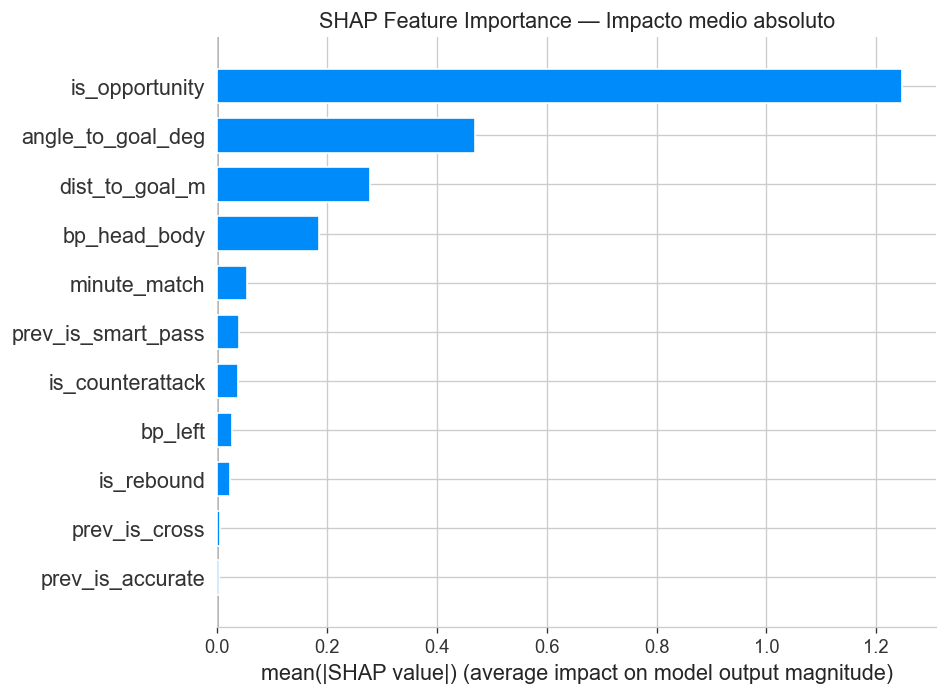

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Impacto medio absoluto')
savefig("shap_importance_bar")
plt.tight_layout()
plt.show()

### 10.3 Dirección y distribución del efecto (beeswarm)

El beeswarm plot superpone tres dimensiones para cada feature: la posición horizontal indica la contribución SHAP de cada tiro individual, el color refleja el valor de la feature (rojo = alto, azul = bajo), y la distribución vertical muestra la densidad de observaciones. Esto permite identificar simultáneamente la importancia, la dirección del efecto y la presencia de interacciones o heterogeneidad en el impacto.

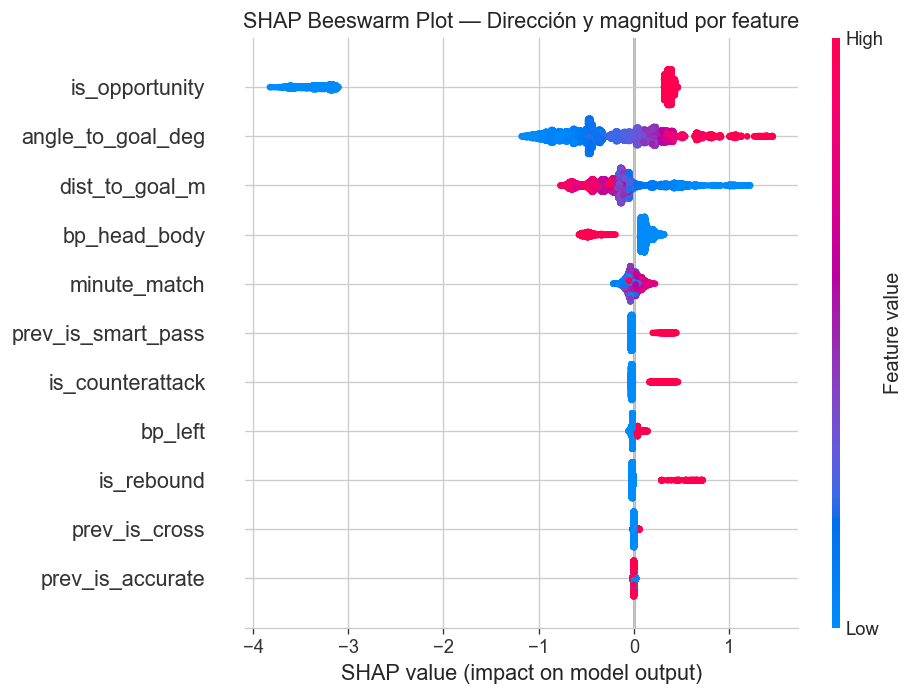

In [69]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm Plot — Dirección y magnitud por feature')
savefig("shap_beeswarm")
plt.tight_layout()
plt.show()

### 10.4 Dependence plots — features principales

Los dependence plots muestran la forma funcional exacta de la relación entre cada feature y su contribución SHAP. El eje horizontal representa el valor de la feature, el eje vertical su contribución al output del modelo, y el color indica automáticamente la variable con mayor interacción detectada por SHAP. Estos gráficos revelan no-linealidades que el beeswarm no puede capturar y permiten verificar si el modelo reproduce relaciones físicamente plausibles.

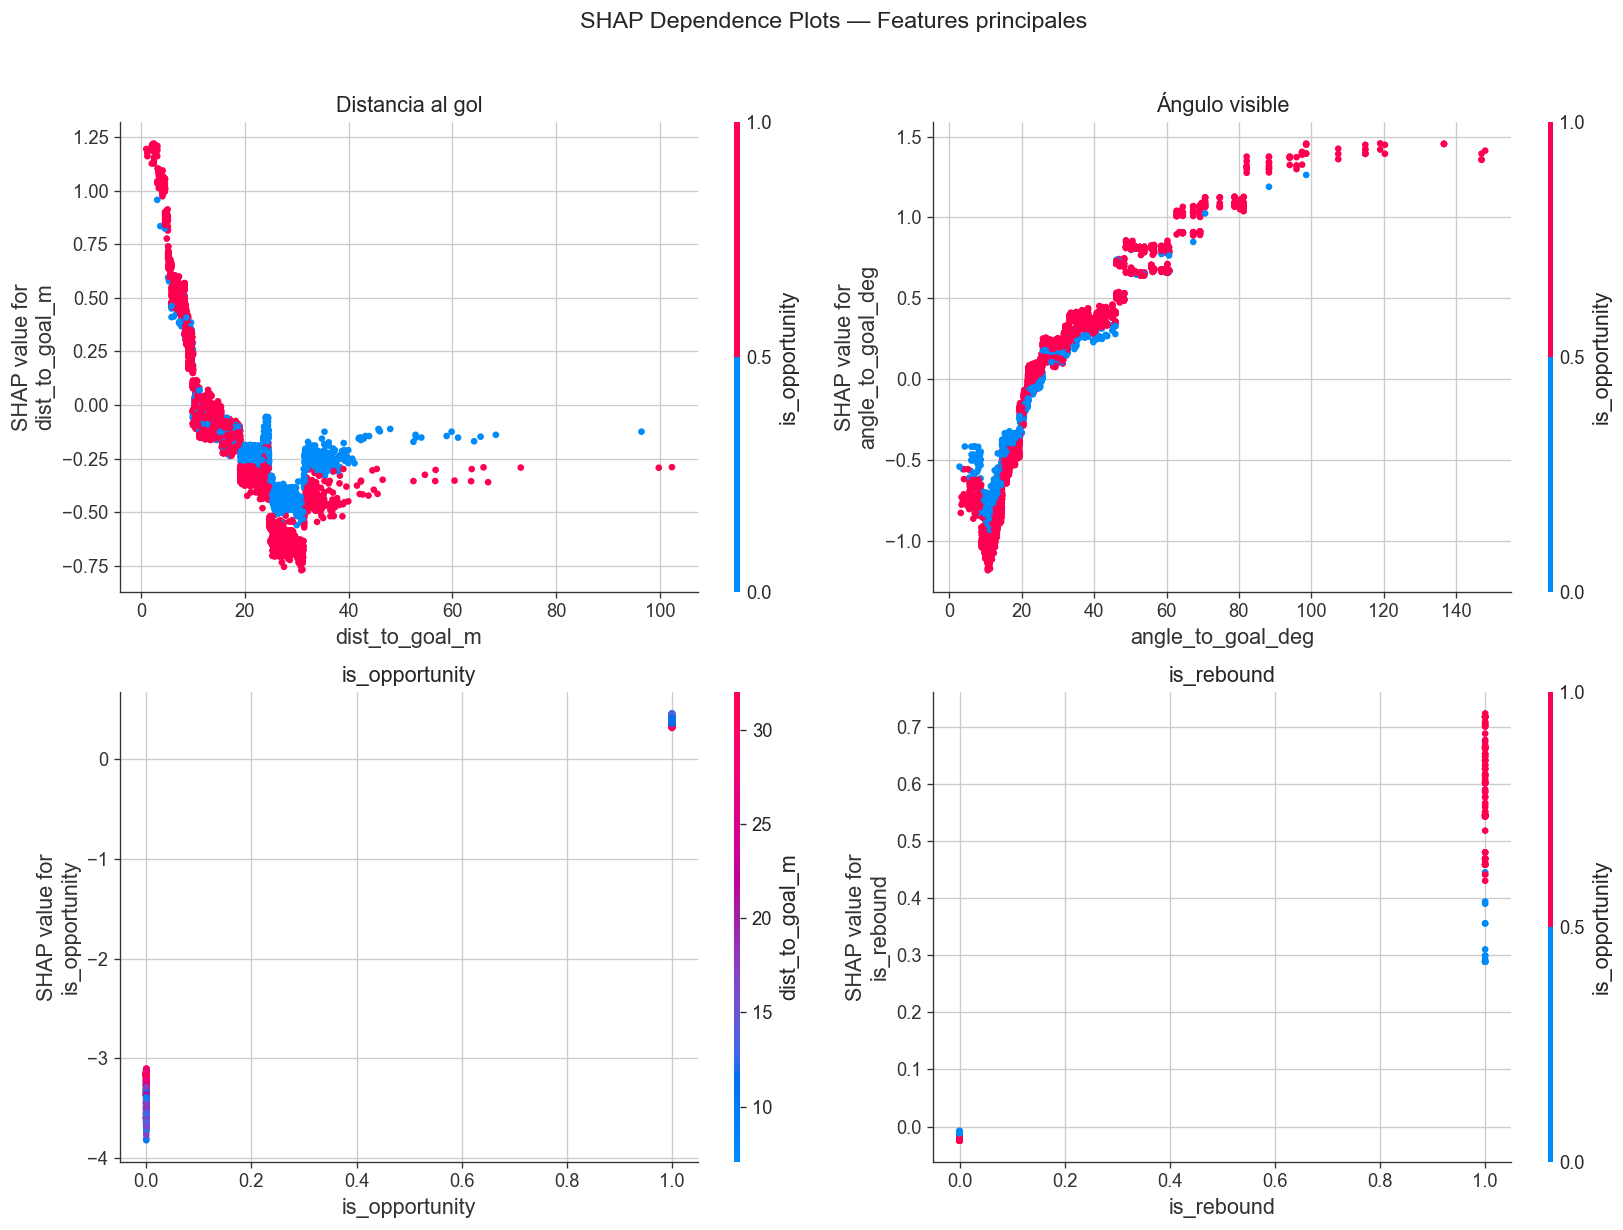

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distancia al gol
shap.dependence_plot('dist_to_goal_m', shap_values, X_test, 
                      ax=axes[0, 0], show=False)
axes[0, 0].set_title('Distancia al gol')

# Ángulo visible
shap.dependence_plot('angle_to_goal_deg', shap_values, X_test,
                      ax=axes[0, 1], show=False)
axes[0, 1].set_title('Ángulo visible')

# is_opportunity
shap.dependence_plot('is_opportunity', shap_values, X_test,
                      ax=axes[1, 0], show=False)
axes[1, 0].set_title('is_opportunity')

# is_rebound
shap.dependence_plot('is_rebound', shap_values, X_test,
                      ax=axes[1, 1], show=False)
axes[1, 1].set_title('is_rebound')

plt.suptitle('SHAP Dependence Plots — Features principales', fontsize=14, y=1.02)
plt.tight_layout()
savefig("shap_dependence_main")
plt.show()

### 10.5 Dependence plots: features contextuales y body_part

El mismo análisis se aplica a las features binarias de contexto y ejecución. Al ser variables 0/1, los dependence plots muestran dos columnas de puntos cuya separación vertical indica la magnitud del efecto y cuya dispersión interna revela la influencia del contexto (interacción con la variable coloreada).

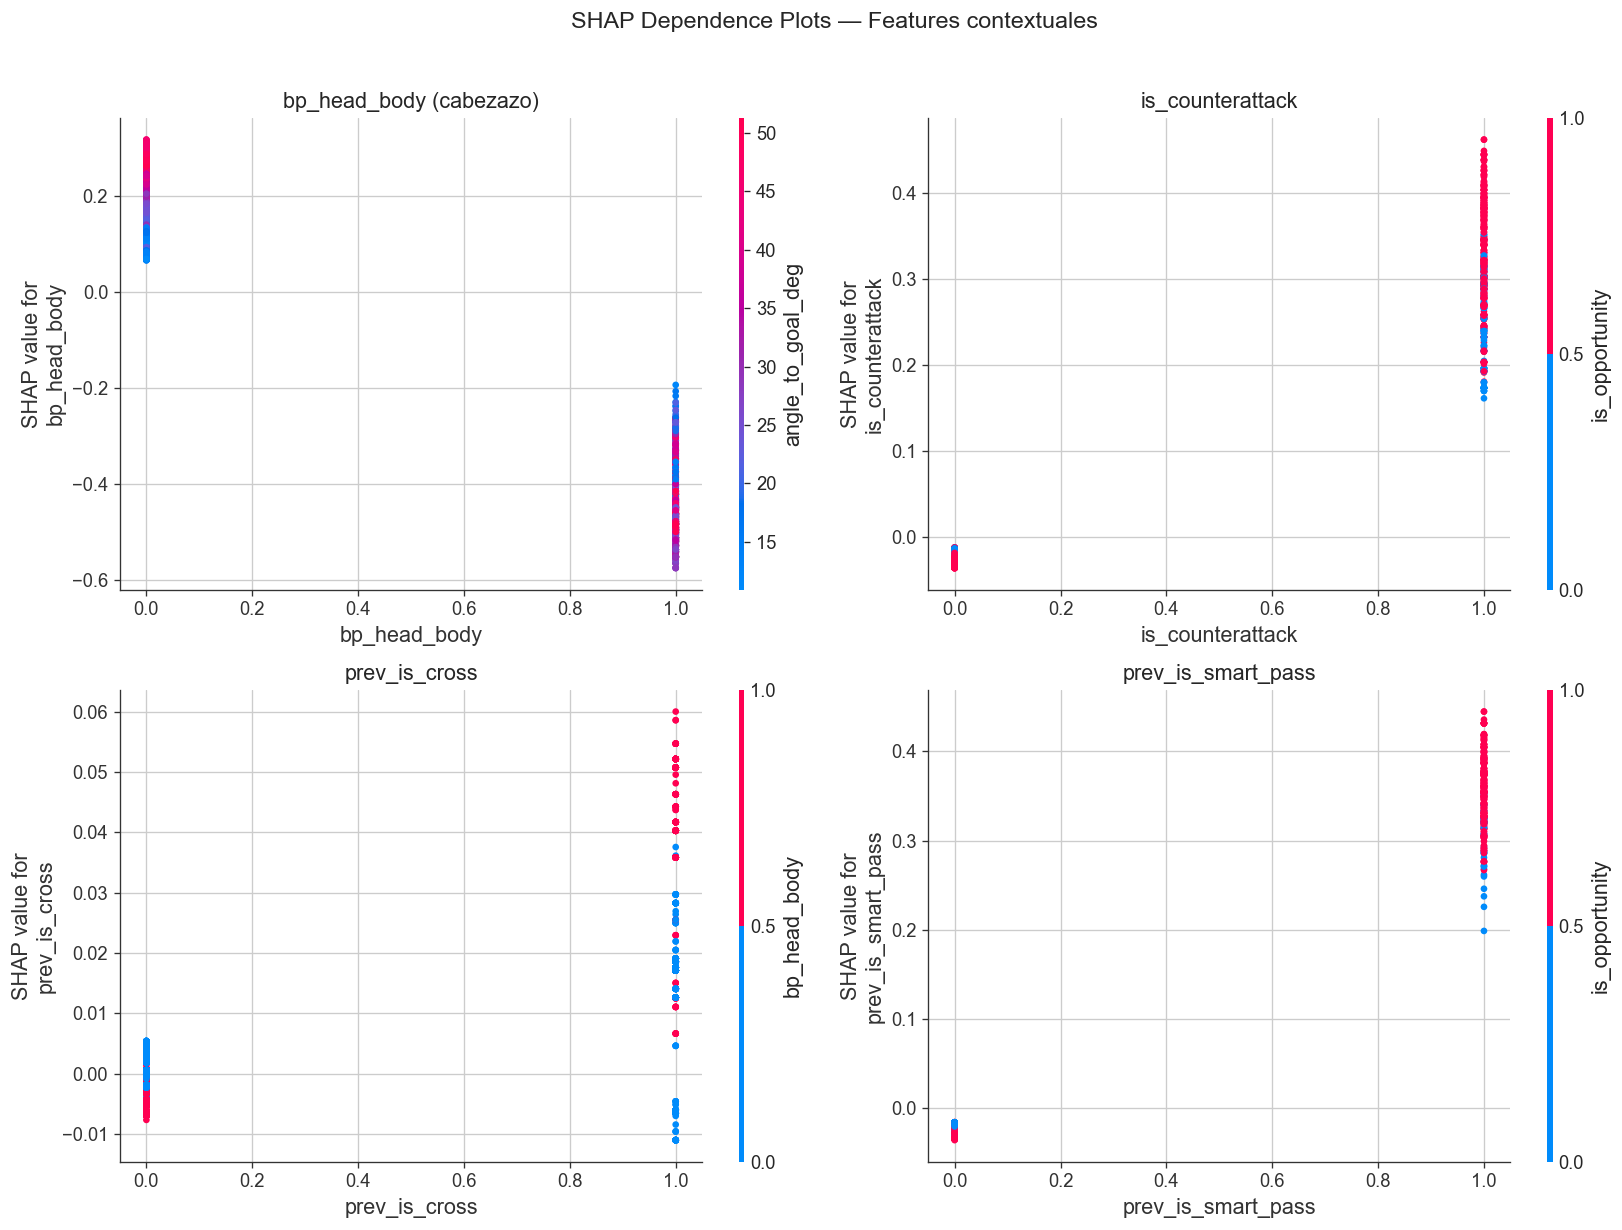

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# bp_head_body (el caso paradójico)
shap.dependence_plot('bp_head_body', shap_values, X_test,
                      ax=axes[0, 0], show=False)
axes[0, 0].set_title('bp_head_body (cabezazo)')

# is_counterattack
shap.dependence_plot('is_counterattack', shap_values, X_test,
                      ax=axes[0, 1], show=False)
axes[0, 1].set_title('is_counterattack')

# prev_is_cross
shap.dependence_plot('prev_is_cross', shap_values, X_test,
                      ax=axes[1, 0], show=False)
axes[1, 0].set_title('prev_is_cross')

# prev_is_smart_pass
shap.dependence_plot('prev_is_smart_pass', shap_values, X_test,
                      ax=axes[1, 1], show=False)
axes[1, 1].set_title('prev_is_smart_pass')

plt.suptitle('SHAP Dependence Plots — Features contextuales', fontsize=14, y=1.02)
plt.tight_layout()
savefig("shap_dependence_context")
plt.show()

### 10.6 Predicciones individuales explicadas (waterfall)

Los waterfall plots descomponen tres predicciones representativas del test set: un tiro de xG bajo, uno medio y uno máximo, mostrando cómo el modelo construye cada predicción desde el valor base (tasa media de gol) sumando las contribuciones individuales de cada feature. Son la herramienta más efectiva para comunicar el modelo a una audiencia no técnica: un scout o director deportivo puede ver exactamente por qué un tiro concreto recibe un xG de 0.03 vs 0.81.


xG bajo: P(gol) = 0.030
  dist=25.4m, angle=13.1°, opp=1, rebound=0, head=0


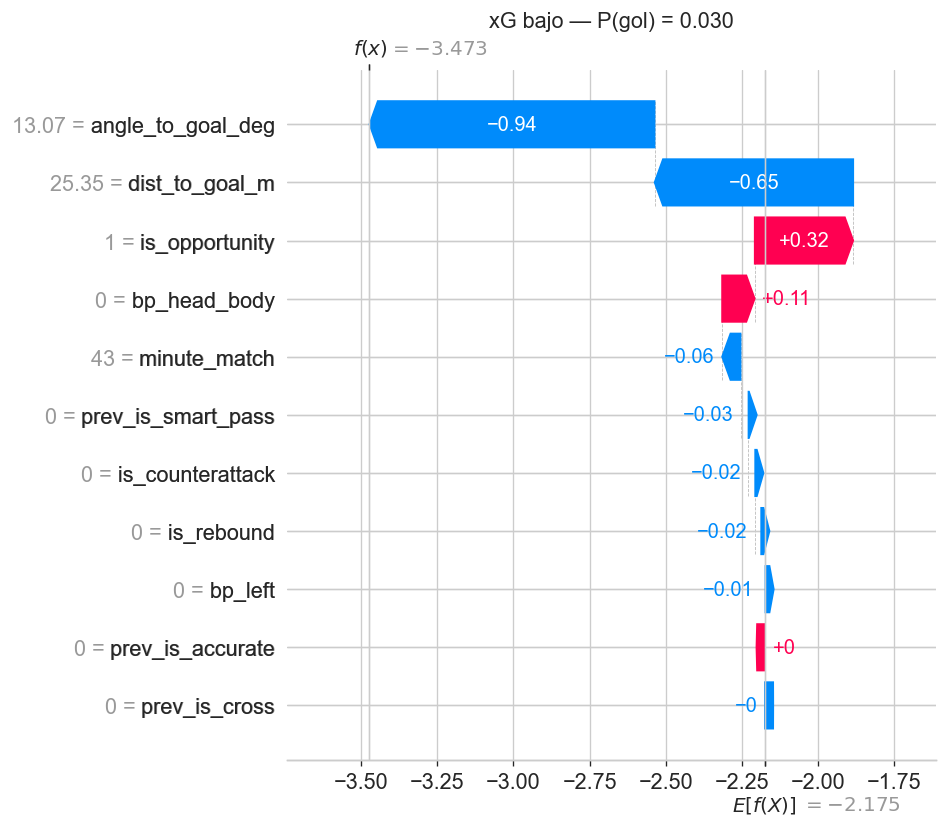


xG medio: P(gol) = 0.150
  dist=16.6m, angle=19.3°, opp=1, rebound=1, head=0


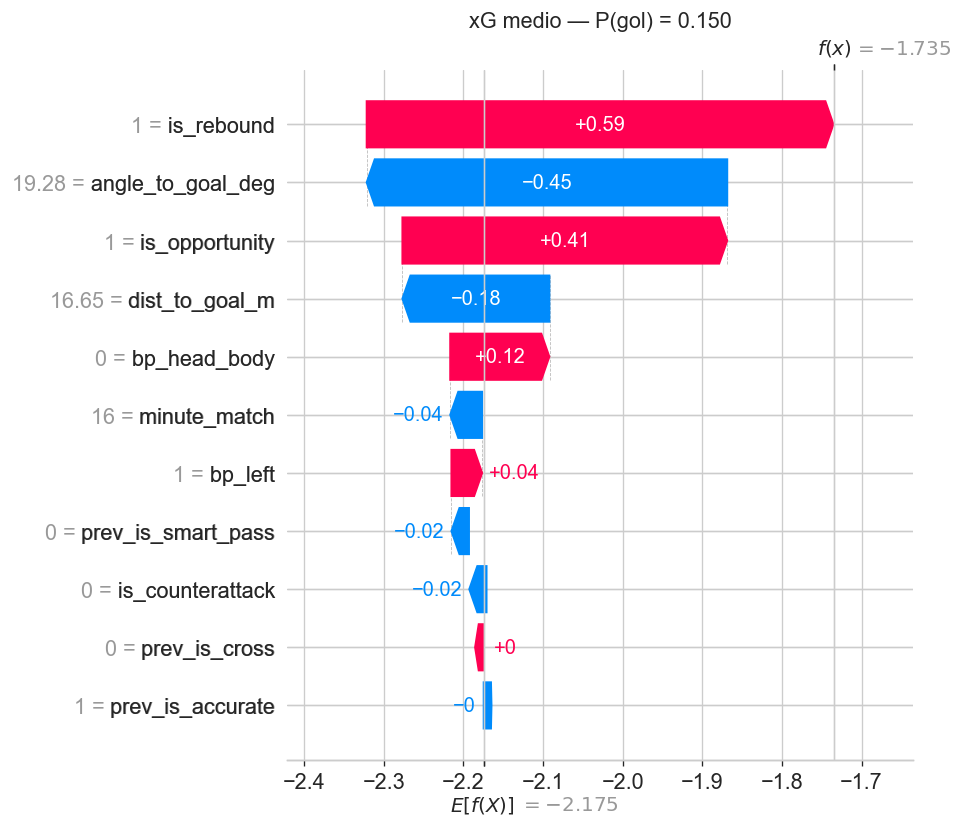


xG máximo: P(gol) = 0.837
  dist=2.9m, angle=107.4°, opp=1, rebound=1, head=0


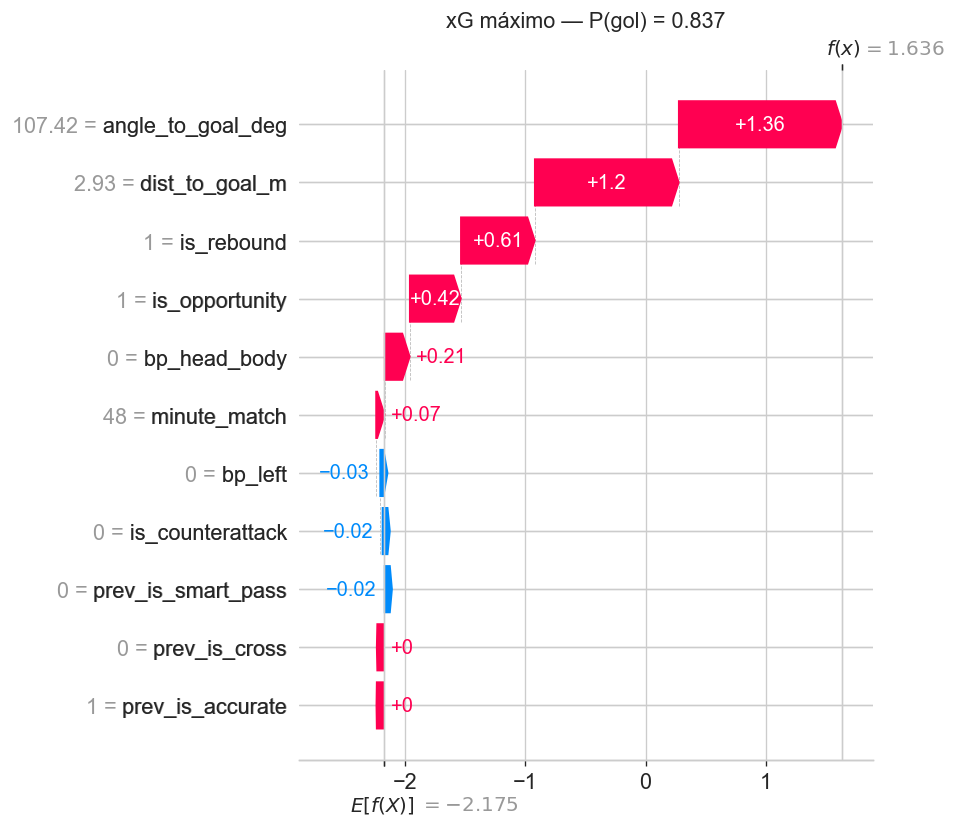

In [72]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test.values,
    feature_names=list(X_test.columns)
)

xg_pred = xgb_optimized.predict_proba(X_test)[:, 1]

idx_low = np.argmin(np.abs(xg_pred - 0.03))
idx_mid = np.argmin(np.abs(xg_pred - 0.15))
idx_high = np.argmax(xg_pred)

for idx, label in [(idx_low, 'xG bajo'), (idx_mid, 'xG medio'), (idx_high, 'xG máximo')]:
    print(f"\n{label}: P(gol) = {xg_pred[idx]:.3f}")
    row = X_test.iloc[idx]
    print(f"  dist={row['dist_to_goal_m']:.1f}m, angle={row['angle_to_goal_deg']:.1f}°, "
          f"opp={int(row['is_opportunity'])}, rebound={int(row['is_rebound'])}, "
          f"head={int(row['bp_head_body'])}")
    
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.waterfall_plot(shap_explanation[idx], show=False, max_display=11)
    plt.title(f'{label} — P(gol) = {xg_pred[idx]:.3f}', fontsize=13)
    plt.tight_layout()
    plt.show()

### 10.7 Comparación de rankings: Bivariado vs Gain vs SHAP

Las tres métricas de importancia utilizadas a lo largo del notebook ofrecen perspectivas complementarias sobre el mismo conjunto de features. El análisis bivariado (secciones 3-4) mide la asociación marginal con el target sin controlar por confusores. El gain de XGBoost (sección 8) mide la utilidad de cada variable dentro de los splits del modelo. SHAP mide el impacto real de cada feature sobre las predicciones individuales, controlando por todas las demás variables. Los cambios de ranking entre las tres métricas revelan qué features aportan más (o menos) de lo que su asociación marginal sugiere.

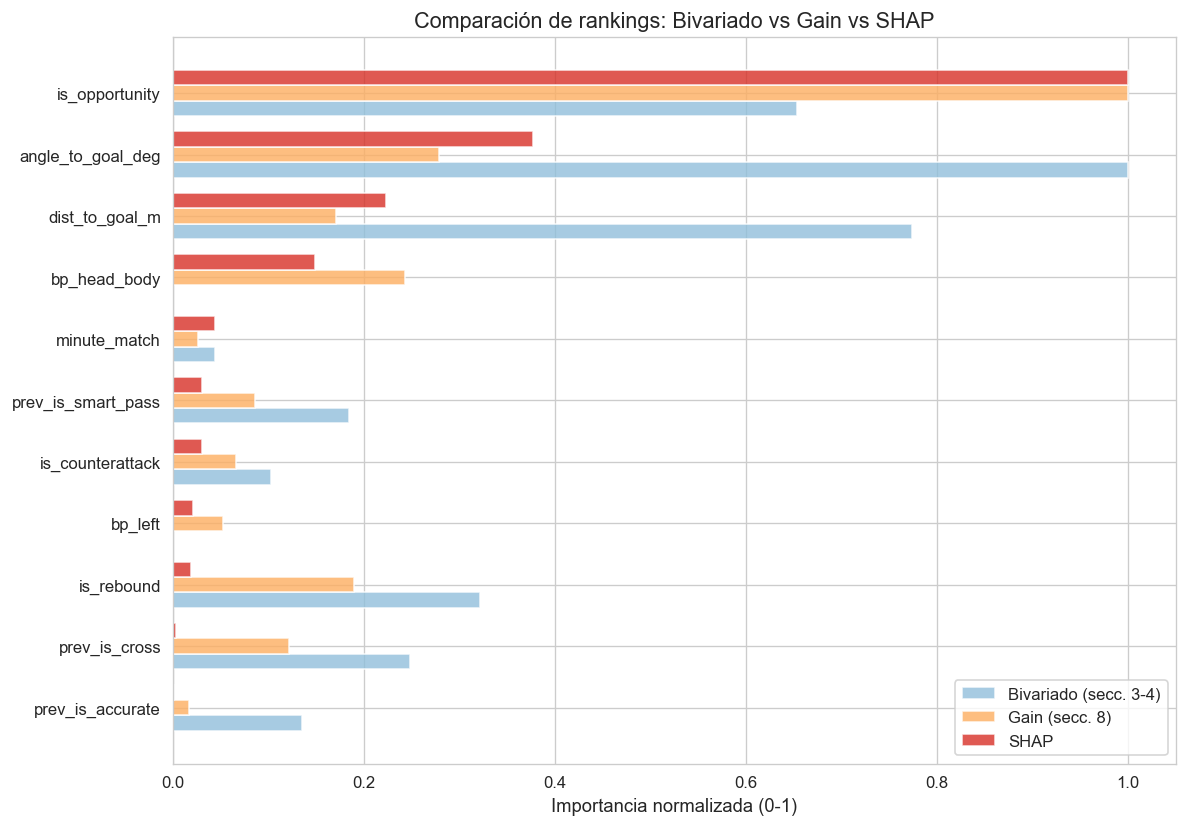

In [73]:
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_mean_abs': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_mean_abs', ascending=False)

# Gain
gain_dict = xgb_optimized.get_booster().get_score(importance_type='gain')

# Bivariado (de la sección 3-4)
bivariado_dict = dict(zip(df_summary_full['Feature'], df_summary_full['|Efecto|']))

comparison_df = shap_importance.copy()
comparison_df['Gain'] = comparison_df['Feature'].map(gain_dict).fillna(0)
comparison_df['Bivariado'] = comparison_df['Feature'].map(bivariado_dict).fillna(0)

# Normalizar cada columna al rango [0, 1] para comparabilidad
for col in ['SHAP_mean_abs', 'Gain', 'Bivariado']:
    max_val = comparison_df[col].max()
    if max_val > 0:
        comparison_df[f'{col}_norm'] = comparison_df[col] / max_val
    else:
        comparison_df[f'{col}_norm'] = 0

# Visualización
fig, ax = plt.subplots(figsize=(10, 7))

features_ordered = comparison_df.sort_values('SHAP_mean_abs_norm', ascending=True)['Feature']
y_pos = range(len(features_ordered))
height = 0.25

ax.barh([y - height for y in y_pos], 
        comparison_df.set_index('Feature').loc[features_ordered, 'Bivariado_norm'],
        height=height, label='Bivariado (secc. 3-4)', color='#91bfdb', alpha=0.8)
ax.barh(y_pos, 
        comparison_df.set_index('Feature').loc[features_ordered, 'Gain_norm'],
        height=height, label='Gain (secc. 8)', color='#fdae61', alpha=0.8)
ax.barh([y + height for y in y_pos], 
        comparison_df.set_index('Feature').loc[features_ordered, 'SHAP_mean_abs_norm'],
        height=height, label='SHAP', color='#d73027', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(features_ordered)
ax.set_xlabel('Importancia normalizada (0-1)')
ax.set_title('Comparación de rankings: Bivariado vs Gain vs SHAP')
ax.legend(loc='lower right')

plt.tight_layout()
savefig("ranking_comparison")
plt.show()

### Interpretación del análisis SHAP

#### Jerarquía global de features

El bar plot confirma la dominancia de `is_opportunity` con un impacto medio absoluto de 1.25 en log-odds, 2.7 veces superior al de la segunda feature. Las cuatro variables principales concentran la práctica totalidad del impacto predictivo:

| Feature| SHAP | Rol |
|---|---|---|
| `is_opportunity` | 1.247 | Filtro contextual de ocasión real |
| `angle_to_goal_deg` | 0.469 | Posición lateral del tirador |
| `dist_to_goal_m` | 0.279 | Distancia radial al gol |
| `bp_head_body` | 0.185 | Tipo de ejecución del remate |
| `minute_match` | 0.055 | Efecto temporal residual |
| `prev_is_smart_pass` | 0.039 | Contexto previo (pase creativo) |
| `is_counterattack` | 0.039 | Contexto táctico |
| Resto (4 features) | <0.03 cada una | Contribución marginal |

El hallazgo más revelador es el contraste entre las features Tier 2 en SHAP y en el análisis bivariado. `is_rebound` presentaba la asociación bivariada más fuerte del grupo Tier 2 (V = 0.107, +26.7pp), pero su impacto SHAP es de apenas 0.024 — inferior incluso a `bp_left` (0.027). `prev_is_cross` (V = 0.083) se reduce a 0.004 en SHAP. Esto indica que su efecto aparente estaba compartido con las variables posicionales y con `is_opportunity`: los rebotes ocurren cerca de portería, los centros generan tiros con un perfil geométrico específico, y ambas situaciones están asociadas al tag de ocasión. Una vez que el modelo controla por posición y por el tag, la contribución incremental del contexto previo es pequeña — aunque no nula, como muestran los dependence plots.

Esta divergencia entre importancia marginal e importancia condicional es un resultado metodológicamente relevante que justifica haber realizado ambos análisis a lo largo del notebook.

#### Beeswarm — dirección del efecto

El beeswarm revela la dirección del impacto de cada feature:

**`is_opportunity`** muestra una separación bimodal extrema. Cuando el tag es 0 (puntos azules), el SHAP oscila entre −3 y −4 log-odds — el modelo penaliza fuertemente los tiros sin tag de ocasión, reduciéndolos a un xG prácticamente nulo. Cuando el tag es 1, el SHAP es ligeramente positivo (~+0.3), devolviendo la predicción al rango "normal". La asimetría es reveladora: no es que ser oportunidad suba mucho el xG — es que no serlo lo destruye.

**`angle_to_goal_deg`** presenta un gradiente limpio de azul (ángulo cerrado → SHAP negativo, hasta −1.0) a rojo (ángulo amplio → SHAP positivo, hasta +1.4). El rango total de aproximadamente 2.4 log-odds confirma que el ángulo visible de portería es uno de los componentes estructurales más importantes del xG.

**`dist_to_goal_m`** muestra el gradiente inverso: rojo (distancia alta) hacia valores negativos, azul (distancia corta) hacia valores positivos. La relación no es lineal: el impacto cambia de forma mucho más abrupta dentro del área que en tiros lejanos, coherente con el decaimiento exponencial documentado en secciones anteriores.

**`bp_head_body`** presenta puntos rojos (cabezazo = 1) con SHAP consistentemente negativo, en el rango −0.2 a −0.6. Esto confirma definitivamente el hallazgo de la sección 7: controlando por posición, los cabezazos reducen la probabilidad de gol. El efecto aparente positivo del análisis bivariado (12.6% vs 10%) era un confusor de la distancia — los cabezazos se producen cerca de portería, pero la ejecución de cabeza es biomecánicamente inferior a la de pie.

**`is_counterattack`** muestra un efecto positivo cuando vale 1 (SHAP +0.1 a +0.35), coherente con defensas desordenadas, pero con baja prevalencia.

#### Dependence plots — no-linealidades e interacciones

**Distancia al gol:** La curva SHAP muestra un decaimiento no lineal abrupto: SHAP de +1.2 a 2–3 metros, caída pronunciada hasta −0.5 a 20 metros, y aplanamiento más allá de 30 metros. La coloración por `is_opportunity` revela que, a misma distancia, los tiros con tag de ocasión reciben un SHAP ligeramente superior. La no-linealidad es más pronunciada en el rango 0–15 metros, precisamente donde se producen la mayoría de los goles.

**Ángulo visible:** Curva monótonamente creciente con forma sigmoide, desde SHAP −1.0 en ángulos inferiores a 10° hasta SHAP +1.4 en ángulos superiores a 100°. La transición más abrupta se produce entre 15° y 40° — la zona donde la posición lateral del tirador pasa de "sin opciones" a "posición razonable".

**`is_opportunity`:** Bimodalidad extrema con dos columnas de puntos separadas por aproximadamente 3.5 log-odds. La columna de opp=0 muestra que la coloración por `dist_to_goal_m` modula ligeramente el SHAP — los tiros sin oportunidad desde distancias cortas reciben una penalización algo menor.

**`is_rebound`:** Cuando vale 1, el SHAP es positivo (entre +0.1 y +0.7), modulado por `is_opportunity` — los rebotes con tag de oportunidad reciben más SHAP que los que no lo tienen. Esto confirma la intuición futbolística: un rebote con oportunidad real es más peligroso que un rechace sin opciones claras.

**`bp_head_body`:** Cuando vale 1, el SHAP es negativo en el rango −0.2 a −0.6. La coloración por `angle_to_goal_deg` revela una interacción: los cabezazos con ángulo más alto (colores cálidos) tienen un SHAP menos negativo (~−0.2) que los de ángulo cerrado (~−0.6). El cabezazo reduce el xG en general, pero el efecto se atenúa en situaciones frontales donde el rematador dispone de más portería visible.

**`is_counterattack`:** Cuando vale 1, SHAP entre +0.1 y +0.35, modulado por `is_opportunity`. Los contraataques sin tag de oportunidad reciben penalización (~−0.15), confirmando que el efecto positivo del contraataque se canaliza parcialmente a través del tag.

**`prev_is_cross`:** Cuando cross = 1, el SHAP es ligeramente positivo (rango 0 a +0.06). La coloración por `bp_head_body` muestra que los centros que terminan en cabezazo (colores cálidos) reciben un SHAP algo mayor que los que terminan en disparo con pie. El efecto es pequeño en magnitud pero consistentemente positivo — a diferencia de lo observado en la regresión logística (OR = 1.04, prácticamente neutro), SHAP muestra que los centros aportan una señal contextual positiva, aunque mínima, una vez controlado el resto de variables.

**`prev_is_smart_pass`:** Efecto positivo más claro que `prev_is_cross` (SHAP entre +0.2 y +0.45 cuando smart_pass = 1). Los smart passes mantienen un efecto neto positivo controlando por posición — generan tiros de mayor calidad independientemente de la ubicación, lo que sugiere que este tipo de pase creativo aporta información no redundante con la geometría del tiro.

#### Waterfall plots — tres tiros explicados

Los tres tiros seleccionados ilustran cómo el modelo construye cada predicción desde el valor base (P ≈ 0.102, probabilidad implícita del expected value):

**xG bajo (0.030):** Tiro desde 25.4m con ángulo de 13.1°, con pie, sin rebote. Pese a tener `is_opportunity = 1` (+0.32), el ángulo cerrado penaliza la predicción en −0.94 log-odds y la distancia en −0.65, arrastrando la probabilidad final muy por debajo de la tasa base. Es un tiro lejano y lateral — exactamente lo que el sentido futbolístico predice como una ocasión de bajísima probabilidad.

**xG medio (0.150):** Tiro desde 16.6m con ángulo de 19.3°, con pie, tras rebote. En este caso `is_rebound` es la feature que más contribuye (+0.59), seguida de `is_opportunity` (+0.41). Sin embargo, el ángulo cerrado (−0.45) y la distancia (−0.18) compensan parcialmente. Es una segunda jugada tras parada del portero, a distancia media — la combinación del rebote con la oportunidad genera un xG moderado pese a la geometría desfavorable.

**xG máximo (0.837):** Tiro desde 2.9m con ángulo de 107.4°, con pie, tras rebote. El ángulo aporta +1.36 log-odds y la distancia +1.20 — juntos elevan la predicción desde 0.102 hasta 0.837. `is_rebound` añade +0.61 e `is_opportunity` +0.42. Un ángulo de 107° indica que el tirador ve prácticamente toda la portería de frente — es un remate a bocajarro desde dentro del área pequeña tras un rechace, la mejor ocasión del dataset.

#### Comparación de rankings: Bivariado vs Gain vs SHAP

La comparación visual de las tres métricas de importancia a lo largo del notebook revela movimientos significativos:

| Feature | Bivariado (rank) | Gain (rank) | SHAP (rank) | Patrón |
|---|---|---|---|---|
| `is_opportunity` | 3º | 1º | 1º | Sube: efecto condicional dominante |
| `angle_to_goal_deg` | 1º | 2º | 2º | Estable en todas las perspectivas |
| `dist_to_goal_m` | 2º | 5º | 3º | Baja en gain, se recupera en SHAP |
| `bp_head_body` | 9º | 3º | 4º | Sube mucho: efecto condicional fuerte pese a baja asociación marginal |
| `is_rebound` | 4º | 4º | 9º | Baja mucho en SHAP: efecto confundido por posición |
| `prev_is_cross` | 5º | 6º | 10º | Baja mucho: efecto absorbido por geometría y body_part |

Los dos movimientos más informativos son la subida de `bp_head_body` (del 9º en bivariado al 4º en SHAP) y la caída de `is_rebound` (del 4º en bivariado al 9º en SHAP). El primero demuestra que una feature con baja asociación marginal puede ser altamente informativa en el modelo multivariante a través de interacciones — el tipo de remate modifica el xG de forma distinta según la distancia y el ángulo. El segundo demuestra que una asociación marginal fuerte (+26.7pp en conversión) puede estar casi completamente confundida por variables posicionales — los rebotes ocurren a distancias cortas, y una vez que el modelo conoce la distancia y el ángulo, saber que es rebote añade poco.

Esta divergencia entre importancia marginal y condicional es precisamente la razón por la que el análisis de features se realizó en dos fases separadas en este notebook: la primera (secciones 3-4) para identificar candidatas con tests bivariados, y la segunda (secciones 8 y 10) para cuantificar su aportación real dentro del modelo. Si solo se hubiera utilizado SHAP, no se habría documentado la existencia de confusión en `is_rebound` ni la inversión de signo de `bp_head_body` — hallazgos que demuestran comprensión del proceso de modelado más allá de la optimización de métricas.

## 11. Aplicación: xG por jugador

### Motivación

Hasta este punto, el proyecto se ha centrado en construir y validar un modelo xG calibrado y robusto a nivel de tiro individual. Sin embargo, el objetivo real del xG no es predecir goles aislados, sino cuantificar el rendimiento ofensivo de jugadores y equipos de forma agregada.

En esta sección, **el modelo seleccionado (`XGB2 + calibración isotónica`)** se aplica sobre todos los tiros del dataset para calcular el xG individual de cada acción y construir métricas agregadas por jugador. Estas métricas transforman eventos aislados en indicadores de rendimiento sostenido y constituyen la base analítica del pipeline de scouting desarrollado en las fases posteriores del proyecto.

El análisis permite separar tres componentes que el número bruto de goles mezcla:
- **Volumen de ocasiones generadas** (cuánto peligro produce un jugador),
- **Calidad media de los tiros** (desde qué posiciones finaliza),
- **Capacidad de finalización** (si convierte por encima o por debajo de lo esperado).

Esta descomposición es precisamente la razón por la que el xG se ha convertido en el estándar moderno de evaluación ofensiva en análisis futbolístico.

### Métricas derivadas

| Métrica | Fórmula | Interpretación |
|---|---|---|
| `xg_total` | Σ xG de todos los tiros | Volumen total de peligro ofensivo generado |
| `goals` | Σ goles reales | Producción goleadora real |
| `goals_minus_xg` | goals − xg_total | Overperformance (>0) o underperformance (<0) |
| `shots` | Nº total de tiros | Frecuencia de tiro |
| `xg_per_shot` | xg_total / shots | Selectividad: ¿tira desde buenas posiciones? |
| `minutes` | Minutos jugados (estimado) | Base para métricas per90 |
| `xg_per90` | xg_total / minutes × 90 | Volumen ofensivo normalizado por tiempo |
| `shots_per90` | shots / minutes × 90 | Frecuencia de tiro normalizada |

La métrica central de esta sección es `goals_minus_xg`. Un jugador con valores positivos convierte más goles de los esperados dada la calidad de sus ocasiones, lo que puede indicar una capacidad de finalización superior a la media. Valores negativos indican infra-conversión: desperdicio de ocasiones, mala suerte o varianza temporal.

Es importante subrayar que `goals_minus_xg` es una métrica extremadamente volátil en muestras pequeñas. Por ello, se complementa con métricas de volumen (`xg_total`, `shots_per90`) y eficiencia (`xg_per_shot`) para obtener perfiles ofensivos más estables y útiles para scouting.

### 11.1 Cálculo de xG por tiro

Se aplica el modelo calibrado (XGB2 + calibración isotónica) a los 40.461 tiros del dataset completo para obtener un valor de xG individual por acción. Esto incluye tanto los tiros del train set como los del test set — para la agregación por jugador se necesita cobertura completa.

La primera validación de este paso es el ratio entre la suma total de xG predicho y el número real de goles. Un ratio cercano a 1.0 confirma que la calibración del modelo se mantiene al aplicarlo sobre todo el dataset.

In [74]:
X_all = pd.concat([
    df_shots[FEATURES_FINAL['continuous']],
    df_shots[FEATURES_FINAL['binary']].astype(int),
    pd.get_dummies(df_shots['body_part'], prefix='bp', drop_first=False)
       .drop(columns=['bp_right'], errors='ignore').astype(int)
], axis=1)

# Asegurar mismo orden de columnas
X_all = X_all[list(X.columns)]

df_shots['xg'] = xgb_calibrated.predict_proba(X_all)[:, 1]

print(f"xG calculado para {len(df_shots):,} tiros")
print(f"\nDistribución del xG predicho:")
print(df_shots['xg'].describe().round(4).to_string())
print(f"\n  Suma total de xG:    {df_shots['xg'].sum():.1f}")
print(f"  Goles reales totales: {df_shots['target'].sum():,}")
print(f"  Ratio goles/xG:      {df_shots['target'].sum() / df_shots['xg'].sum():.3f}")

xG calculado para 40,461 tiros

Distribución del xG predicho:
count    40461.0000
mean         0.1055
std          0.1270
min          0.0000
25%          0.0021
50%          0.0711
75%          0.1614
max          0.9778

  Suma total de xG:    4266.8
  Goles reales totales: 4,271
  Ratio goles/xG:      1.001


### 11.2 Estimación de minutos jugados

El dataset público de Wyscout no incluye minutos jugados de forma explícita. Se estima como el rango temporal de actividad de cada jugador en cada partido: la diferencia entre el último y el primer minuto en que aparece como ejecutor de un evento.

Se aplican dos umbrales de filtrado para evitar ratios inestables en las métricas per90: un mínimo de 450 minutos jugados (~5 partidos completos) y un mínimo de 10 tiros. Los jugadores que no alcanzan estos umbrales se excluyen del análisis agregado pero permanecen en el dataset para la Golden Layer.

In [75]:
minutes_by_player = (
    df_all
    .groupby(['player_id', 'match_id'])
    .agg(
        first_min=('minute_match', 'min'),
        last_min=('minute_match', 'max')
    )
    .assign(est_minutes=lambda x: x['last_min'] - x['first_min'])
    .groupby('player_id')['est_minutes']
    .sum()
    .reset_index()
    .rename(columns={'est_minutes': 'total_minutes'})
)

# Filtrar jugadores con mínimo de minutos (evitar ratios inestables)
MIN_MINUTES = 450  # ~5 partidos completos
MIN_SHOTS = 10     # mínimo de tiros para estadísticas fiables

print(f"Jugadores con eventos: {len(minutes_by_player):,}")
print(f"Jugadores con ≥ {MIN_MINUTES} min: {(minutes_by_player['total_minutes'] >= MIN_MINUTES).sum():,}")

Jugadores con eventos: 2,569
Jugadores con ≥ 450 min: 1,939


### 11.3 Agregación por jugador

Para cada jugador se calcula el total de tiros, goles, xG acumulado y sus métricas derivadas: `xg_per_shot` (selectividad posicional), `xg_per90` (volumen ofensivo normalizado), `shots_per90` (frecuencia de tiro) y `goals_minus_xg` (overperformance). Se unen los nombres de jugador desde la tabla de Bronze para facilitar la interpretación de los rankings.

In [76]:
player_xg = (
    df_shots
    .groupby('player_id')
    .agg(
        shots=('target', 'count'),
        goals=('target', 'sum'),
        xg_total=('xg', 'sum'),
        xg_mean=('xg', 'mean'),
    )
    .reset_index()
)

# Unir con minutos estimados
player_xg = player_xg.merge(minutes_by_player, on='player_id', how='left')

# Métricas derivadas
player_xg['goals_minus_xg'] = player_xg['goals'] - player_xg['xg_total']
player_xg['xg_per_shot'] = player_xg['xg_total'] / player_xg['shots']
player_xg['xg_per90'] = player_xg['xg_total'] / player_xg['total_minutes'] * 90
player_xg['shots_per90'] = player_xg['shots'] / player_xg['total_minutes'] * 90
player_xg['goals_per90'] = player_xg['goals'] / player_xg['total_minutes'] * 90

# Obtener nombres de jugadores desde la base de datos
query_players = "SELECT wy_player_id AS player_id, short_name FROM bronze.wyscout_players"
df_players = pd.read_sql(query_players, engine)

player_xg = player_xg.merge(df_players, on='player_id', how='left')

# Filtrar por minutos y tiros mínimos
player_xg_filtered = player_xg[
    (player_xg['total_minutes'] >= MIN_MINUTES) &
    (player_xg['shots'] >= MIN_SHOTS)
].copy()

print(f"Jugadores totales con tiros: {len(player_xg):,}")
print(f"Jugadores filtrados (≥{MIN_MINUTES} min, ≥{MIN_SHOTS} tiros): {len(player_xg_filtered):,}")
print(f"\nDistribución de métricas (jugadores filtrados):")
print(player_xg_filtered[['shots', 'goals', 'xg_total', 'goals_minus_xg', 
                           'xg_per90', 'shots_per90']].describe().round(2).to_string())

Jugadores totales con tiros: 2,114
Jugadores filtrados (≥450 min, ≥10 tiros): 1,215

Distribución de métricas (jugadores filtrados):
         shots    goals  xg_total  goals_minus_xg  xg_per90  shots_per90
count  1215.00  1215.00   1215.00         1215.00   1215.00      1215.00
mean     29.90     3.27      3.19            0.08      0.16         1.49
std      21.15     3.92      3.05            1.77      0.14         0.86
min      10.00     0.00      0.00           -7.30      0.00         0.26
25%      15.00     1.00      1.20           -0.91      0.06         0.75
50%      23.00     2.00      2.18           -0.13      0.11         1.33
75%      38.00     4.00      4.04            0.79      0.22         2.08
max     167.00    31.00     24.40           13.38      0.97         6.01


### 11.4 Top overperformers y underperformers

Se identifican los 15 jugadores con mayor y menor `goals_minus_xg`. Los overperformers convierten más goles de los que la calidad de sus ocasiones predice — posible indicador de habilidad de finalización superior. Los underperformers generan ocasiones pero no las aprovechan — puede indicar mala finalización, mala suerte, o una fase de bajo rendimiento.

En ambos casos, `xg_per_shot` complementa la lectura: distingue al jugador que overperforma desde posiciones difíciles (xG/tiro bajo) del que overperforma desde posiciones claras (xG/tiro alto).

In [77]:
top_n = 15

# Overperformers: más goles que xG esperado
overperformers = player_xg_filtered.nlargest(top_n, 'goals_minus_xg')

# Underperformers: menos goles que xG esperado
underperformers = player_xg_filtered.nsmallest(top_n, 'goals_minus_xg')

print("TOP 15 OVERPERFORMERS (goals − xG)")
print("="*75)
print(overperformers[['short_name', 'goals', 'xg_total', 'goals_minus_xg', 
                       'shots', 'xg_per_shot']].to_string(index=False, float_format='%.2f'))

print(f"\n\nTOP 15 UNDERPERFORMERS (goals − xG)")
print("="*75)
print(underperformers[['short_name', 'goals', 'xg_total', 'goals_minus_xg', 
                        'shots', 'xg_per_shot']].to_string(index=False, float_format='%.2f'))

TOP 15 OVERPERFORMERS (goals − xG)
       short_name  goals  xg_total  goals_minus_xg  shots  xg_per_shot
    Mohamed Salah     31     17.62           13.38    136         0.13
        P. Dybala     16      7.28            8.72     87         0.08
      C. Immobile     22     13.58            8.42    102         0.13
        M. Icardi     23     14.63            8.37     87         0.17
     A. Griezmann     16      8.42            7.58     58         0.15
Philippe Coutinho     13      5.94            7.06     79         0.08
       Rony Lopes     15      8.56            6.44     64         0.13
        R. Falcao     15      8.72            6.28     57         0.15
         L. Messi     26     20.09            5.91    142         0.14
          L. Sané     10      4.20            5.80     48         0.09
  Roberto Firmino     14      8.24            5.76     79         0.10
        E. Cavani     24     18.32            5.68     93         0.20
       K. Volland     14      8.38        

### 11.5 Visualización: goles reales vs xG

El scatter plot enfrenta goles reales contra xG acumulado por jugador. Los puntos por encima de la diagonal son overperformers y los que quedan por debajo son underperformers. La distribución de `goals_minus_xg` muestra cómo se reparte la sobreperformancia en el conjunto de jugadores filtrados.

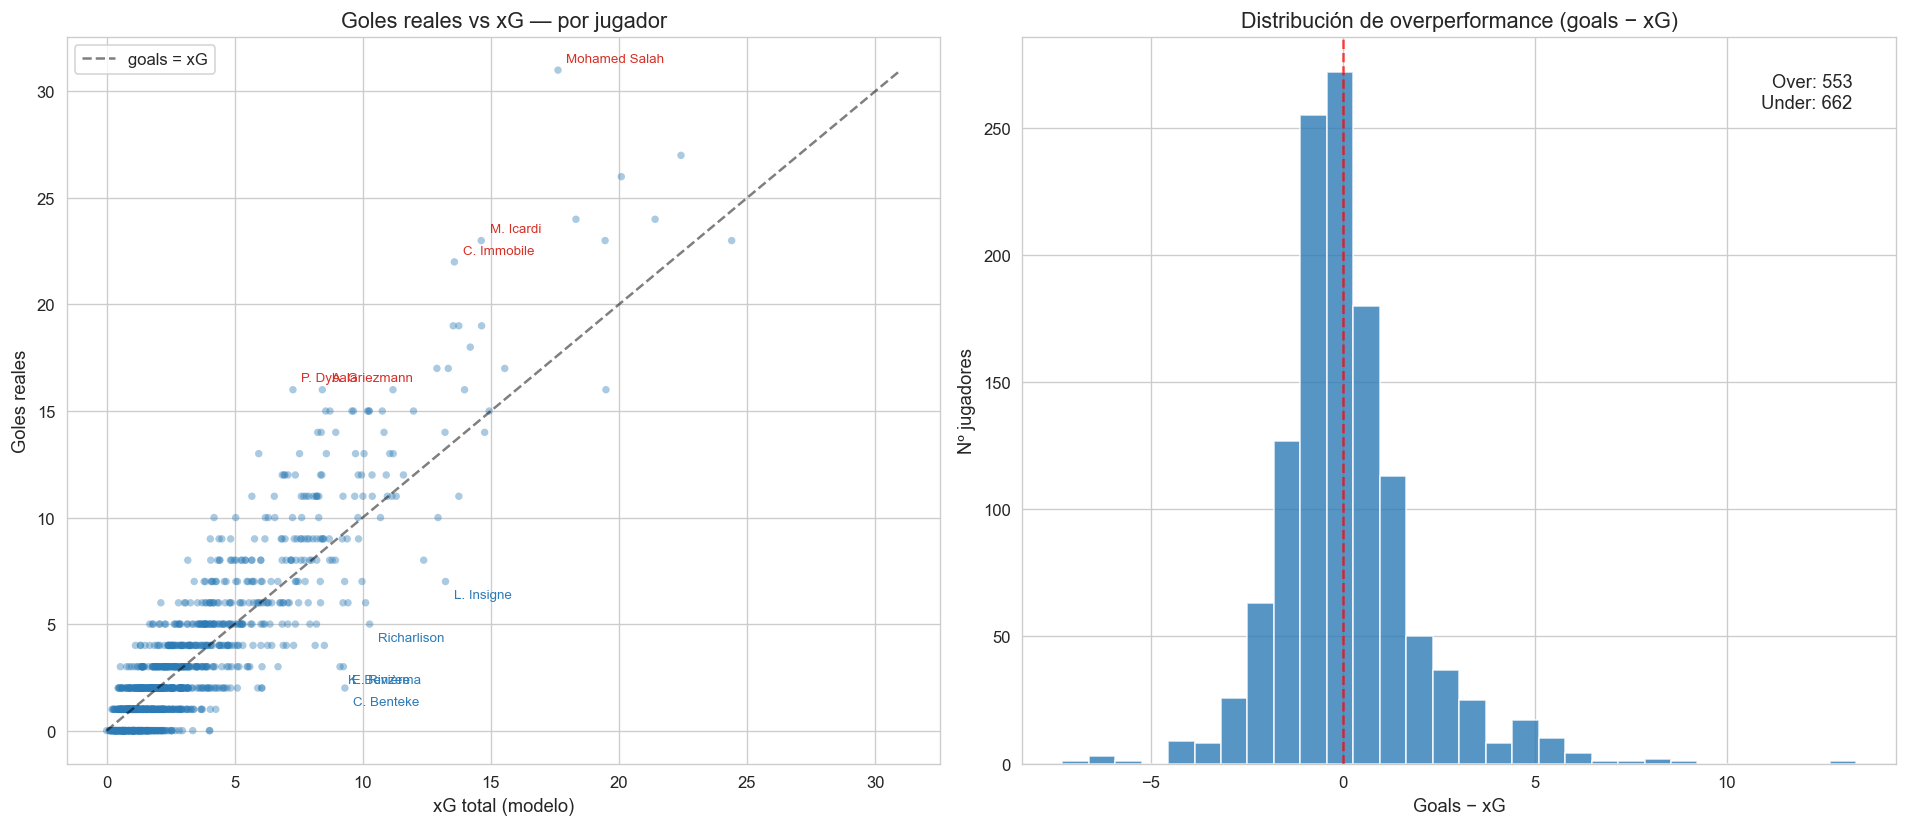

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: scatter goals vs xG
ax = axes[0]
ax.scatter(player_xg_filtered['xg_total'], player_xg_filtered['goals'],
           alpha=0.4, s=20, color='#2c7bb6', edgecolors='none')

# Línea de igualdad
max_val = max(player_xg_filtered['xg_total'].max(), player_xg_filtered['goals'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='goals = xG')

# Anotar top overperformers
for _, row in overperformers.head(5).iterrows():
    ax.annotate(row['short_name'], 
                xy=(row['xg_total'], row['goals']),
                xytext=(5, 5), textcoords='offset points', fontsize=8,
                color='#d73027')

# Anotar top underperformers
for _, row in underperformers.head(5).iterrows():
    ax.annotate(row['short_name'], 
                xy=(row['xg_total'], row['goals']),
                xytext=(5, -10), textcoords='offset points', fontsize=8,
                color='#2c7bb6')

ax.set_xlabel('xG total (modelo)')
ax.set_ylabel('Goles reales')
ax.set_title('Goles reales vs xG — por jugador')
ax.legend()

# Panel derecho: distribución de goals - xG
ax2 = axes[1]
ax2.hist(player_xg_filtered['goals_minus_xg'], bins=30, color='#2c7bb6',
         edgecolor='white', alpha=0.8)
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Goals − xG')
ax2.set_ylabel('Nº jugadores')
ax2.set_title('Distribución de overperformance (goals − xG)')

# Anotación
n_over = (player_xg_filtered['goals_minus_xg'] > 0).sum()
n_under = (player_xg_filtered['goals_minus_xg'] < 0).sum()
ax2.text(0.95, 0.95, f'Over: {n_over}\nUnder: {n_under}',
         transform=ax2.transAxes, ha='right', va='top', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
savefig("goals_vs_xg_players")
plt.show()

### 11.6 Ranking de xG per90

El xG per90 normaliza el volumen ofensivo por tiempo jugado, lo que permite comparar jugadores con minutajes distintos. Este ranking funciona como validación de sentido del modelo: si los nombres que lideran son los delanteros de referencia de la temporada 2017/18, las probabilidades asignadas tiro a tiro producen agregaciones coherentes con el conocimiento futbolístico.

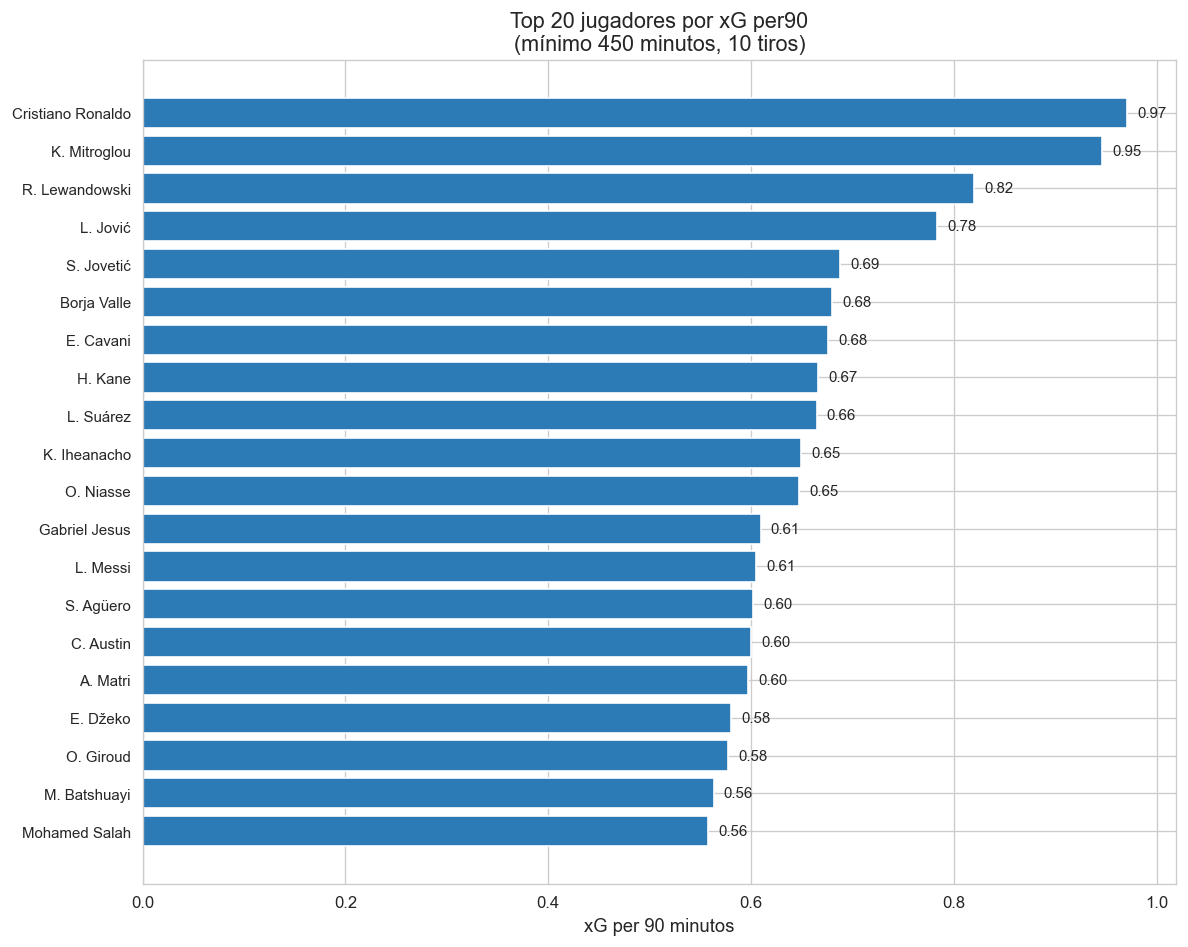

In [79]:
top_xg_per90 = player_xg_filtered.nlargest(20, 'xg_per90')

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(range(len(top_xg_per90)), top_xg_per90['xg_per90'],
               color='#2c7bb6', edgecolor='white')

ax.set_yticks(range(len(top_xg_per90)))
ax.set_yticklabels(top_xg_per90['short_name'], fontsize=9)
ax.set_xlabel('xG per 90 minutos')
ax.set_title('Top 20 jugadores por xG per90\n'
             f'(mínimo {MIN_MINUTES} minutos, {MIN_SHOTS} tiros)')
ax.invert_yaxis()

for bar, val in zip(bars, top_xg_per90['xg_per90']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
savefig("top_xg_per90")
plt.show()

### 11.7 Verificación de calibración agregada

La suma de xG sobre el subconjunto de jugadores filtrados debe aproximarse al número de goles reales. Una desviación superior al 5% indicaría un sesgo sistemático del modelo a nivel agregado. La correlación entre goles y xG por jugador mide cuánta de la varianza en producción goleadora se explica por la calidad de las ocasiones generadas — el complemento es la habilidad individual y la varianza aleatoria.

In [80]:
total_goals = player_xg_filtered['goals'].sum()
total_xg = player_xg_filtered['xg_total'].sum()

print("VERIFICACIÓN DE CALIBRACIÓN AGREGADA")
print("="*55)
print(f"  Goles reales (jugadores filtrados): {total_goals:,}")
print(f"  Suma de xG:                         {total_xg:.1f}")
print(f"  Ratio goles/xG:                     {total_goals/total_xg:.3f}")
print(f"  Diferencia:                          {total_goals - total_xg:+.1f} goles")

# Correlación goals vs xG a nivel de jugador
r_player, p_player = pearsonr(player_xg_filtered['goals'], player_xg_filtered['xg_total'])
print(f"\n  Correlación goals vs xG (jugador): r = {r_player:.4f} (p = {p_player:.2e})")
print(f"  → Los jugadores que generan más xG marcan más goles (validación básica)")

VERIFICACIÓN DE CALIBRACIÓN AGREGADA
  Goles reales (jugadores filtrados): 3,969
  Suma de xG:                         3870.0
  Ratio goles/xG:                     1.026
  Diferencia:                          +99.0 goles

  Correlación goals vs xG (jugador): r = 0.8998 (p = 0.00e+00)
  → Los jugadores que generan más xG marcan más goles (validación básica)


### Interpretación

#### Calibración agregada

El modelo mantiene una calibración excelente al aplicarse sobre el dataset completo:

| Nivel | Goles reales | Suma xG | Ratio |
|---|---|---|---|
| Todos los tiros (40.461) | 4.271 | 4.267 | **1.001** |
| Jugadores filtrados (1.215) | 3.969 | 3.870 | 1.026 |

El ratio de 1.001 sobre el total de tiros es una validación directa de la calibración isotónica: la suma de probabilidades predichas reproduce casi exactamente el número de goles observados. La ligera sobreestimación a nivel de jugadores filtrados (ratio 1.026) se explica porque el filtro de minutos y tiros mínimos excluye preferentemente a jugadores con pocos tiros y cero goles, que contribuyen más a la suma de xG que al conteo de goles.

La correlación entre goles y xG a nivel de jugador es r = 0.900. Esto significa que el 81% de la varianza en goles entre jugadores se explica por la calidad de las ocasiones que generan. El 19% restante corresponde a la habilidad individual de finalización — la capacidad de colocar el balón fuera del alcance del portero, de rematar con potencia bajo presión, o simplemente de tener la suerte de que el balón entre — y a la varianza aleatoria inherente a un evento tan infrecuente como el gol.

#### Overperformers: finalizadores por encima de la expectativa

Los cinco mayores overperformers ilustran perfiles ofensivos muy distintos:

**Mohamed Salah** (+13.38, 31 goles, 17.62 xG) protagonizó una temporada histórica en la Premier League 2017/18. Su xG/tiro de 0.13 indica que no se limita a rematar desde posiciones cómodas — convierte tiros desde ángulos y distancias que el modelo evalúa como difíciles. La magnitud de su overperformance (+13.38 goles sobre lo esperado) es excepcional y difícilmente sostenible a largo plazo, lo que sugiere una combinación de habilidad élite y racha favorable.

**Paulo Dybala** (+8.72, 16 goles, 7.28 xG) presenta el xG/tiro más bajo del top 5 (0.08), lo que indica que tira predominantemente desde fuera del área o desde ángulos cerrados. Su overperformance refleja una capacidad técnica para golpeos colocados y disparos lejanos que el modelo, basado en posición y contexto, no puede anticipar.

**Mauro Icardi** (+8.37, 23 goles, 14.63 xG) ofrece el perfil opuesto: su xG/tiro de 0.17 es el más alto del top 5. Tira casi exclusivamente desde posiciones de alta calidad dentro del área. Es el prototipo de "goleador de área" — genera muchas ocasiones claras y además las convierte por encima de lo esperado.

La diferencia entre Dybala e Icardi es exactamente el tipo de distinción que el sistema de scouting debe capturar: ambos overperforman, pero por motivos completamente distintos. Uno genera sus goles desde la creatividad individual; el otro desde el posicionamiento dentro del área.

#### Underperformers: jugadores por debajo de la expectativa

**Christian Benteke** (−7.30, 2 goles, 9.30 xG) es el caso más extremo. Su xG/tiro de 0.18 indica que genera ocasiones de alta calidad — posiciones cercanas, frontales, con oportunidad. Pero solo convierte 2 de 53 tiros, una tasa del 3.8% frente a un xG medio del 18%. Para un director deportivo, este análisis responde una pregunta concreta: ¿el problema de Benteke es que no genera ocasiones? No — las genera. ¿Es que no las convierte? Sí, drásticamente.

**Karim Benzema** (−6.11, 3 goles, 9.11 xG) atravesaba una temporada baja conocida en el Real Madrid 2017/18. Su xG/tiro de 0.17 confirma que seguía jugando en buenas posiciones — el problema era exclusivamente de finalización.

**Lorenzo Insigne** (−6.23, 7 goles, 13.23 xG) presenta un perfil distinto: 167 tiros con xG/tiro de solo 0.08. Tira mucho y desde lejos. Su underperformance no es tanto un problema de finalización como de selección de tiro — genera muchas acciones de baja probabilidad que acumulan xG pero raramente terminan en gol.

#### Distribución de la overperformance

De los 1.215 jugadores filtrados, 553 overperforman y 662 underperforman. La distribución está centrada ligeramente por debajo de cero, con colas asimétricas: la cola derecha (overperformers extremos como Salah, +13.38) es más larga que la izquierda (underperformers extremos como Benteke, −7.30). Esto refleja la naturaleza del gol en el fútbol: la mayoría de jugadores convierten a tasas cercanas o ligeramente inferiores a su xG, y solo un grupo reducido de finalizadores de élite produce la cola positiva.

#### Top xG per90: validación de sentido

El ranking de xG per90 constituye una validación cualitativa del modelo. Los primeros puestos — Cristiano Ronaldo (0.97), Mitroglou (0.95), Lewandowski (0.82), Jović (0.78) y Jovetić (0.69) — combinan delanteros de referencia con finalizadores de rotación que acumulan un alto ratio de tiros por minuto en un minutaje más limitado.

Cristiano Ronaldo y Lewandowski lideran entre los jugadores con minutaje completo, lo cual es coherente con su perfil de goleadores de élite en la temporada 2017/18. La presencia de jugadores como Mitroglou (2º) o Jović (4º) se explica por su perfil exclusivamente finalizador en equipos donde asumían un rol concentrado en el remate. El umbral de 450 minutos filtra los casos más extremos de minutaje reducido, pero jugadores de rotación con alta frecuencia de tiro pueden escalar en xG per90 sin que esto represente un nivel global de rendimiento comparable al de los líderes históricos del ranking.

Los valores absolutos de xG per90 — todos por debajo de 1.0 — reflejan la estimación de minutos basada en rango de actividad por eventos, que tiende a producir minutajes más altos que los minutos reales jugados para titulares con participación continua. La Golden Layer (notebook 04) utiliza una estimación más precisa basada en lineups y sustituciones, que es la versión definitiva para el pipeline de scouting.

#### Conexión con las fases posteriores del proyecto

Las cuatro métricas generadas en esta sección — `xg_per90`, `shots_per90`, `xg_per_shot` y `goals_minus_xg` — se integran en la Golden Layer como parte del vector de estilo de cada jugador. Representan aproximadamente 4 features de un total de 40-80 que alimentarán el clustering por grupo posicional.

Dentro del grupo de delanteros, estas métricas serán altamente discriminantes: diferenciarán al goleador de área (alto xG/tiro, bajo shots_per90) del delantero de volumen (alto shots_per90, bajo xG/tiro) y del finalizador de élite (alto goals_minus_xg). Dentro de mediocampistas y defensas, el peso de estas features será menor porque la varianza estará dominada por pases, duelos y recuperaciones — PCA lo ponderará automáticamente al construir los componentes principales.

## 12. Conclusiones

### 12.1 Resumen del modelo

Se ha construido un modelo de Expected Goals (xG) sobre el dataset público de Wyscout (Pappalardo et al., 2019), con 40.461 tiros de open play de las Big 5 ligas europeas (temporada 2017/18). El modelo asigna a cada tiro una probabilidad de gol basada en 11 features de información pre-tiro, organizadas en tres bloques funcionales:

| Bloque | Features | Contribución |
|---|---|---|
| Posicional | `dist_to_goal_m`, `angle_to_goal_deg` | Dónde se produce el tiro |
| Contextual | `is_opportunity`, `is_rebound`, `prev_is_cross`, `prev_is_smart_pass`, `is_counterattack`, `prev_is_accurate`, `body_part` | Cómo se llega al tiro y cómo se ejecuta |
| Temporal | `minute_match` | Cuándo se produce (contribución marginal) |

### 12.2 Progresión de modelos y rendimiento

| Modelo | Features | Log-loss | AUC | Brier |
|---|---|---|---|---|
| Trivial (media) | — | 0.3371 | 0.5000 | 0.0944 |
| LR1 Geométrico | 2 | 0.2914 | 0.7609 | 0.0839 |
| LR2 Tier 1 | 7 | 0.2658 | 0.8237 | 0.0797 |
| **XGB2 + Cal. isotónica** | **11** | **0.2653** | **0.8249** | **0.0795** |

La mejora acumulada desde el baseline trivial hasta el modelo final es de **0.072 en log-loss** y **0.325 en AUC**. La convergencia de LR2 y XGB2 calibrado (log-loss 0.2658 vs 0.2653) confirma que gran parte de la señal disponible en event data público puede capturarse mediante relaciones lineales.

### 12.3 Hallazgos principales

**1. Las features posicionales dominan, pero el contexto aporta señal real.**

La distancia y el ángulo visible son las features posicionales más predictivas. Sin embargo, `is_opportunity` (tag 201 de Wyscout) resultó ser la feature dominante del modelo (39.9% del gain total), actuando como filtro binario que separa tiros con opción real (14.9% conversión) de tiros sin ella (0.2% conversión).

**2. Las features Tier 2 (evento previo) aportan señal genuina.**

`is_rebound` (V = 0.107, +26.7pp, gain = 20.34) se sitúa como cuarta feature en importancia de XGBoost. Las cuatro features Tier 2 (`is_rebound` + `prev_is_cross` + `prev_is_smart_pass` + `prev_is_accurate`) representan el 18.4% del gain total del modelo (44.46 sobre 241.68). Esto valida el feature engineering de la sección 4 y distingue este trabajo de los modelos básicos de la literatura que solo usan posición + body part.

**3. XGBoost converge hacia la regresión logística.**

La diferencia entre LR2 y XGB2 calibrado es mínima (Δ log-loss = 0.0005). Optuna convergió a un modelo altamente regularizado (`max_depth=3`, `min_child_weight=9`), confirmando que la complejidad algorítmica no paga con event data predominantemente binario.

**4. Los cabezazos reducen la probabilidad de gol controlando por posición.**

En el análisis bivariado, los cabezazos mostraban mayor conversión (12.6% vs 10%). Pero los coeficientes de la regresión logística (OR = 0.38) y SHAP revelaron que este efecto estaba confundido por la distancia. Esta inversión de signo entre correlación marginal y efecto parcial es un hallazgo central del análisis estadístico.

**5. El modelo generaliza entre ligas.**

La validación leave-one-league-out demostró que el modelo entrenado sobre 4 ligas mantiene su rendimiento al predecir la 5ª (media LOLO: AUC = 0.823, comparable al split aleatorio: AUC = 0.823). Italia presentó el mejor rendimiento (AUC = 0.835), coherente con un estilo más táctico donde los goles ocurren en situaciones más predecibles.

**6. Validación externa: alta concordancia con StatsBomb.**

Sobre 777 tiros emparejados mediante un procedimiento de matching en dos pasos (primero por partido, después por tiro), la correlación con el xG oficial de StatsBomb es r = 0.800. El modelo comprime el rango de predicciones: sobreestima en xG bajos (+1.9 a +4.1pp) y subestima en xG altos (−6.3 a −9.2pp). El cruce se produce en xG ≈ 0.25 — por debajo no hay contexto defensivo que justifique la penalización, por encima no hay freeze frames que identifiquen la portería vacía.

**7. Calibración excelente a nivel de jugador.**

La suma de xG (4.267) se aproxima al total de goles (4.271) con ratio 1.001. A nivel de jugador, r = 0.900. Los rankings producen resultados coherentes: Cristiano Ronaldo lidera en xG per90, Salah como máximo overperformer (+13.38).

### 12.4 Limitaciones

**Del dataset:**
- Sin freeze frames (posición del portero, defensores). La validación StatsBomb cuantifica esta limitación: la pendiente de 0.77 en la regresión indica que el 20-25% de la señal requiere contexto defensivo.
- Dependencia de `is_opportunity` (44.5% del gain). Sin este tag, AUC cae de 0.824 a 0.786.
- Temporada única (2017/18). No se ha evaluado estabilidad temporal.
- `prev_is_through_ball` ausente del dataset público.

**Del modelo:**
- XGBoost no mejora sobre LogReg con features predominantemente binarias.
- Calibración isotónica en muestra finita puede sobreajustar en los deciles altos de xG.

### 12.5 Conexión con las fases posteriores del proyecto

| Fase | Input del modelo xG | Objetivo |
|---|---|---|
| **Gold layer (per90)** | `xg_per90`, `shots_per90`, `xg_per_shot`, `goals_minus_xg` | Agregar junto con pases, duelos, recuperaciones per90 |
| **Clustering de estilos** | Vector de ~40-80 features per90 | Agrupar jugadores por cómo juegan |
| **Motor de similitud** | Distancia coseno en espacio PCA | Encontrar jugadores con perfiles parecidos |
| **Modelo de predicción** | Features per90 + cluster + xG | Predecir rendimiento futuro sobre datos FBref |

### 12.6 ¿El modelo xG limita el clustering a delanteros?

No. Las métricas derivadas del xG representan ~4 features de un vector de ~40-80 features per90 totales. Un central que no tira tiene `xg_per90 ≈ 0` — esas features no lo penalizan, simplemente no lo definen. Su perfil estará determinado por pases, duelos aéreos, intercepciones y recuperaciones.

Además, el clustering se realiza por grupo posicional. Dentro de delanteros, las métricas xG son altamente discriminantes. Dentro de mediocampistas, capturan la diferencia entre el mediapunta que se incorpora y el pivote defensivo. Dentro de defensas, PCA las relegará a componentes de baja importancia porque la varianza será casi nula.

### 12.7 Conclusión final

El proyecto demuestra que es posible construir un modelo xG competitivo, calibrado y metodológicamente sólido utilizando exclusivamente event data público. La mayor parte de la capacidad predictiva proviene de la calidad del feature engineering y de la interpretación contextual del juego, más que de la complejidad algorítmica.

El modelo final alcanza un rendimiento comparable al de soluciones industriales simplificadas y genera métricas coherentes y utilizables para scouting, clustering y análisis de rendimiento. Esto valida el enfoque general del pipeline y establece una base robusta para las fases posteriores del proyecto.

### 13 Guardado del modelo

Se persiste el modelo como un bundle único en formato `joblib`, que incluye el pipeline completo (XGBoost + calibrador isotónico), la lista ordenada de features (crítica para garantizar que el orden de columnas en `predict_proba` coincide con el de entrenamiento), y metadata de auditoría con las métricas finales, la semilla y la procedencia del dataset.

La convención de versionado (`xg_model_v1.joblib`) permite mantener trazabilidad si el dataset cambia en el futuro o si se reentrena el modelo con features adicionales.

In [81]:
import joblib
from pathlib import Path
from datetime import date

# Ruta de salida 
MODELS_DIR = Path.cwd().parents[0] / "src" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "xg_model_v1.joblib"

# Bundle de artefactos
artifacts = {
    "model":    xgb_calibrated,             # pipeline completo XGB + isotónica
    "features": list(X_train.columns),      # orden crítico
    "metadata": {
        "model_name":       "XGB2 + Isotonic Calibration (CalibratedClassifierCV)",
        "trained_on":       "Wyscout 2017/18 Big 5 (Pappalardo et al. 2019a)",
        "n_shots_train":    32368,
        "n_shots_test":      8093,
        "n_shots_modeled":  40461,
        "test_auc":         0.8249,
        "test_log_loss":    0.2653,
        "test_brier":       0.0795,
        "base_rate":        0.1056,
        "seed":             42,
        "version":          "1.0",
        "created_at":       str(date.today()),
        "source_notebook":  "03_xg_model.ipynb",
    },
}

joblib.dump(artifacts, MODEL_PATH, compress=3)
size_mb = MODEL_PATH.stat().st_size / 1024 / 1024

print(f"✅ Modelo guardado en {MODEL_PATH}")
print(f"   Tamaño: {size_mb:.2f} MB")
print(f"\nContenido del bundle:")
print(f"   - model      : {type(artifacts['model']).__name__}")
print(f"   - features   : {len(artifacts['features'])} → {artifacts['features']}")
print(f"   - metadata   : {len(artifacts['metadata'])} campos")

✅ Modelo guardado en /Users/marioherranzmartinez/Desktop/tfg-football-scouting/src/models/xg_model_v1.joblib
   Tamaño: 0.08 MB

Contenido del bundle:
   - model      : CalibratedClassifierCV
   - features   : 11 → ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match', 'is_opportunity', 'is_rebound', 'prev_is_cross', 'prev_is_smart_pass', 'is_counterattack', 'prev_is_accurate', 'bp_head_body', 'bp_left']
   - metadata   : 13 campos


### Verificación de integridad (round-trip)

Se carga el bundle guardado y se verifica que las predicciones del modelo cargado desde disco sean idénticas a las del modelo en memoria. Cualquier diferencia indicaría un problema de serialización que comprometería la reproducibilidad del pipeline.

In [82]:
# Verificar modelo guardado 
loaded = joblib.load(MODEL_PATH)
loaded_model    = loaded["model"]
loaded_features = loaded["features"]

print(f"Bundle cargado: {type(loaded_model).__name__}")
print(f"Ruta:           {MODEL_PATH}")
print(f"Tamaño:         {MODEL_PATH.stat().st_size / 1024:.1f} KB")
print(f"Features ({len(loaded_features)}): {loaded_features}")
print(f"Métricas guardadas: AUC={loaded['metadata']['test_auc']}, "
      f"LL={loaded['metadata']['test_log_loss']}, "
      f"Brier={loaded['metadata']['test_brier']}")

# Verificación: predicciones idénticas
proba_memory = xgb_calibrated.predict_proba(X_test)[:, 1]
proba_loaded = loaded_model.predict_proba(X_test[loaded_features])[:, 1]

max_diff = np.abs(proba_memory - proba_loaded).max()
print(f"\nMax |Δ predict_proba| en test: {max_diff:.2e}")

assert max_diff < 1e-10, "❌ El modelo cargado no produce predicciones idénticas"
print("✅ Round-trip OK — bundle reutilizable en notebook 04.")

Bundle cargado: CalibratedClassifierCV
Ruta:           /Users/marioherranzmartinez/Desktop/tfg-football-scouting/src/models/xg_model_v1.joblib
Tamaño:         80.9 KB
Features (11): ['dist_to_goal_m', 'angle_to_goal_deg', 'minute_match', 'is_opportunity', 'is_rebound', 'prev_is_cross', 'prev_is_smart_pass', 'is_counterattack', 'prev_is_accurate', 'bp_head_body', 'bp_left']
Métricas guardadas: AUC=0.8249, LL=0.2653, Brier=0.0795

Max |Δ predict_proba| en test: 0.00e+00
✅ Round-trip OK — bundle reutilizable en notebook 04.


### Cierre del notebook

El modelo xG queda persistido como un artefacto reutilizable (`xg_model_v1.joblib`) que incluye el pipeline completo de predicción, las 11 features en orden y la metadata de evaluación. La verificación round-trip confirma que el modelo cargado desde disco reproduce predicciones idénticas a las del modelo en memoria (diferencia máxima = 0.00).

Este artefacto se utiliza en el notebook 04 (Golden Layer) para calcular el xG de cada tiro e integrarlo como feature per90 en el vector de estilo de cada jugador. El pipeline de scouting completo — desde el evento bruto de Wyscout hasta la probabilidad calibrada de gol — queda así encapsulado en un objeto único, versionado y reproducible.

---

**Resumen del notebook 03:**

- **14 secciones**, desde el marco conceptual hasta la persistencia del modelo.
- **40.461 tiros** de open play, Big 5 ligas europeas, temporada 2017/18.
- **11 features** en 3 bloques funcionales (posicional, contextual, temporal).
- **Modelo final:** XGB2 + Calibración isotónica — lidera en las tres métricas, seleccionado por ventaja marginal consistente y criterio práctico de calibración.
- **Rendimiento:** Log-loss = 0.2653, AUC = 0.8249, Brier = 0.0795.
- **Validación:** LOLO entre ligas (AUC medio = 0.823), validación externa contra StatsBomb (r = 0.800), calibración agregada (ratio goles/xG = 1.001).
- **Aplicación:** xG por jugador con correlación r = 0.900 entre goles y xG acumulado.